# Notebook 5: Modelo generativo 3 - VAE GRU

El VAE aprende una representación probabilística de episodios completos de mercado. No genera días independientes desde cero: parte de una ventana histórica real, la codifica en un espacio latente, la perturba de forma controlada y decodifica una trayectoria alternativa.

$$X \rightarrow (\mu_X,\sigma_X) \rightarrow \mu_X+\alpha\sigma_X\varepsilon \rightarrow X^{syn}$$

El Notebook 3 añade ruido directamente a componentes observados y el Notebook 4 muestrea de una distribución gaussiana ajustada. Este notebook añade una tercera opción: una única red GRU-VAE conjunta sobre episodios de los 61 componentes factoriales.

## 1. Qué recibe el VAE: descomposición factorial

Para cada activo y fecha, el Notebook 2 utiliza:

$$r_{i,t}=\beta_{mkt,i}f_{mkt,t}+\beta_{sec,i}f_{sec,i,t}+\epsilon_{i,t}$$

- **Factor de mercado**: una única serie $f_{mkt,t}$, el retorno medio diario de los 30 activos. Representa el movimiento sistémico común.
- **Factores sectoriales**: 30 series, una por activo. Son factores leave-one-out, ponderados por correlación y ortogonalizados respecto al mercado. Cada activo usa como referencia sus compañeros de sector, excluyéndose a sí mismo; por eso no hay simplemente un único factor por sector.
- **Componente idiosincrático**: 30 series de residuos reales, una por activo. Es la parte no explicada por mercado ni sector: noticias, resultados, eventos corporativos y shocks propios. No es ruido artificial añadido por nosotros.

El VAE recibe un único vector conjunto por día:

$$C_t=[f_{mkt,t},f_{sec,1,t},...,f_{sec,30,t},\epsilon_{1,t},...,\epsilon_{30,t}]\in\mathbb{R}^{61}$$

Por tanto, entrena un único modelo conjunto sobre 1 + 30 + 30 = **61 variables**, para aprender dependencias entre mercado, sectores y residuos.

## 1b. Segunda familia: Multi-Branch GRU-VAE

El `GRUVAE` single-branch recibe las 61 variables juntas y debe descubrir por sí mismo las familias de riesgo. El `MultiBranchGRUVAE` introduce un inductive bias financiero: separa inicialmente mercado `(1)`, sector `(30)` e idiosincrático `(30)` en tres encoders GRU especializados.

Las tres representaciones se concatenan y pasan a **un único espacio latente común**:

$$[h_{market},h_{sector},h_{idio}]\\rightarrow h_{fusion}\\rightarrow (\\mu,\\log\\sigma^2)\\rightarrow z$$

Desde ese mismo `z` parten tres decoders GRU, uno por familia, y sus salidas se concatenan de nuevo en las 61 columnas originales. Por tanto, no son tres VAEs independientes: hay una única distribución latente y puede aprender interacciones entre estrés de mercado, estrés sectorial y dispersión idiosincrática.

Para que mercado no quede infraponderado por tener una sola variable, el multirrama usa:

$$L_{reconstruction}=\\frac13L_{market}+\\frac13L_{sector}+\\frac13L_{idio}$$

Cada pérdida de rama es su MSE medio independiente. El término KL sigue siendo único y común.

In [50]:
import sys
sys.path.append('..')

import importlib
import json
import shutil
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler

import src.generators.vae as vae_module
vae_module = importlib.reload(vae_module)
from src.factors.decomposition import reconstruct_returns
from src.generators.vae import (
    GRUVAE,
    MultiBranchGRUVAE,
    build_component_frame,
    decode_latent_variants,
    make_windows,
    save_json,
    select_validation_blocks,
    set_reproducible_seed,
    split_window_starts,
    train_vae,
    train_vae_full_data,
    window_start_indices,
)

## 2. Configuración reproducible y carga de los outputs del Notebook 2

In [51]:
SEED = 21
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
WINDOW_SIZES = [10, 15, 20, 25]
LATENT_DIMS = [8, 16, 24, 32]
PURGE_SIZE = max(WINDOW_SIZES) - 1
VALIDATION_BLOCKS = 4
MAX_EPOCHS = 50
PATIENCE = 20
BATCH_SIZE = 128
LEARNING_RATE = 0.0005
BETA_KL = 1e-3
BRANCH_LOSS_WEIGHTS = (1 / 3, 1 / 3, 1 / 3)
ALPHAS = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
N_VARIANTS = 3
GENERATION_STRIDE = None  # None usa ventanas contiguas no solapadas

set_reproducible_seed(SEED)
Path('../reports/figures/vae/training_curves').mkdir(parents=True, exist_ok=True)
Path('../models/vae/candidates').mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)

returns_real = pd.read_parquet('../data/processed/returns_daily.parquet')
market_factor = pd.read_parquet('../data/processed/market_factor.parquet')['market_factor']
sector_factors = pd.read_parquet('../data/processed/sector_factors.parquet')
idiosyncratic = pd.read_parquet('../data/processed/idiosyncratic_returns.parquet')
betas = pd.read_parquet('../data/processed/factor_betas.parquet')

components = build_component_frame(market_factor, sector_factors, idiosyncratic)
assert components.shape[1] == 61
assert components.index.equals(returns_real.index)
feature_names = list(components.columns)
print(f'Componentes conjuntos: {components.shape}')
print(f'Dispositivo: {DEVICE}')

Componentes conjuntos: (2785, 61)
Dispositivo: cpu


## 3. Ventanas temporales

Una muestra no es un día aislado, sino un episodio:

$$X_t=[C_t,C_{t+1},...,C_{t+L-1}]\in\mathbb{R}^{L\times61}$$

`WINDOW_SIZE` es un hiperparámetro: ventanas cortas capturan dinámicas locales y producen más muestras; ventanas largas capturan mejor regímenes, pero reducen el número efectivo de episodios y complican el entrenamiento. Se prueban 20, 40, 60 y 80 días.

## 4. Bloques aleatorios de validación y purge/embargo

Los bloques se eligen sobre las fechas, con semilla fija, antes de construir ventanas. Son contiguos, separados y distribuidos por el histórico. Una ventana de entrenamiento que toque un bloque de validación o su margen `PURGE_SIZE=79` se excluye, evitando leakage por solapamiento.

Bloques de validación:
2015-10-26 -> 2015-11-30
2017-03-06 -> 2017-04-07
2020-11-20 -> 2020-12-28
2022-05-18 -> 2022-06-23


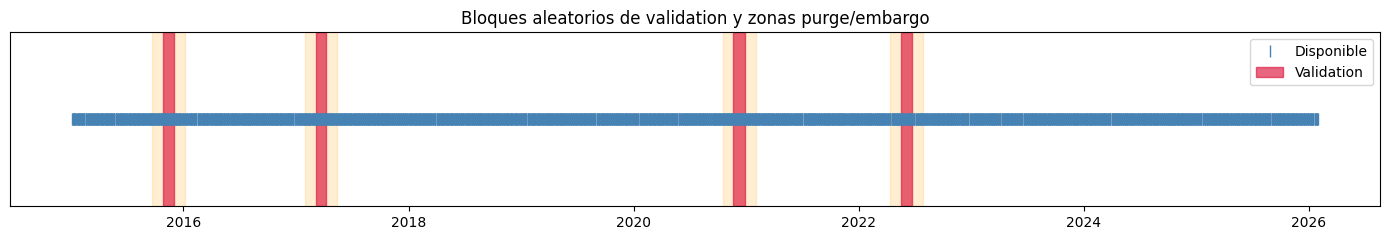

In [52]:
validation_blocks = select_validation_blocks(
    components.index,
    n_blocks=VALIDATION_BLOCKS,
    block_length=max(WINDOW_SIZES),
    purge_size=PURGE_SIZE,
    seed=SEED,
)
print('Bloques de validación:')
for start, end in validation_blocks:
    print(components.index[start].date(), '->', components.index[end].date())

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.plot(components.index, np.zeros(len(components)), '|', color='steelblue', markersize=8, label='Disponible')
for number, (start, end) in enumerate(validation_blocks):
    purge_start = max(0, start - PURGE_SIZE)
    purge_end = min(len(components.index) - 1, end + PURGE_SIZE)
    ax.axvspan(components.index[purge_start], components.index[purge_end], color='orange', alpha=0.18)
    ax.axvspan(components.index[start], components.index[end], color='crimson', alpha=0.65, label='Validation' if number == 0 else None)
ax.set_yticks([])
ax.set_title('Bloques aleatorios de validation y zonas purge/embargo')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 5. Grid conjunto de arquitecturas

Se comparan las familias `GRUVAE` single-branch y `MultiBranchGRUVAE` con exactamente la misma función objetivo: reconstrucción equilibrada `1/3 mercado + 1/3 sector + 1/3 idiosincrático`, más el mismo término KL. Para cada candidato se registran tanto la loss ponderada como las pérdidas separadas de mercado, sector e idiosincrático. Se prueban `WINDOW_SIZES = [10, 15, 20, 25]` y `LATENT_DIMS = [8, 16, 24, 32]`; el learning rate es fijo en `0.0005`.

In [41]:
ARCHITECTURES = {
    'single_gru_small': {
        'family': 'single_branch', 'hidden_dims': [64], 'dropout': 0.0,
    },
    'single_gru_medium': {
        'family': 'single_branch', 'hidden_dims': [128, 64], 'dropout': 0.1,
    },
    'single_gru_large': {
        'family': 'single_branch', 'hidden_dims': [128, 128], 'dropout': 0.2,
    },
    'multibranch_small': {
        'family': 'multi_branch', 'market_hidden': [8], 'sector_hidden': [32],
        'idio_hidden': [32], 'fusion_hidden': 64, 'dropout': 0.0,
    },
    'multibranch_medium': {
        'family': 'multi_branch', 'market_hidden': [16], 'sector_hidden': [64],
        'idio_hidden': [64], 'fusion_hidden': 128, 'dropout': 0.1,
    },
    'multibranch_deep': {
        'family': 'multi_branch', 'market_hidden': [16, 16], 'sector_hidden': [64, 32],
        'idio_hidden': [64, 32], 'fusion_hidden': 128, 'dropout': 0.1,
    },
    'multibranch_idio_large': {
        'family': 'multi_branch', 'market_hidden': [16], 'sector_hidden': [64],
        'idio_hidden': [128, 64], 'fusion_hidden': 128, 'dropout': 0.1,
    },
}

# Todas las arquitecturas usan la misma loss equilibrada por familias.
CANDIDATES = [
    {
        'architecture': name,
        'latent_dim': latent_dim,
        'window_size': window_size,
        'learning_rate': LEARNING_RATE,
    }
    for name in ARCHITECTURES
    for latent_dim in LATENT_DIMS
    for window_size in WINDOW_SIZES
]
pd.DataFrame(CANDIDATES)

,architecture,latent_dim,window_size,learning_rate
0,single_gru_small,8,10,0.0005
1,single_gru_small,8,15,0.0005
2,single_gru_small,8,20,0.0005
3,single_gru_small,8,25,0.0005
4,single_gru_small,16,10,0.0005
...,...,...,...,...
107,multibranch_idio_large,24,25,0.0005
108,multibranch_idio_large,32,10,0.0005
109,multibranch_idio_large,32,15,0.0005
110,multibranch_idio_large,32,20,0.0005


## 6. Normalización y entrenamiento de todos los candidatos

Para cada candidato, el `StandardScaler` se ajusta exclusivamente sobre filas fuera de los bloques de validation y se aplica también a validation. Todos optimizan la misma loss equilibrada por familias:

$$L_{reconstruction}=\\frac13L_{market}+\\frac13L_{sector}+\\frac13L_{idio}$$

La función registra por época la loss ponderada, la loss común sobre 61 features, KL y las tres pérdidas de familia para train y validation. Guarda el checkpoint de la mejor época según `val_reconstruction_loss`, todas las curvas, el número de parámetros y el tiempo de entrenamiento, y aplica early stopping con `MAX_EPOCHS=50` y `PATIENCE=20`.

In [42]:
validation_mask = np.zeros(len(components), dtype=bool)
for start, end in validation_blocks:
    validation_mask[start:end + 1] = True

candidate_results = []
candidate_histories = {}
candidate_scalers = {}
candidate_splits = {}


def build_model(candidate):
    architecture = ARCHITECTURES[candidate['architecture']]
    if architecture['family'] == 'single_branch':
        model_kwargs = {key: architecture[key] for key in ('hidden_dims', 'dropout')}
        return GRUVAE(input_dim=components.shape[1], latent_dim=candidate['latent_dim'], **model_kwargs)
    model_kwargs = {key: architecture[key] for key in ('market_hidden', 'sector_hidden', 'idio_hidden', 'fusion_hidden', 'dropout')}
    return MultiBranchGRUVAE(latent_dim=candidate['latent_dim'], **model_kwargs)


for candidate_id, candidate in enumerate(CANDIDATES):
    set_reproducible_seed(SEED + candidate_id)
    window_size = candidate['window_size']
    starts = window_start_indices(len(components), window_size)
    train_starts, validation_starts = split_window_starts(
        starts, validation_blocks, window_size, purge_size=PURGE_SIZE
    )
    scaler = StandardScaler().fit(components.loc[~validation_mask].to_numpy())
    normalized = pd.DataFrame(
        scaler.transform(components.to_numpy()), index=components.index, columns=feature_names
    )
    train_windows, _ = make_windows(normalized, window_size, train_starts)
    validation_windows, _ = make_windows(normalized, window_size, validation_starts)
    architecture = ARCHITECTURES[candidate['architecture']]
    model = build_model(candidate)
    checkpoint_path = Path('../models/vae/candidates') / f'candidate_{candidate_id:03d}.pt'
    started_at = time.perf_counter()
    history, best_epoch, best_score = train_vae(
        model, train_windows, validation_windows, epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, beta_kl=BETA_KL,
        patience=PATIENCE, seed=SEED + candidate_id, device=DEVICE,
        checkpoint_path=checkpoint_path, branch_loss_weights=BRANCH_LOSS_WEIGHTS,
    )
    training_time_seconds = time.perf_counter() - started_at
    history_df = pd.DataFrame(history)
    history_path = Path('../reports/figures/vae/training_curves') / f'candidate_{candidate_id:03d}.csv'
    history_df.to_csv(history_path, index=False)
    candidate_histories[candidate_id] = history_df
    candidate_scalers[candidate_id] = scaler
    candidate_splits[candidate_id] = (train_starts, validation_starts)
    best_row_index = best_epoch - 1
    result = {
        'candidate_id': candidate_id, **candidate, **architecture,
        'beta_kl': BETA_KL, 'branch_loss_weights': BRANCH_LOSS_WEIGHTS,
        'best_epoch': best_epoch, 'best_validation_score': best_score,
        'validation_branch_weighted_loss': history_df.loc[best_row_index, 'val_reconstruction_loss'],
        'validation_common_reconstruction_loss': history_df.loc[best_row_index, 'val_common_reconstruction_loss'],
        'validation_market_loss': history_df.loc[best_row_index, 'val_market_loss'],
        'validation_sector_loss': history_df.loc[best_row_index, 'val_sector_loss'],
        'validation_idio_loss': history_df.loc[best_row_index, 'val_idio_loss'],
        'validation_kl_loss': history_df.loc[best_row_index, 'val_kl_loss'],
        'validation_total_loss': history_df.loc[best_row_index, 'val_total_loss'],
        'n_parameters': sum(parameter.numel() for parameter in model.parameters()),
        'training_time_seconds': training_time_seconds,
        'n_train_windows': len(train_windows), 'n_validation_windows': len(validation_windows),
        'checkpoint': str(checkpoint_path), 'history_path': str(history_path),
    }
    candidate_results.append(result)

results_df = pd.DataFrame(candidate_results).sort_values('best_validation_score').reset_index(drop=True)
results_df.to_csv('../models/vae/candidate_results.csv', index=False)
results_df

,candidate_id,architecture,latent_dim,window_size,learning_rate,family,hidden_dims,dropout,beta_kl,branch_loss_weights,...,n_parameters,training_time_seconds,n_train_windows,n_validation_windows,checkpoint,history_path,market_hidden,sector_hidden,idio_hidden,fusion_hidden
0,44,single_gru_large,32,10,0.0005,single_branch,"[128, 128]",0.2,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,349821,39.527286,2448,64,..\models\vae\candidates\candidate_044.pt,..\reports\figures\vae\training_curves\candida...,NaN,NaN,NaN,NaN
1,40,single_gru_large,24,10,0.0005,single_branch,"[128, 128]",0.2,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,344685,39.633277,2448,64,..\models\vae\candidates\candidate_040.pt,..\reports\figures\vae\training_curves\candida...,NaN,NaN,NaN,NaN
2,28,single_gru_medium,32,10,0.0005,single_branch,"[128, 64]",0.1,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,215933,32.385605,2448,64,..\models\vae\candidates\candidate_028.pt,..\reports\figures\vae\training_curves\candida...,NaN,NaN,NaN,NaN
3,8,single_gru_small,24,10,0.0005,single_branch,[64],0.0,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,48749,12.398969,2448,64,..\models\vae\candidates\candidate_008.pt,..\reports\figures\vae\training_curves\candida...,NaN,NaN,NaN,NaN
4,36,single_gru_large,16,10,0.0005,single_branch,"[128, 128]",0.2,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,339549,38.779498,2448,64,..\models\vae\candidates\candidate_036.pt,..\reports\figures\vae\training_curves\candida...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,71,multibranch_medium,16,25,0.0005,multi_branch,NaN,0.1,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,97501,64.904421,2373,4,..\models\vae\candidates\candidate_071.pt,..\reports\figures\vae\training_curves\candida...,[16],[64],[64],128.0
108,59,multibranch_small,24,25,0.0005,multi_branch,NaN,0.0,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,34285,44.635052,2373,4,..\models\vae\candidates\candidate_059.pt,..\reports\figures\vae\training_curves\candida...,[8],[32],[32],64.0
109,51,multibranch_small,8,25,0.0005,multi_branch,NaN,0.0,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,28749,47.552001,2373,4,..\models\vae\candidates\candidate_051.pt,..\reports\figures\vae\training_curves\candida...,[8],[32],[32],64.0
110,99,multibranch_idio_large,8,25,0.0005,multi_branch,NaN,0.1,0.001,"(0.3333333333333333, 0.3333333333333333, 0.333...",...,248653,107.830572,2373,4,..\models\vae\candidates\candidate_099.pt,..\reports\figures\vae\training_curves\candida...,[16],[64],"[128, 64]",128.0


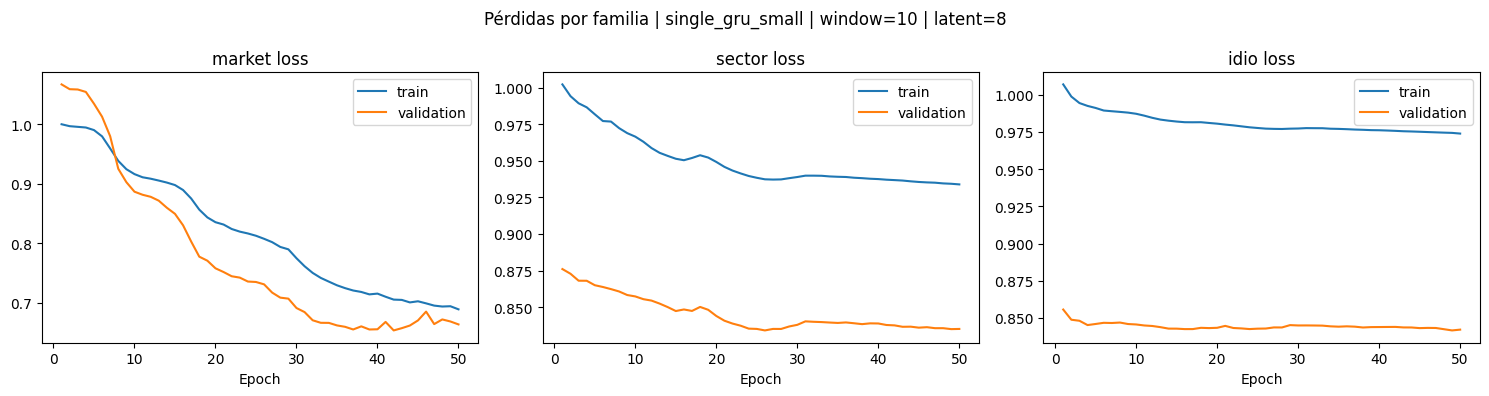

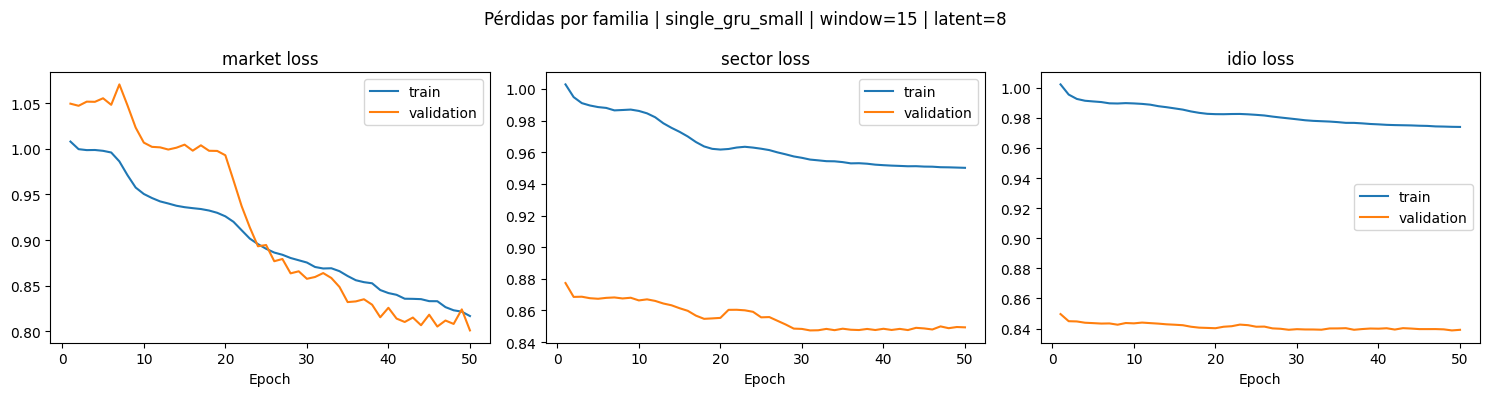

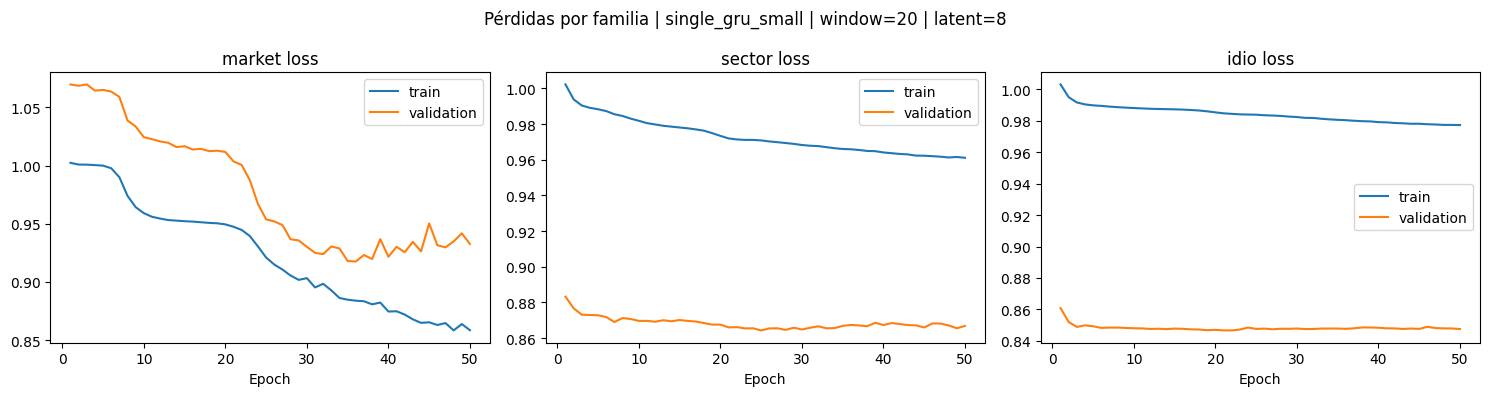

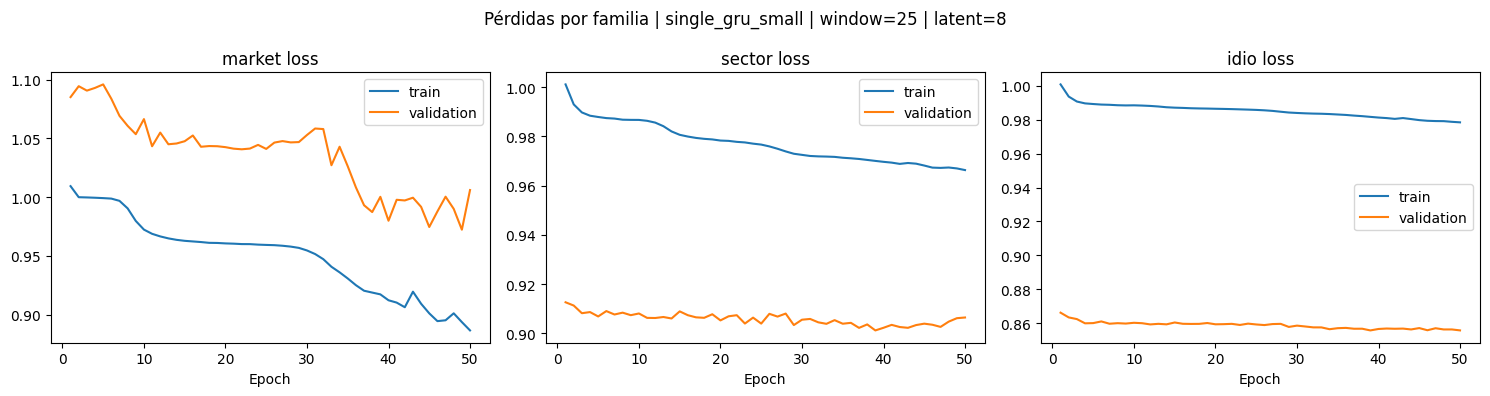

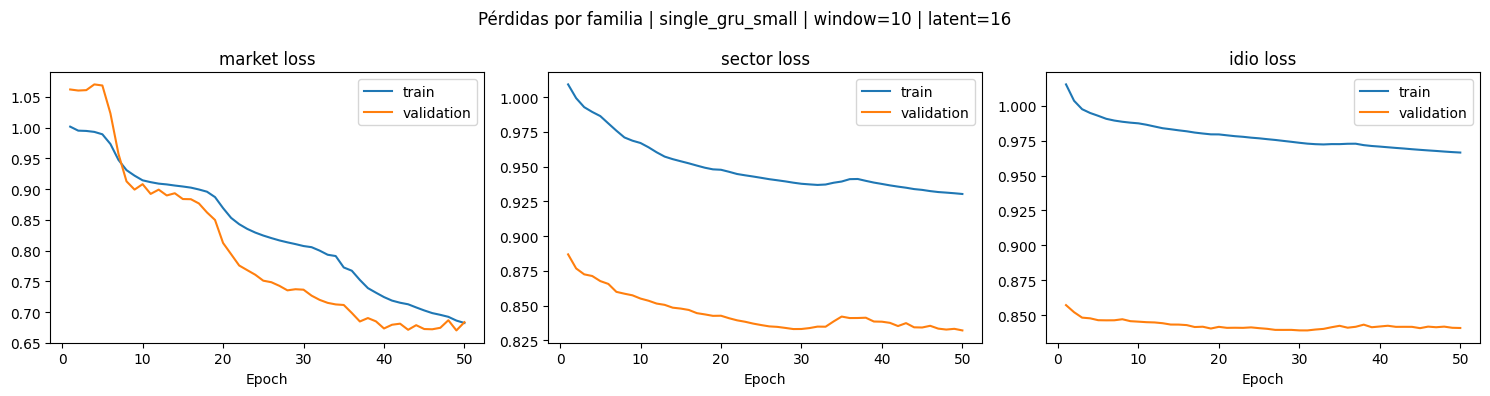

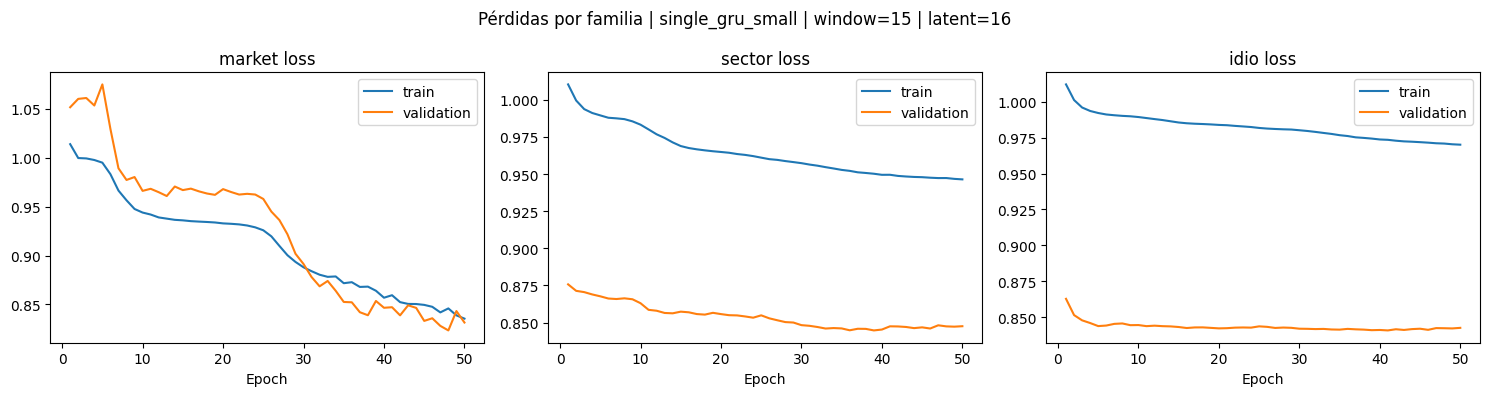

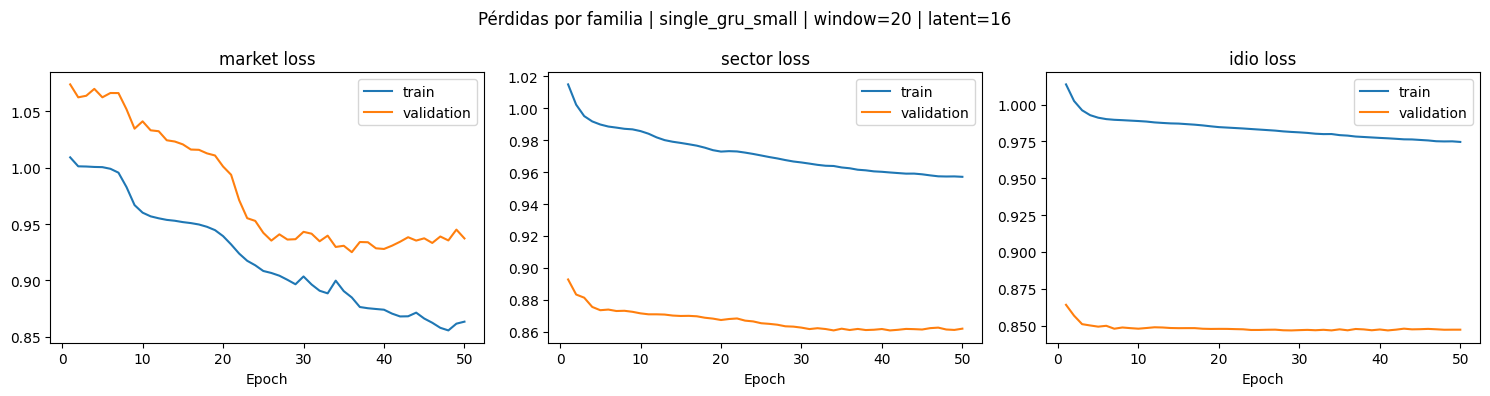

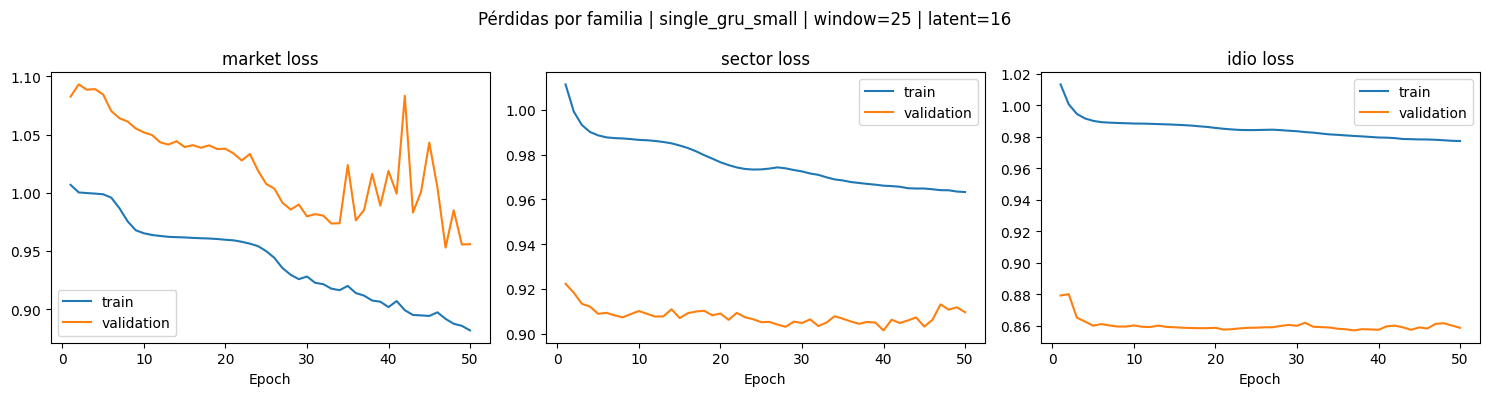

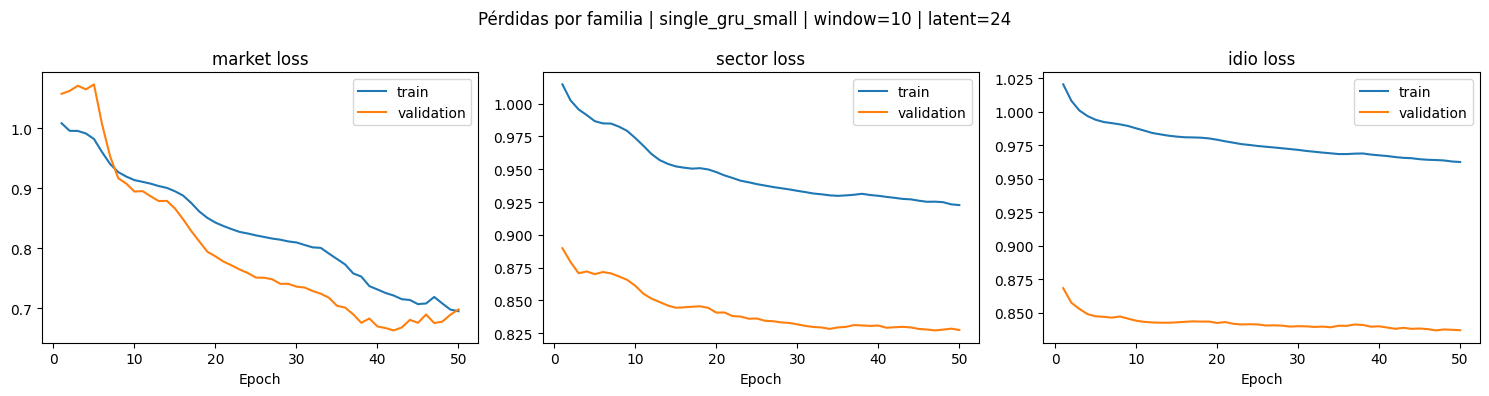

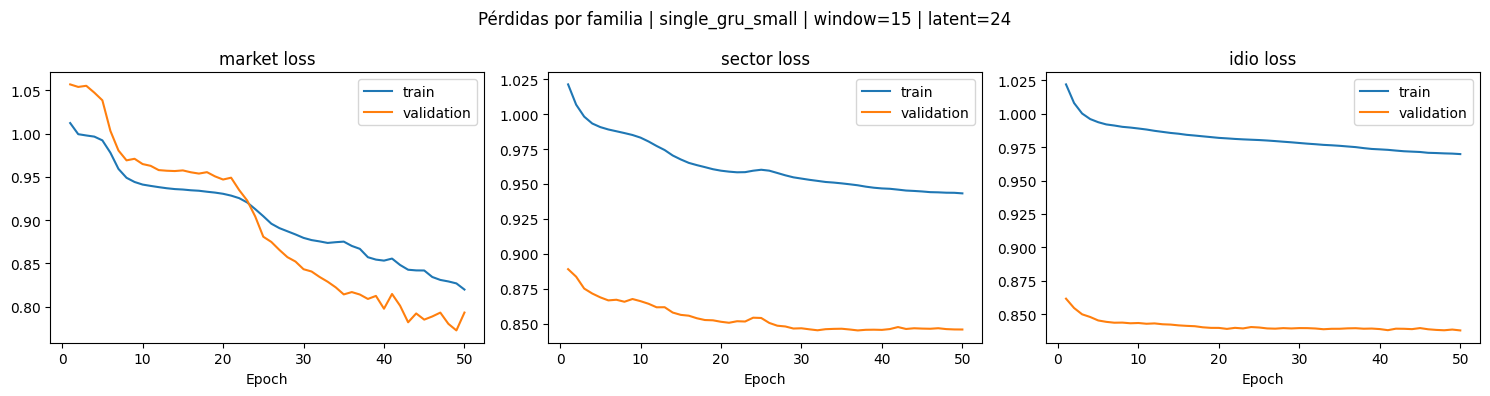

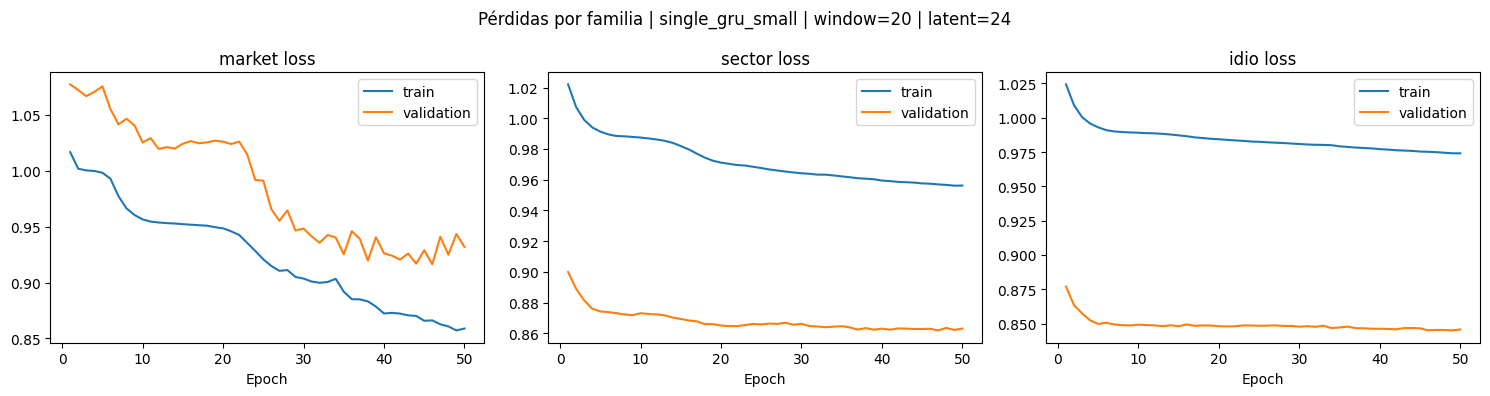

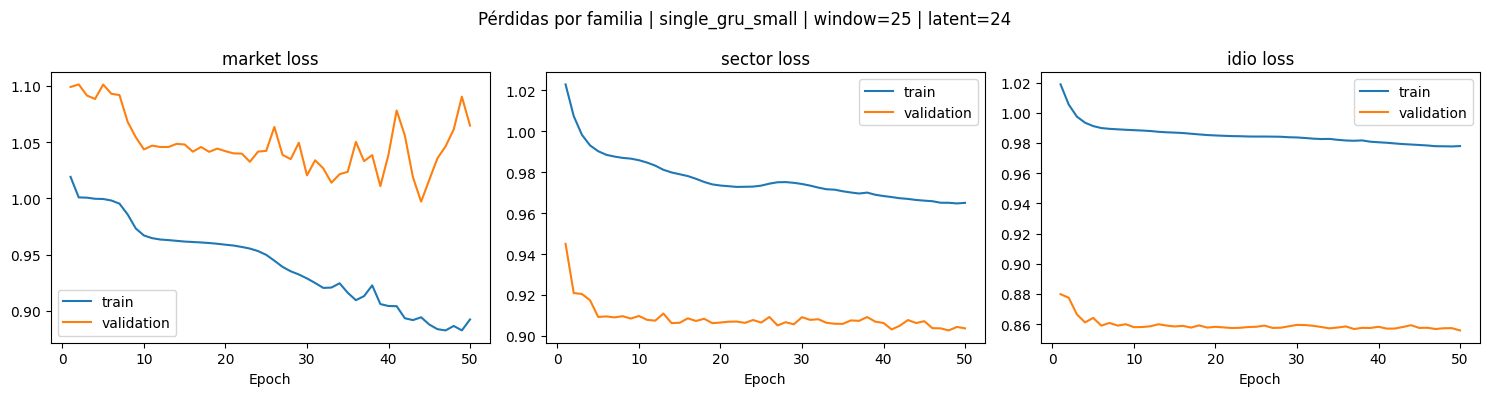

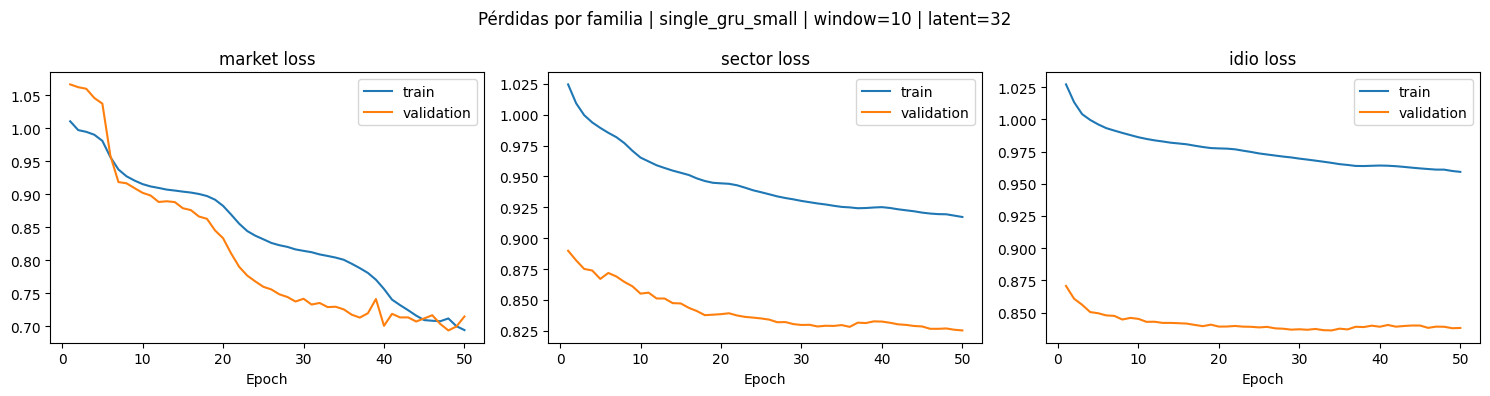

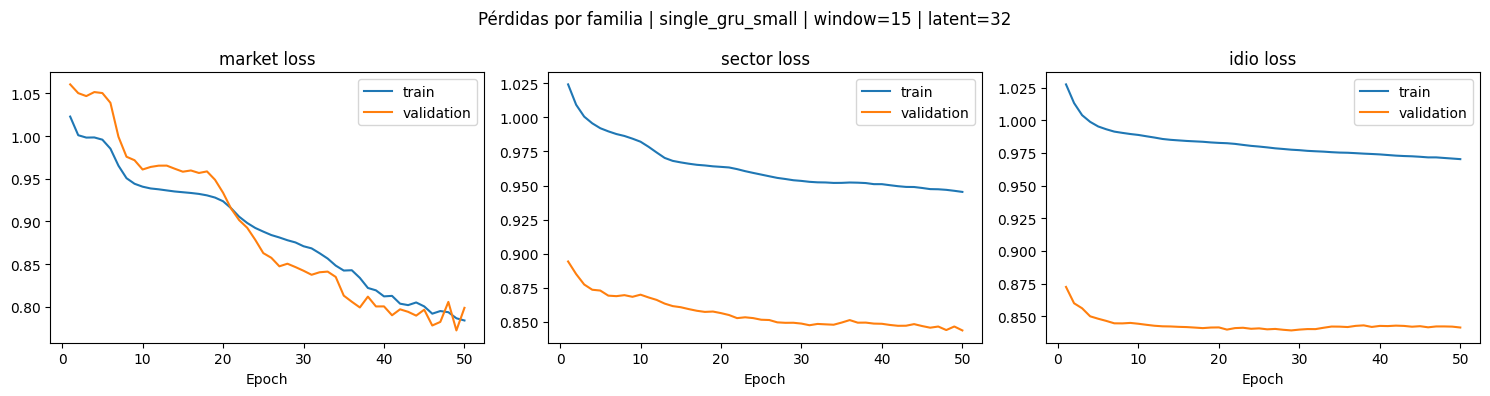

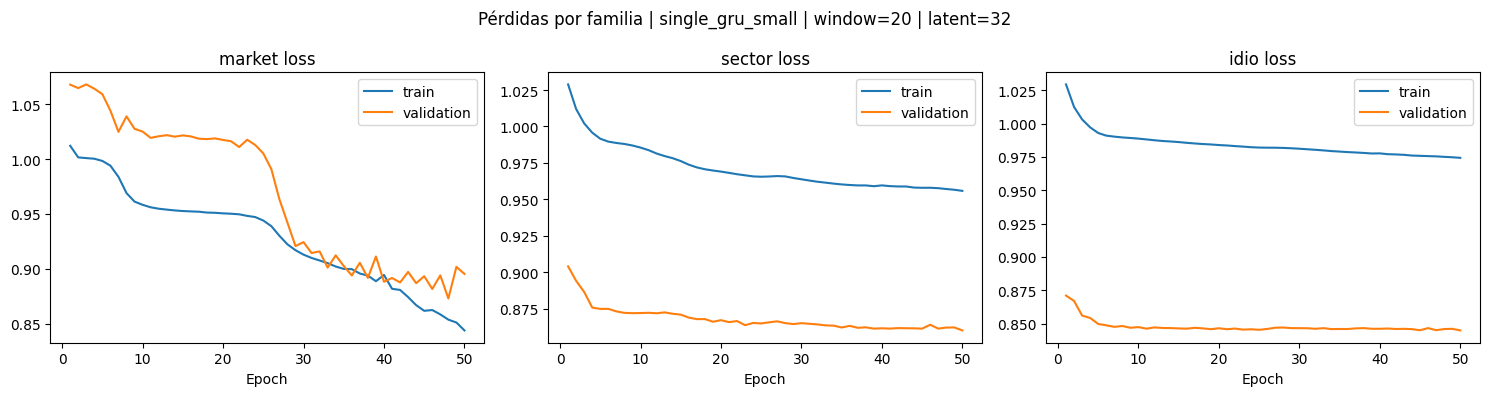

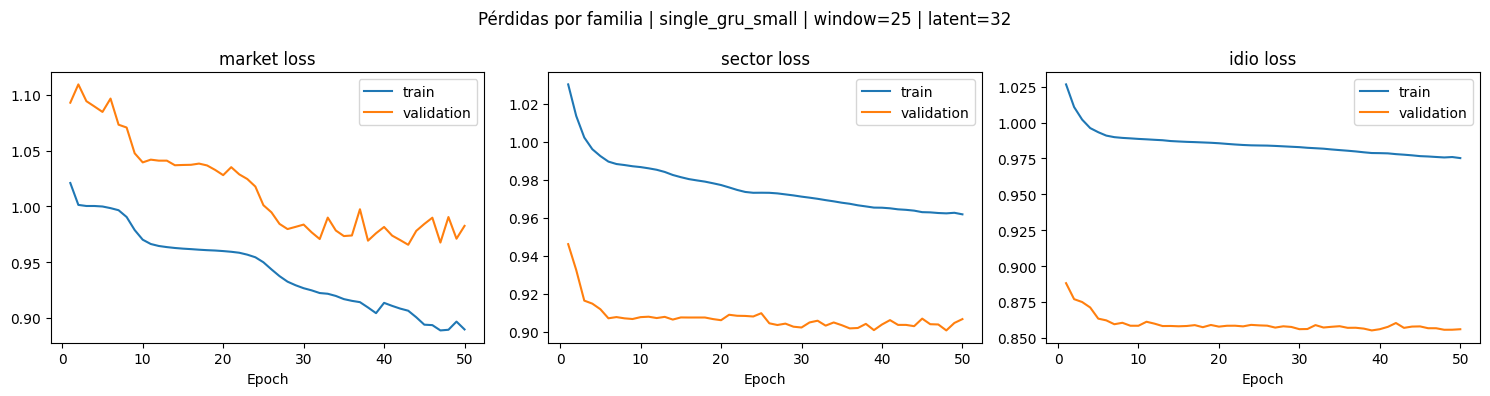

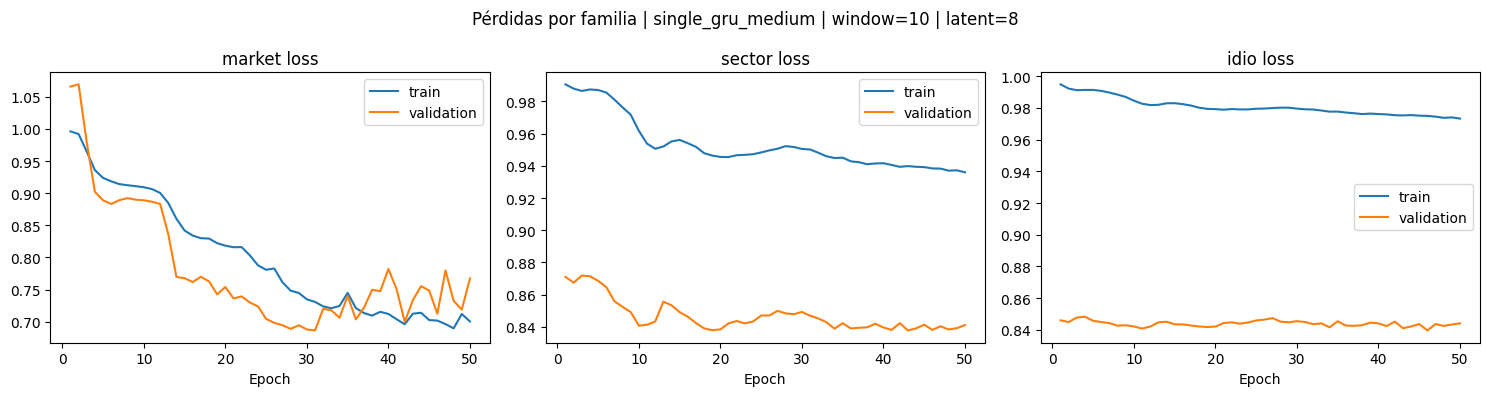

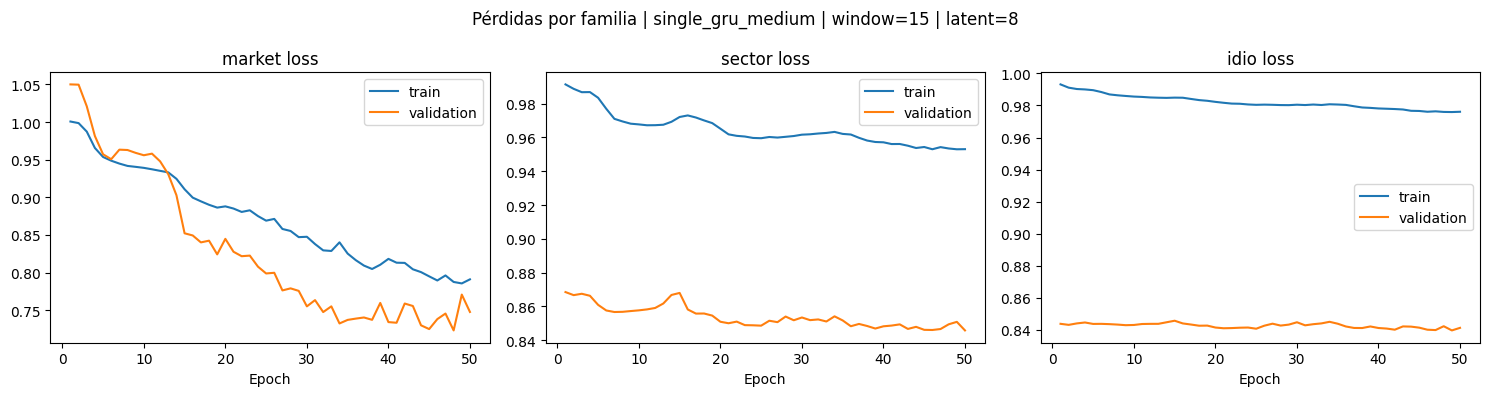

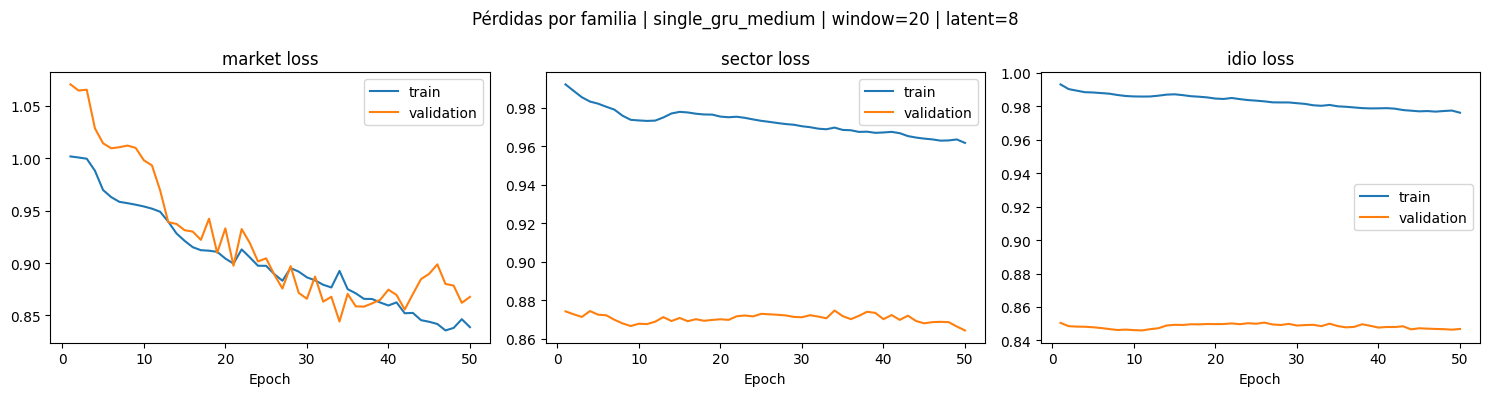

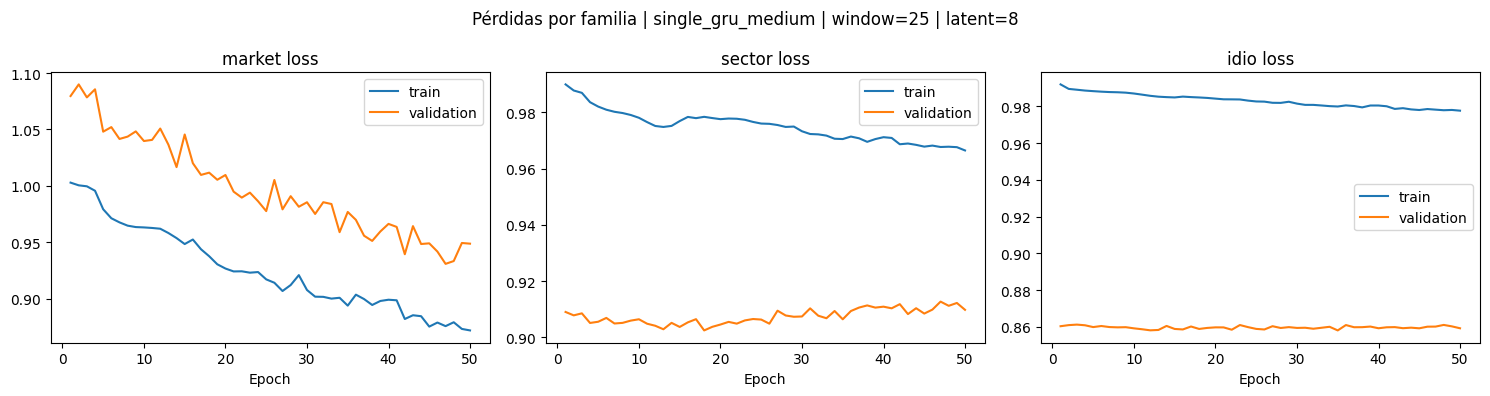

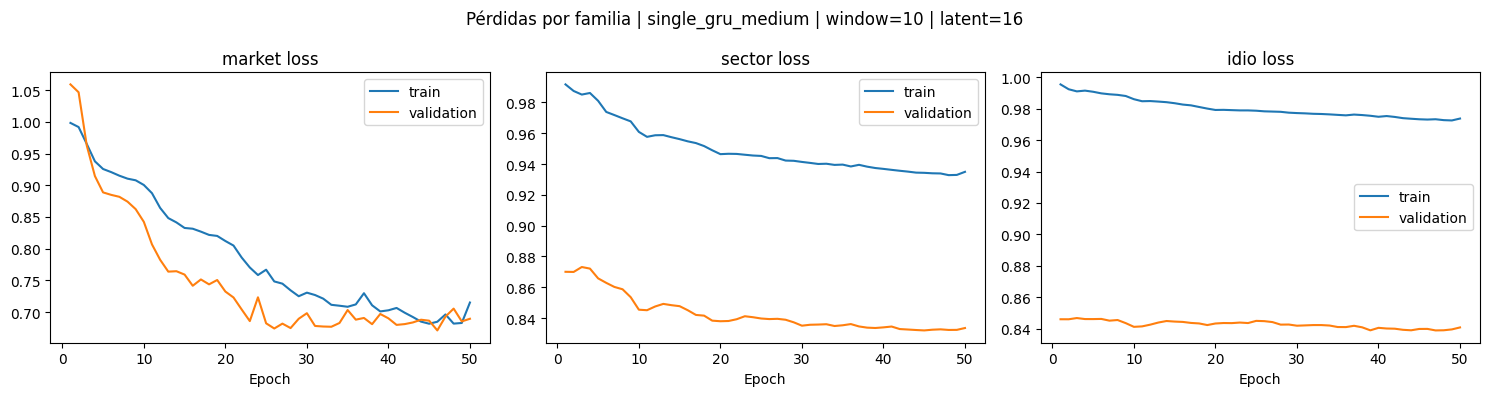

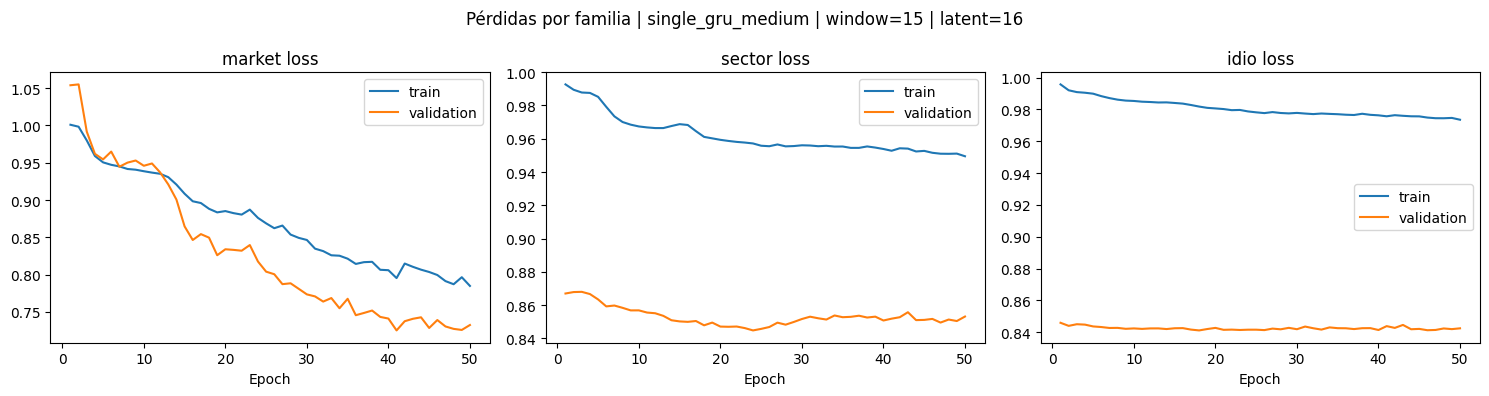

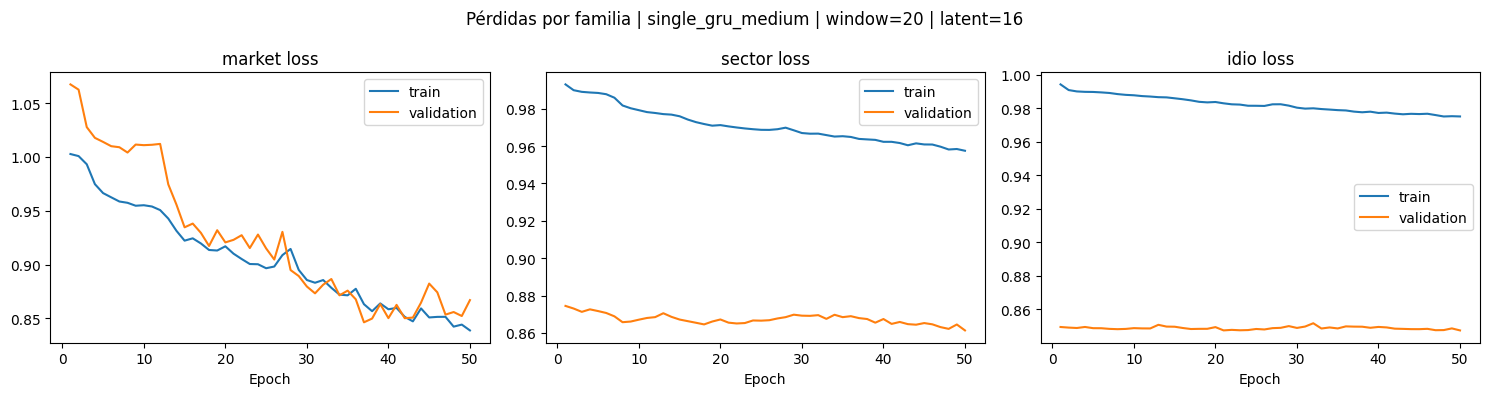

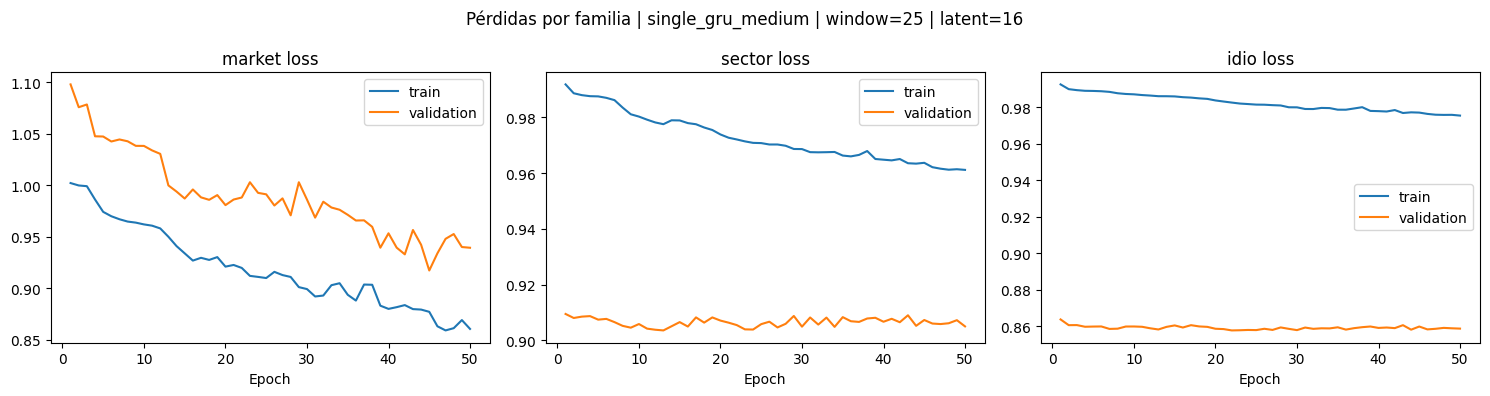

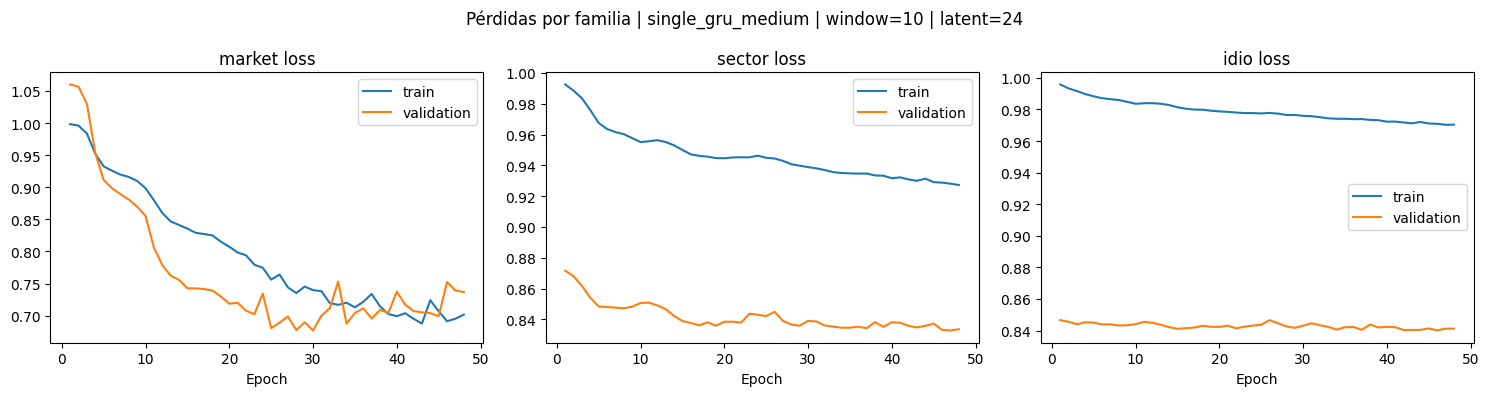

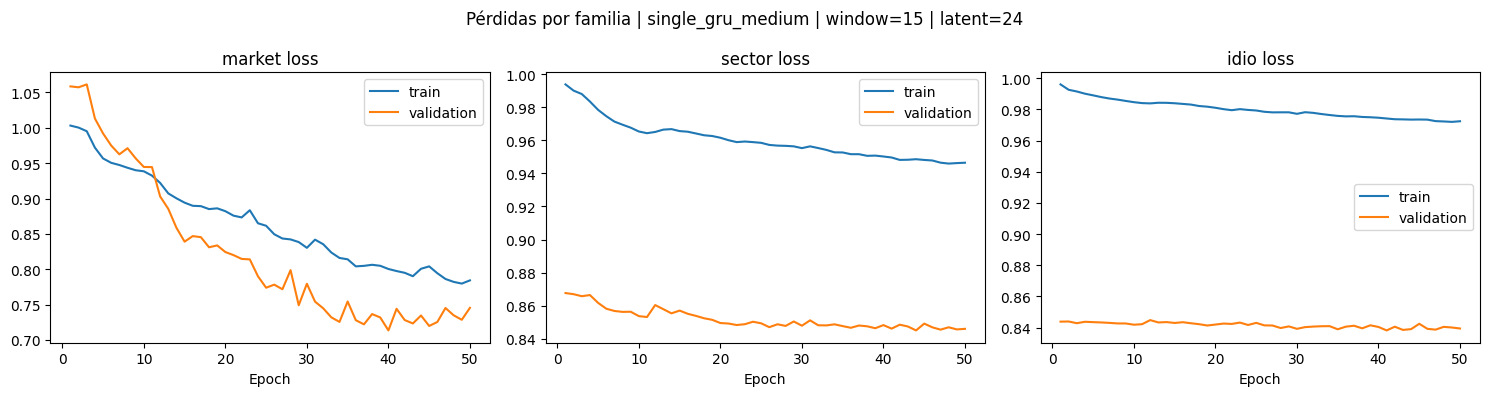

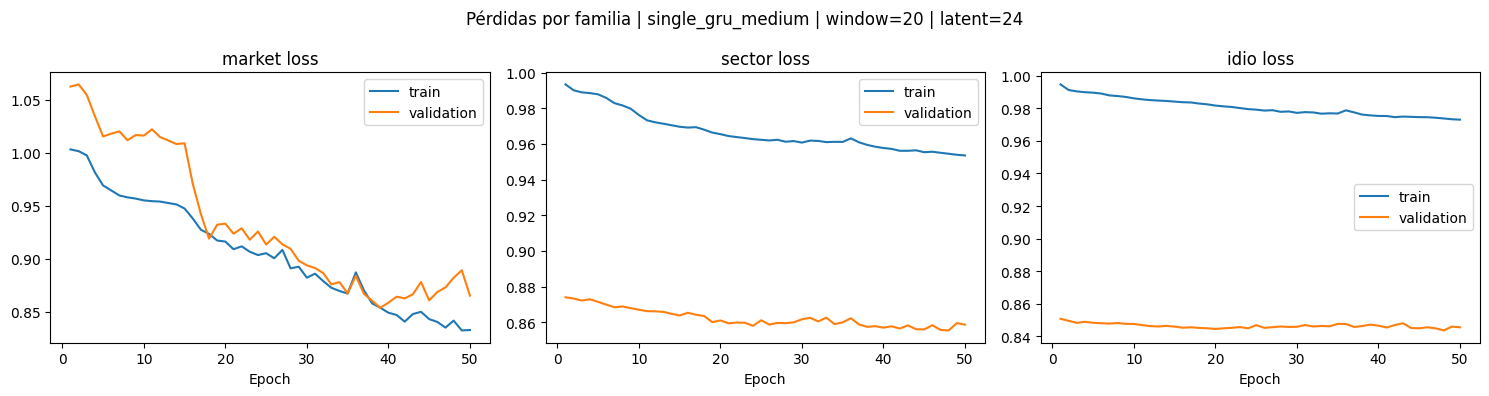

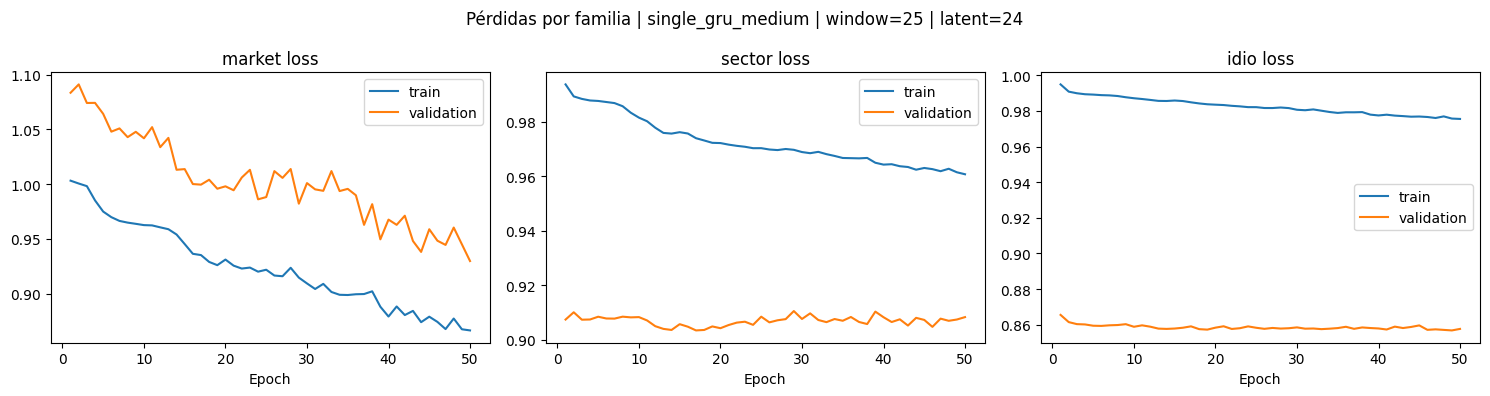

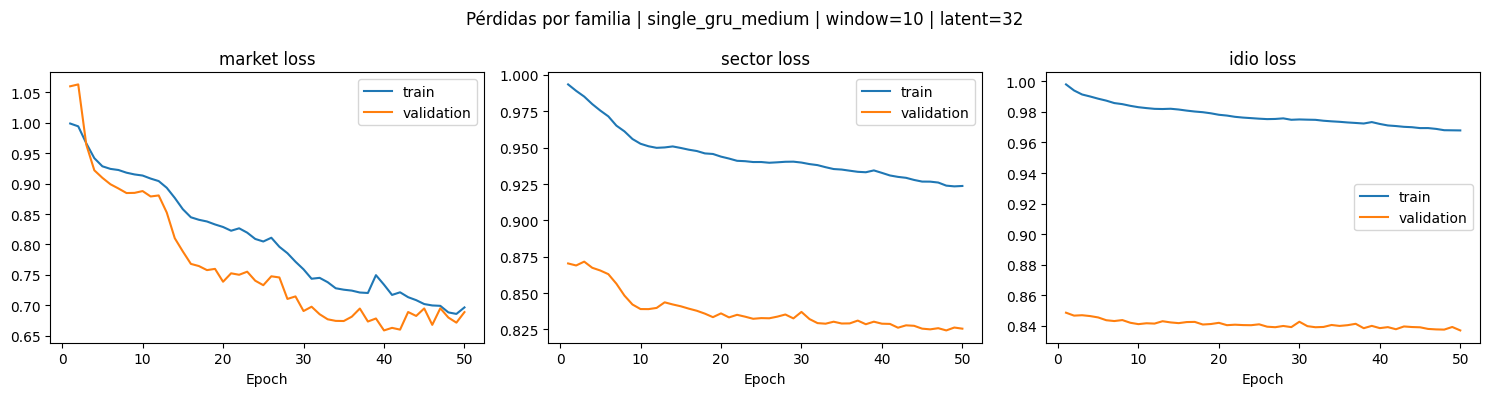

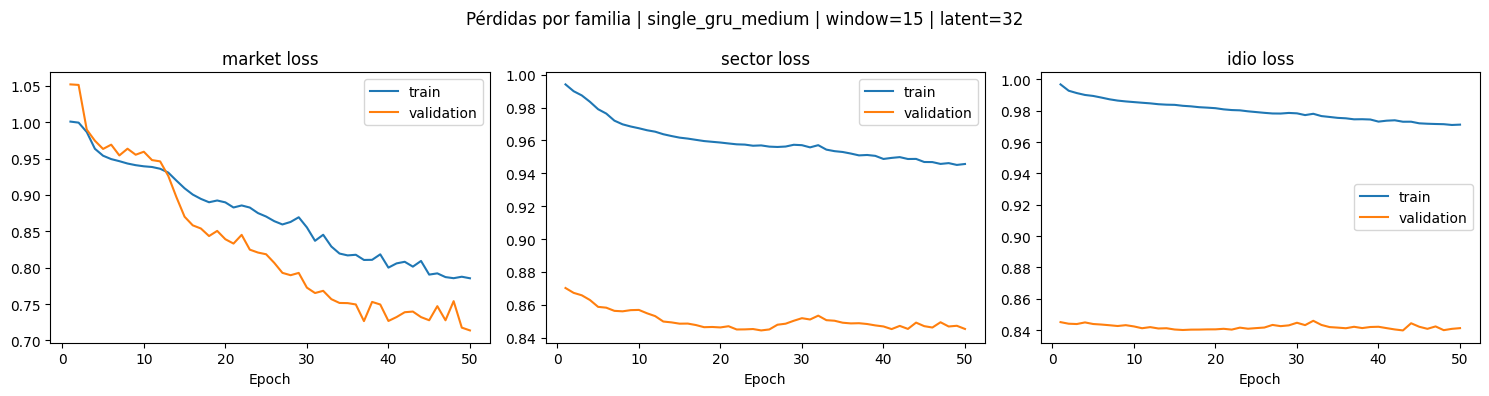

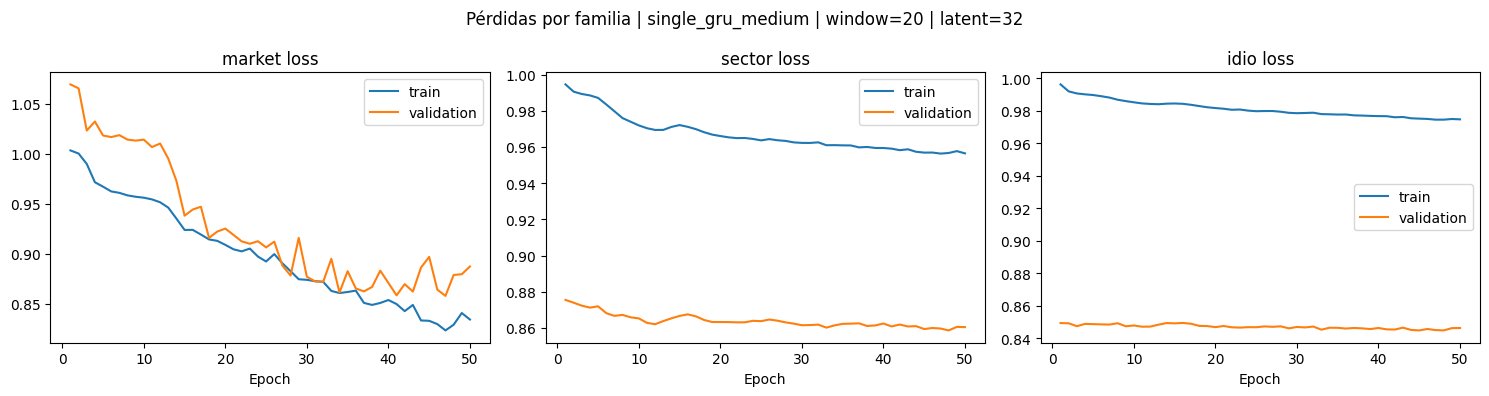

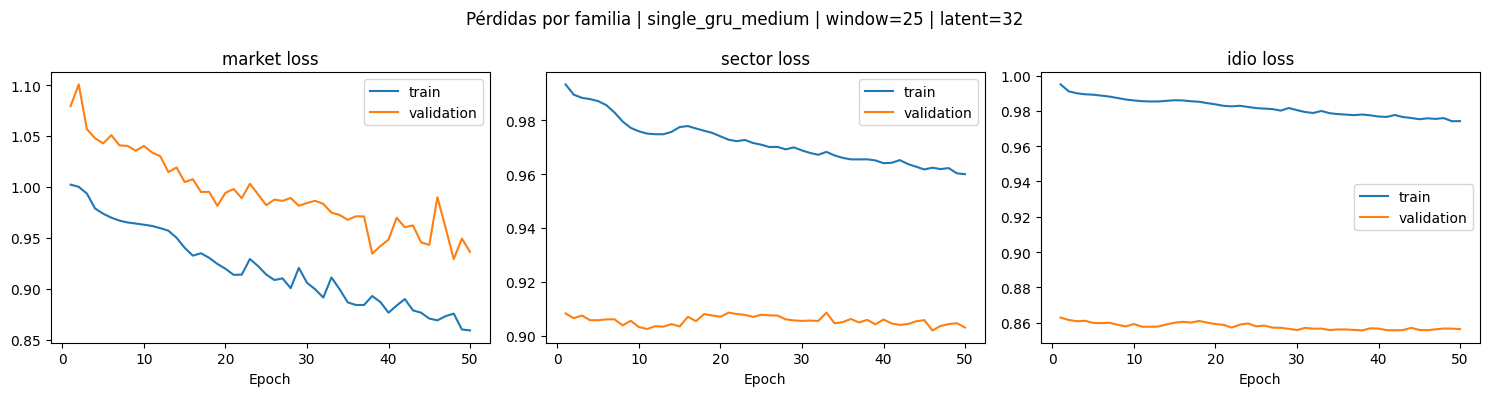

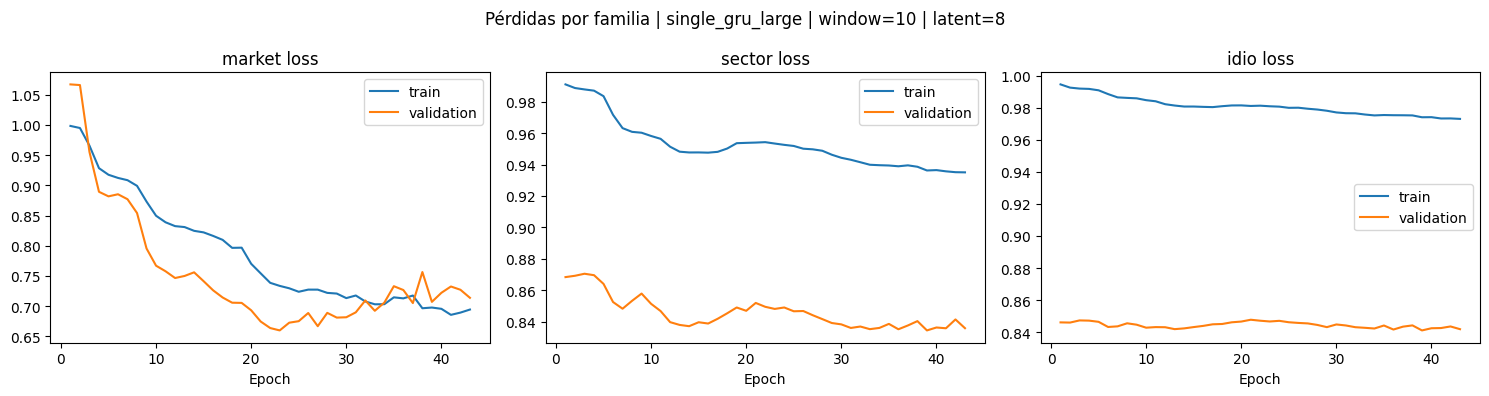

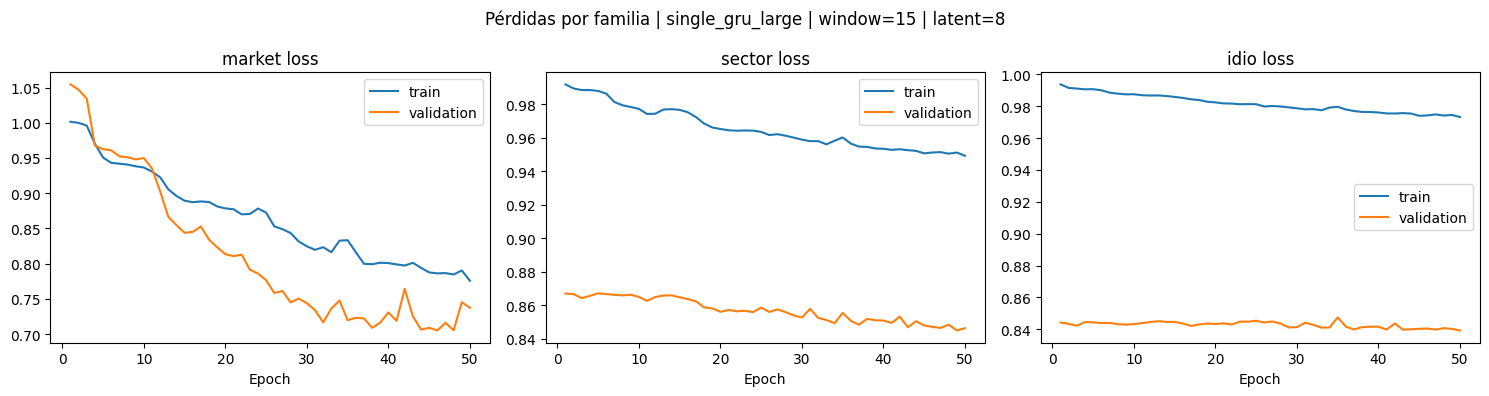

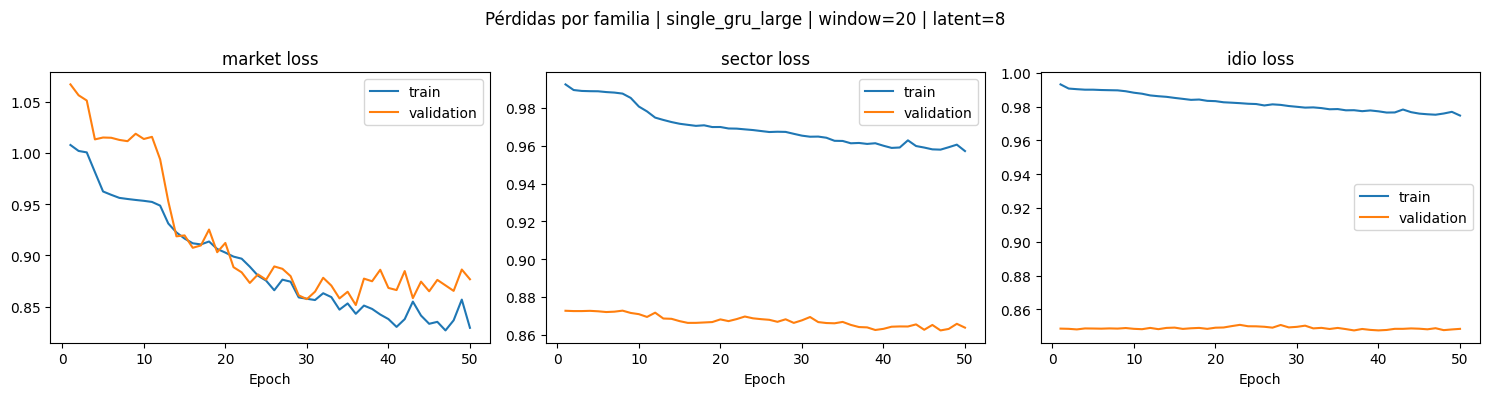

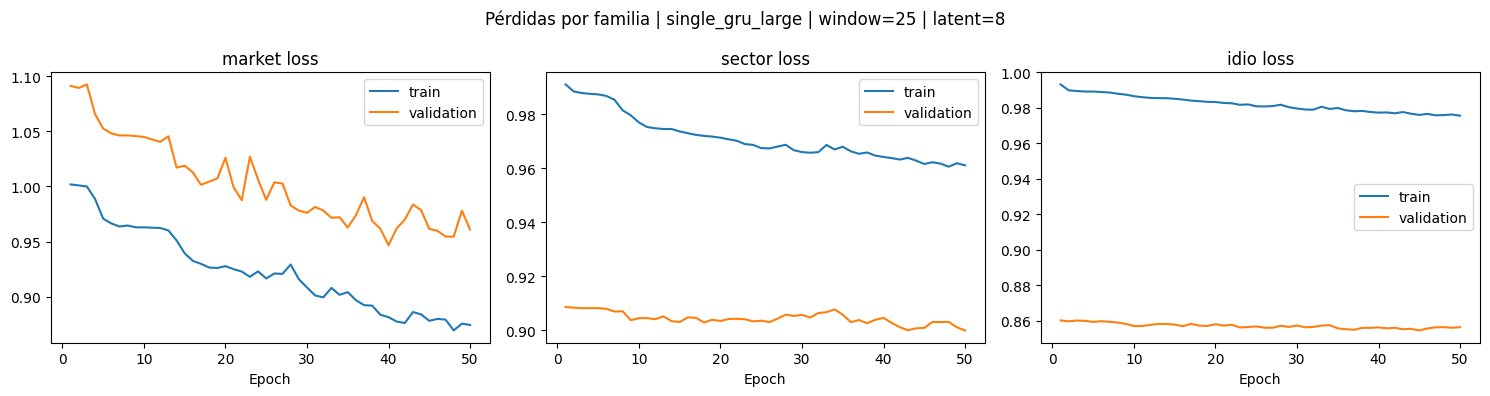

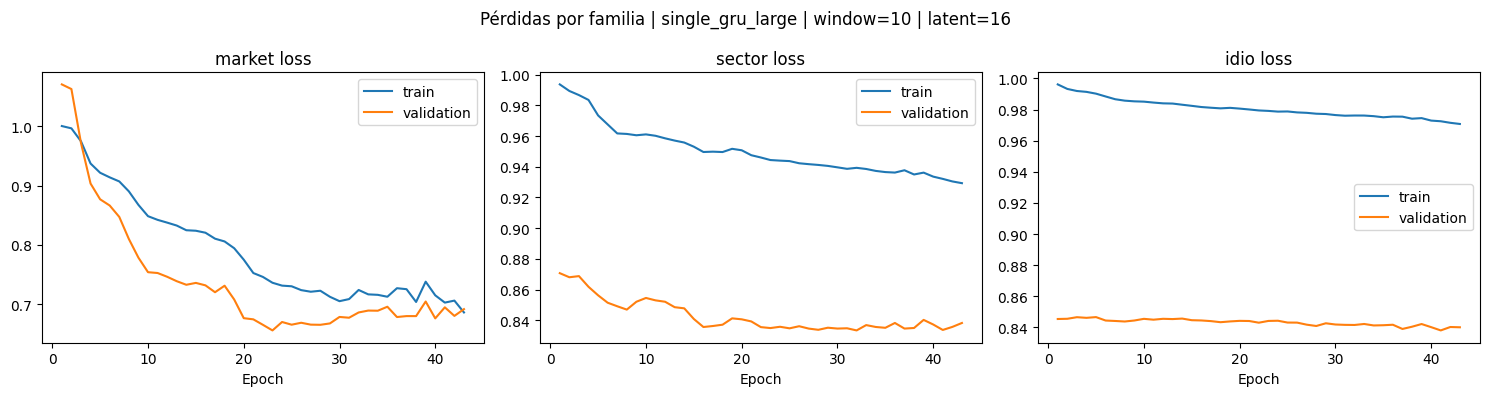

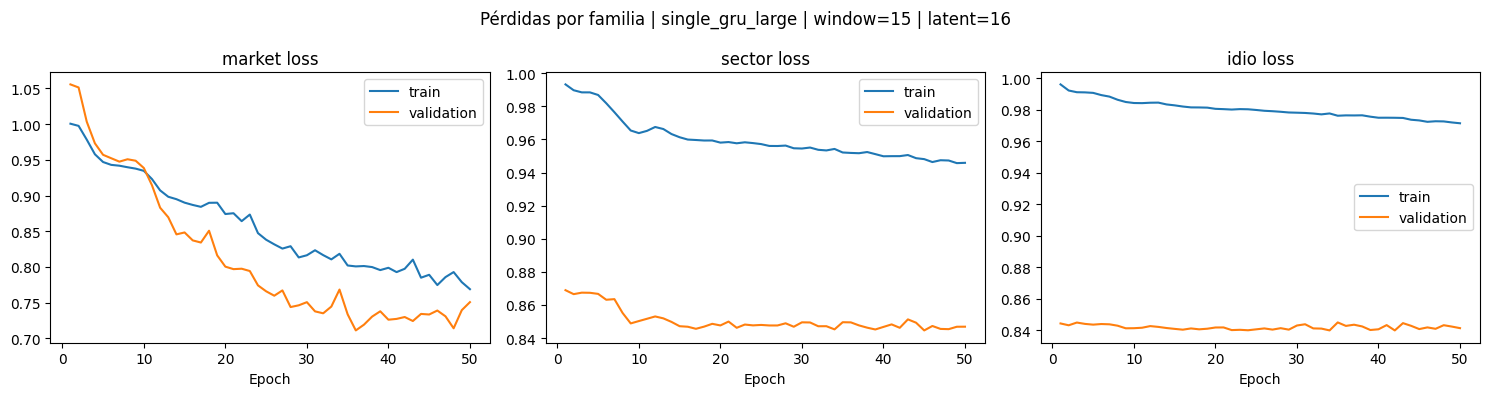

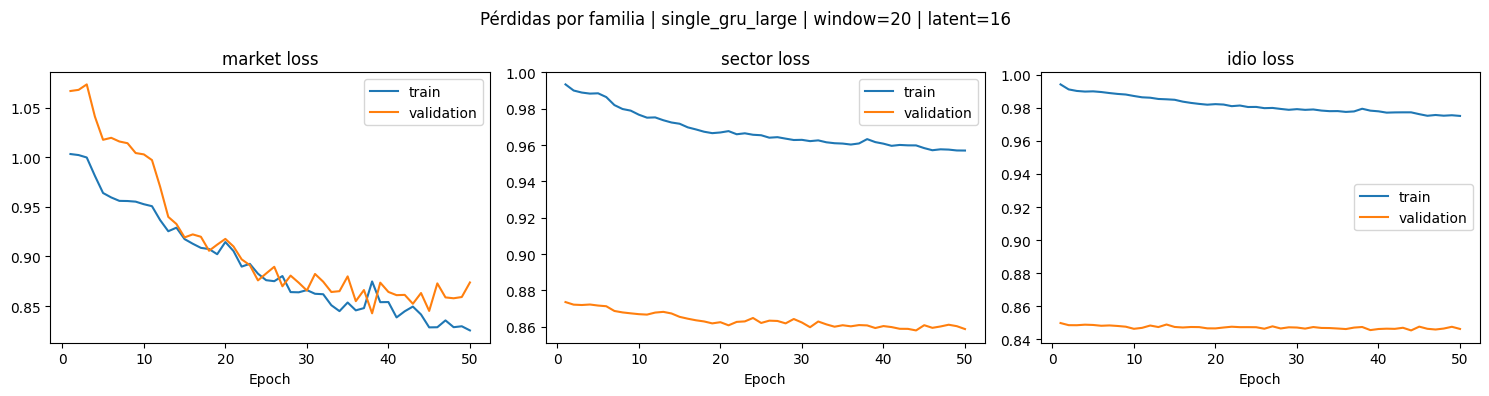

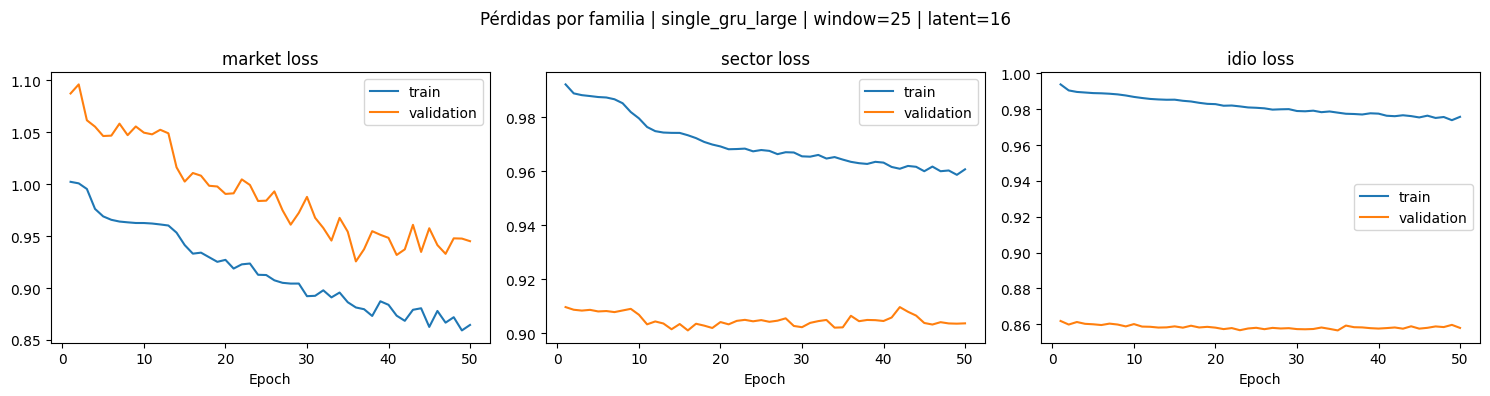

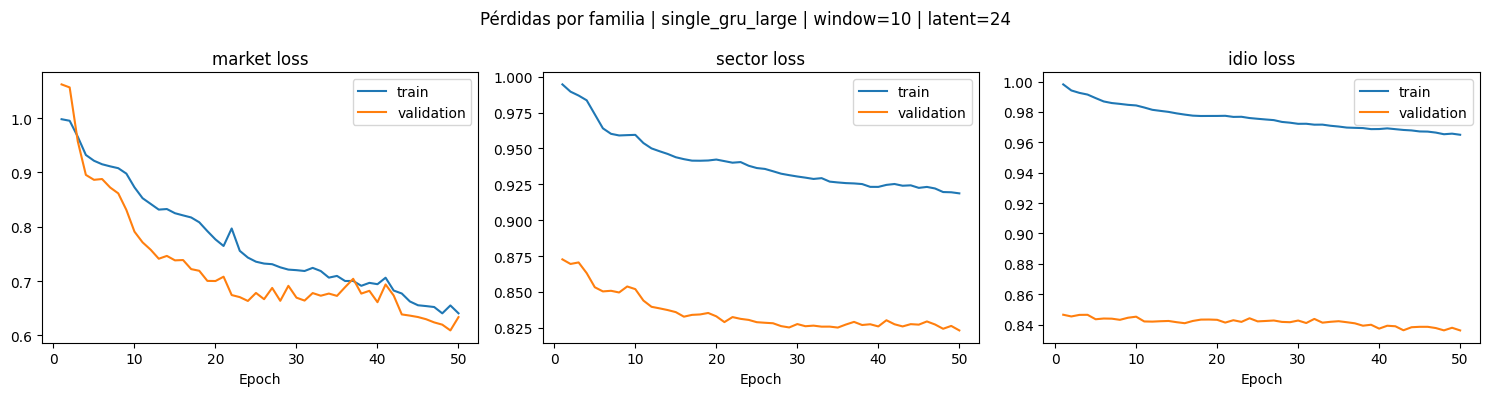

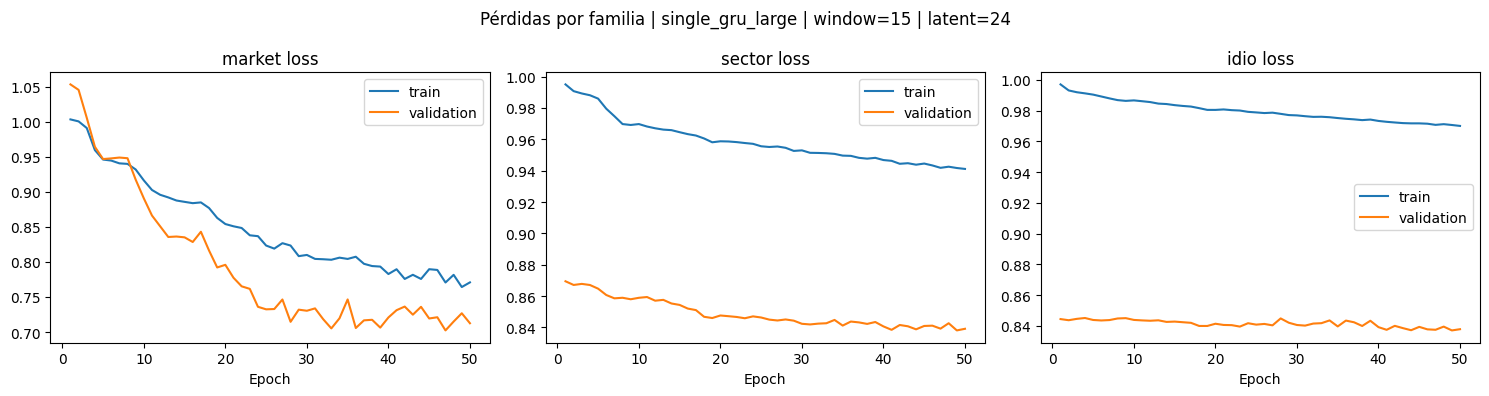

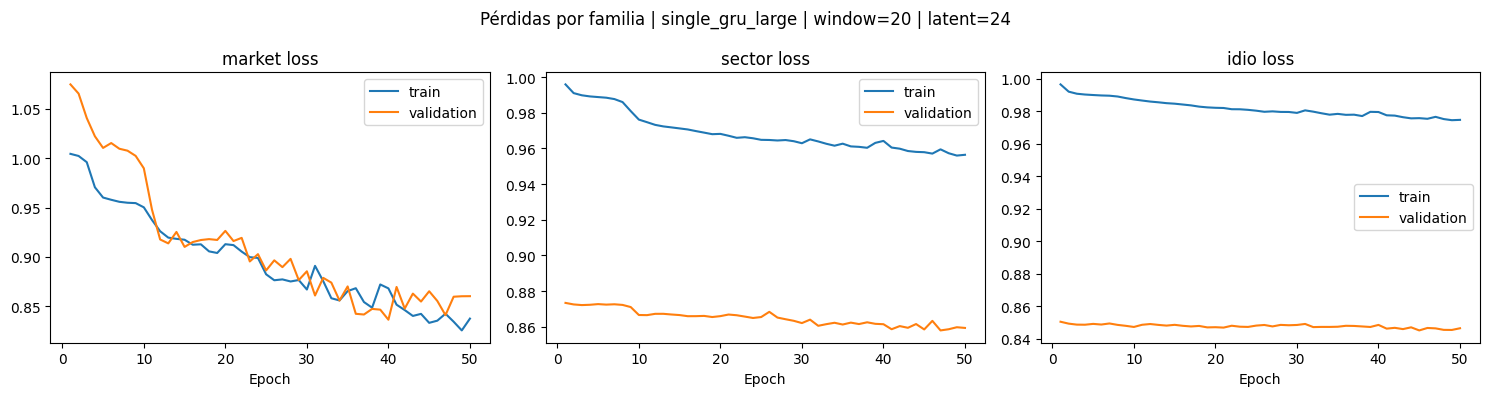

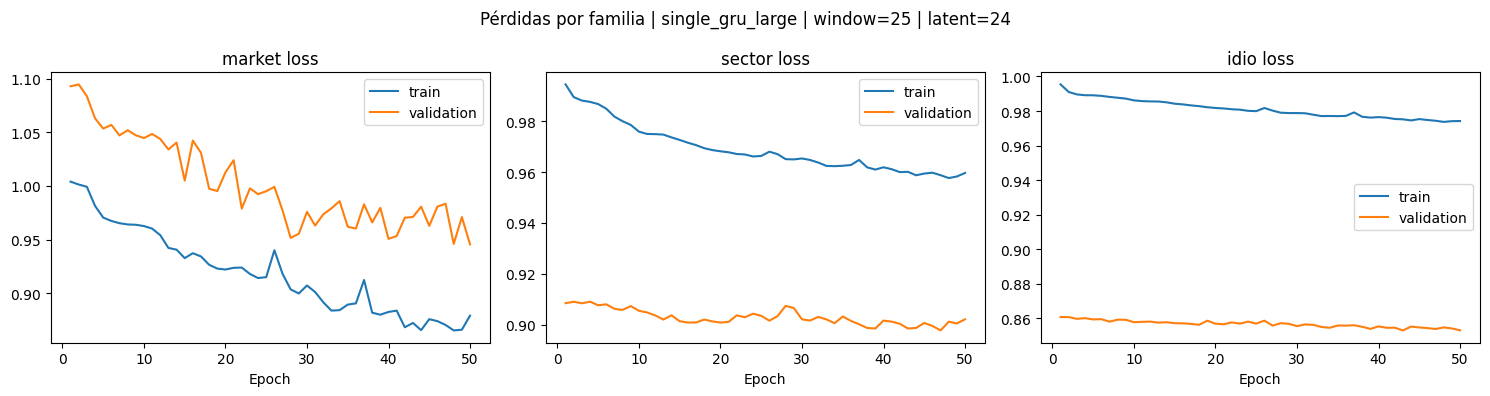

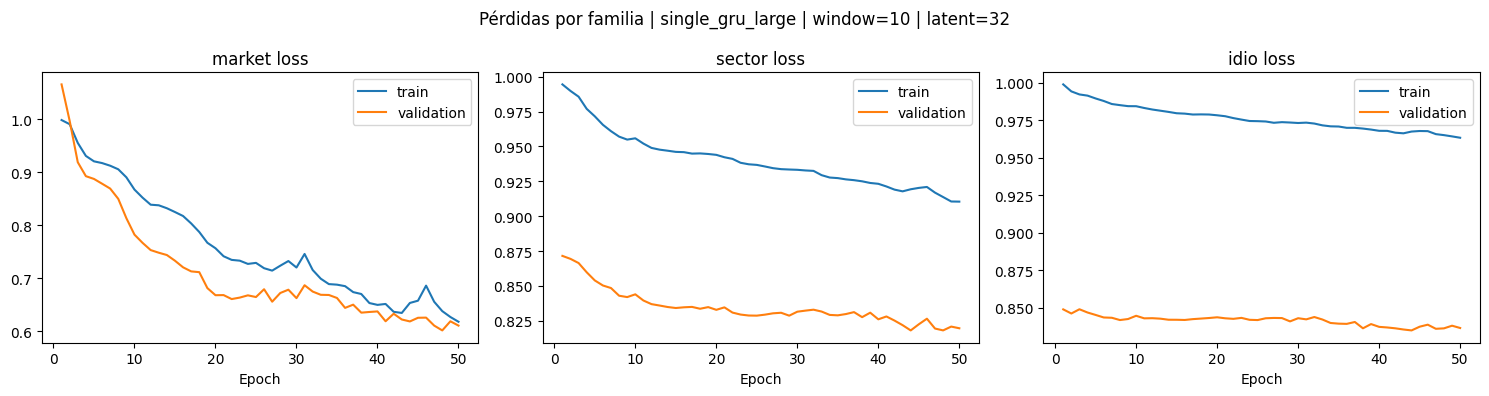

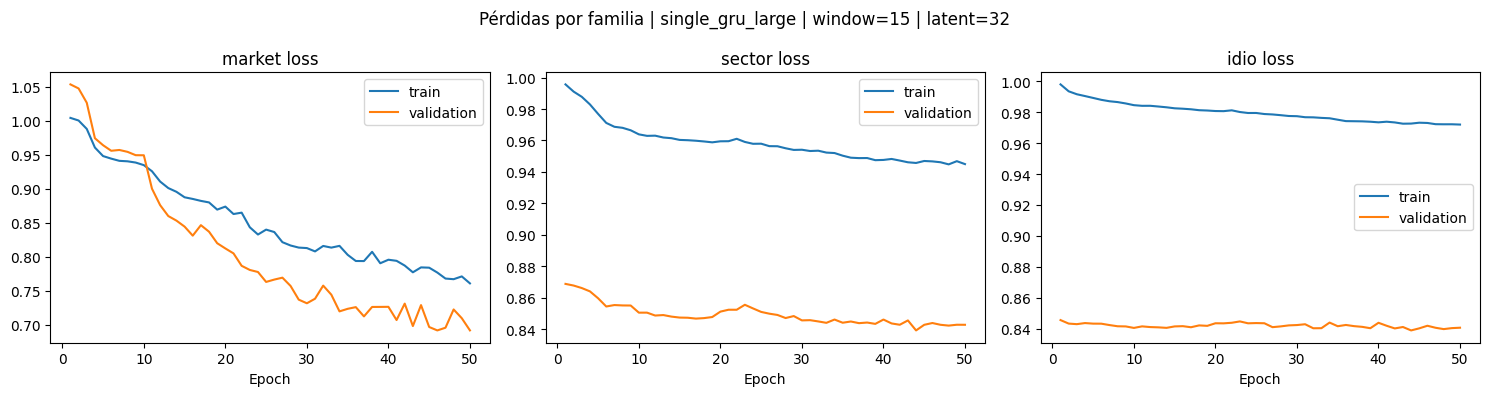

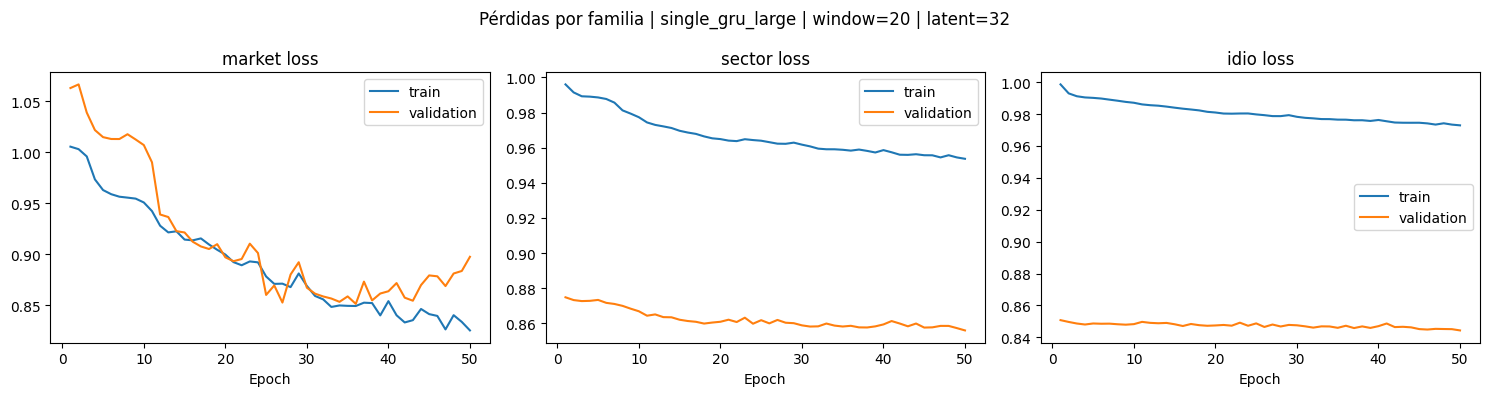

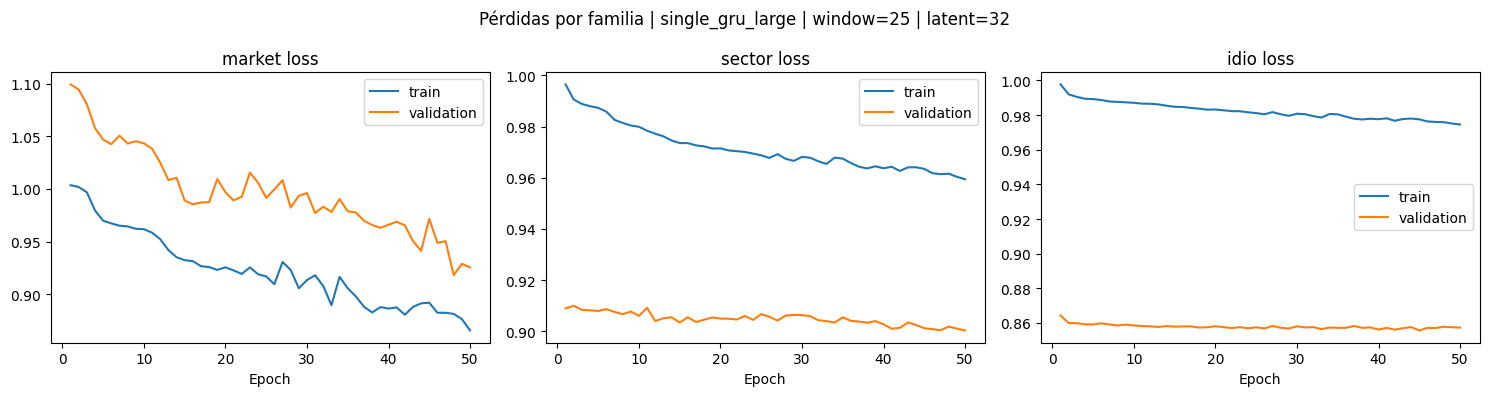

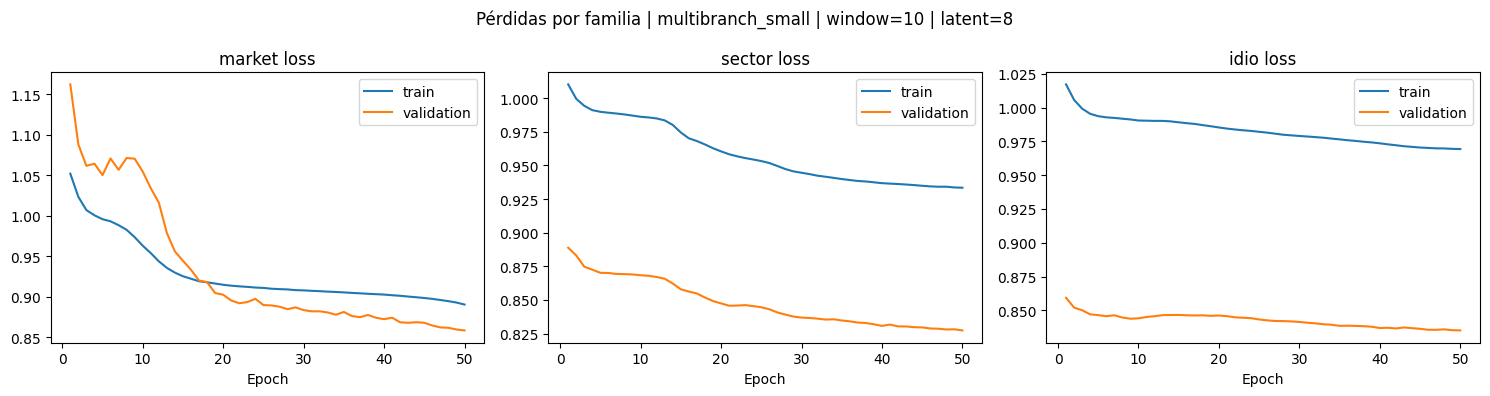

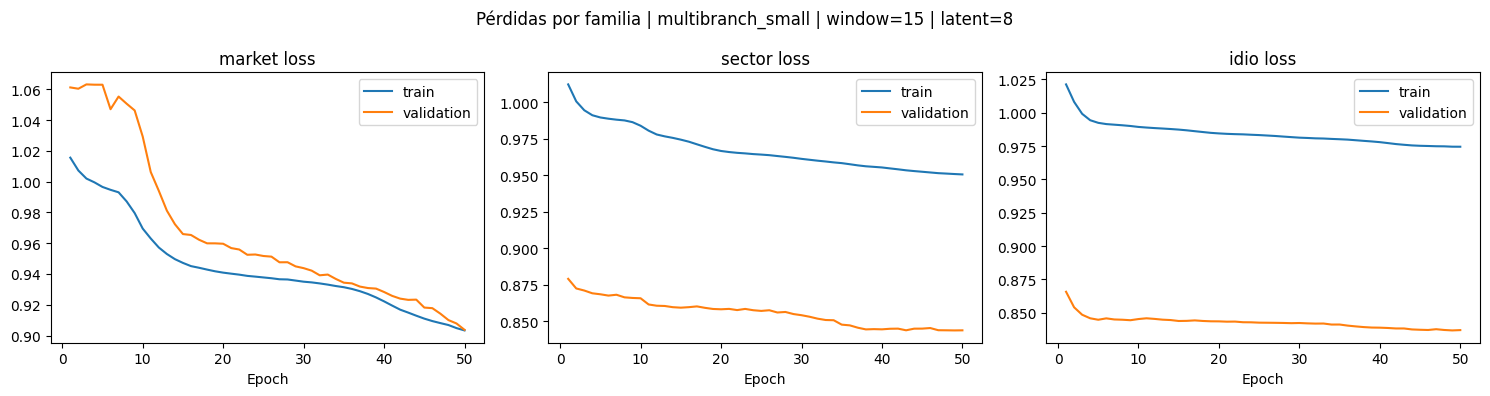

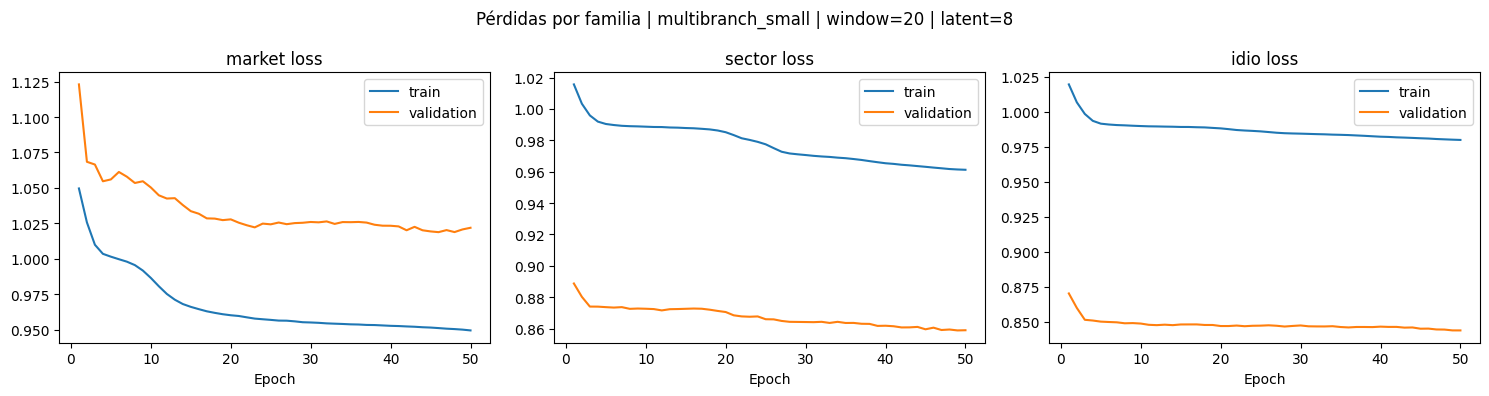

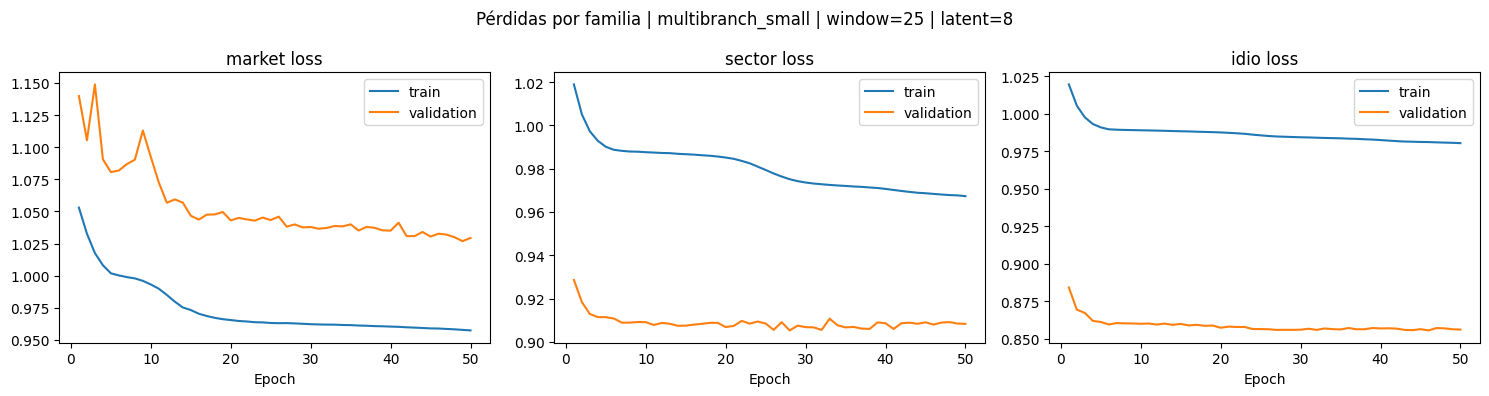

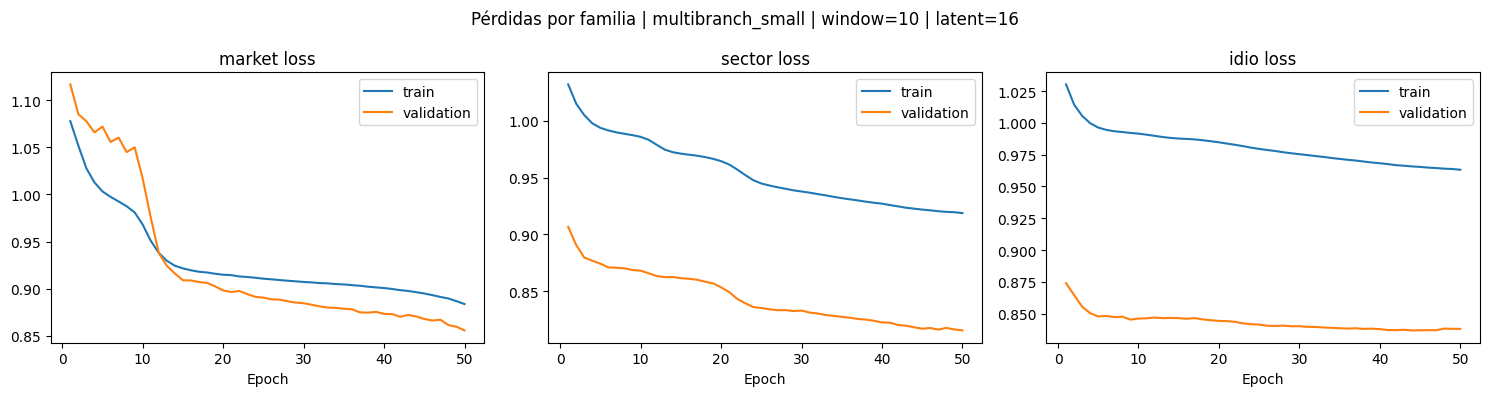

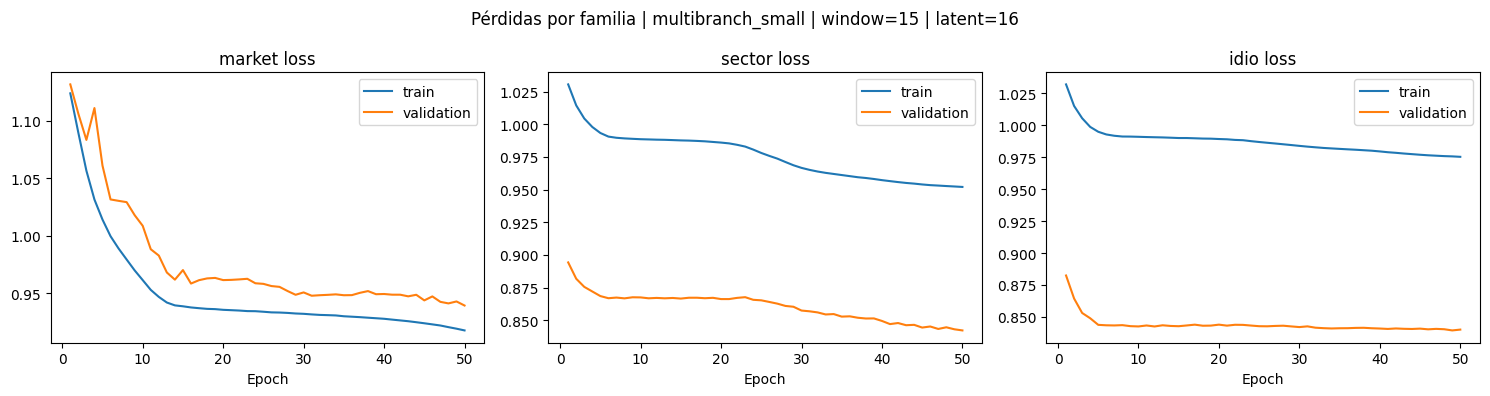

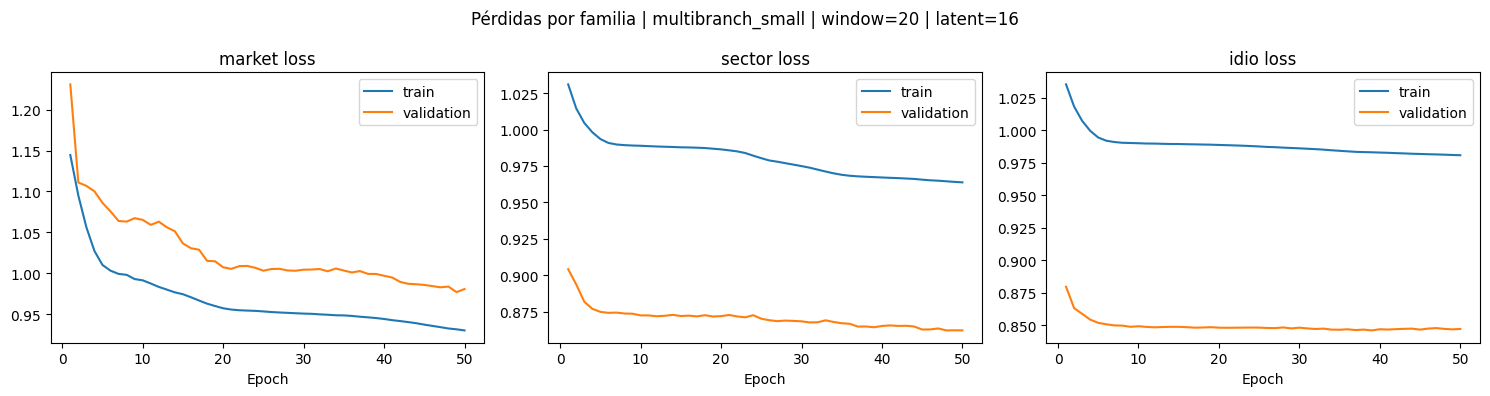

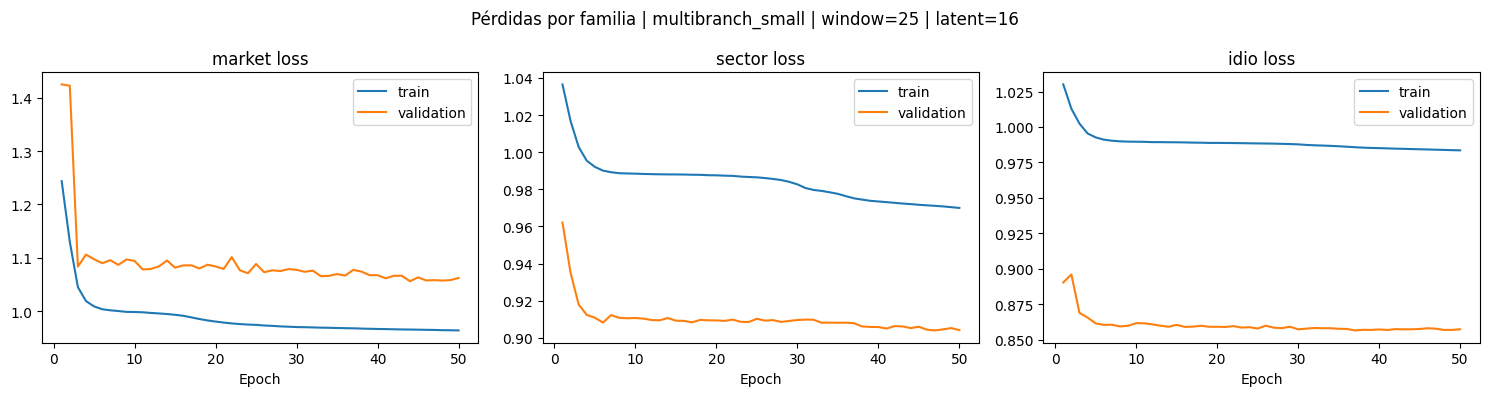

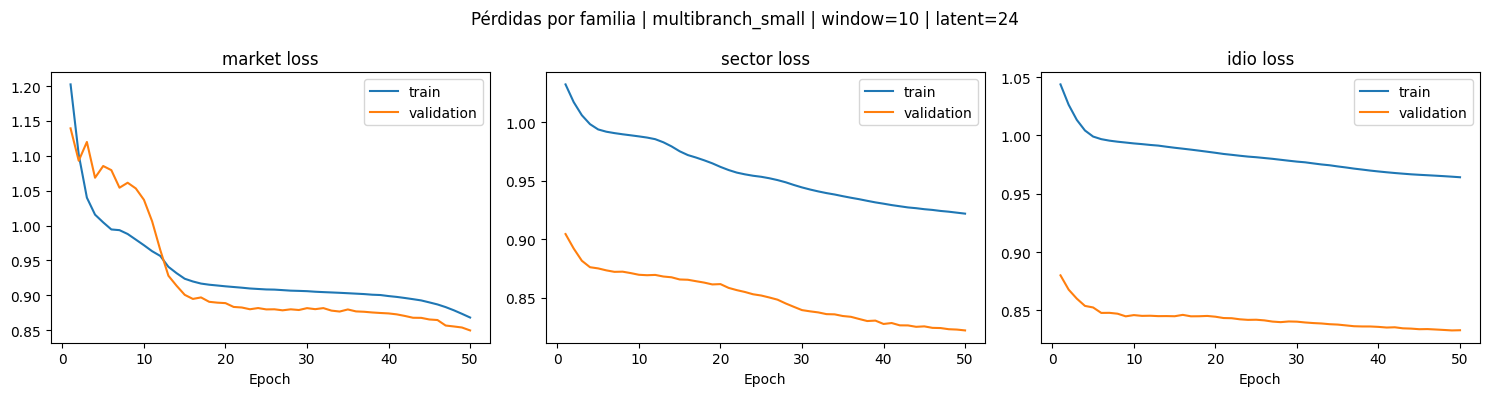

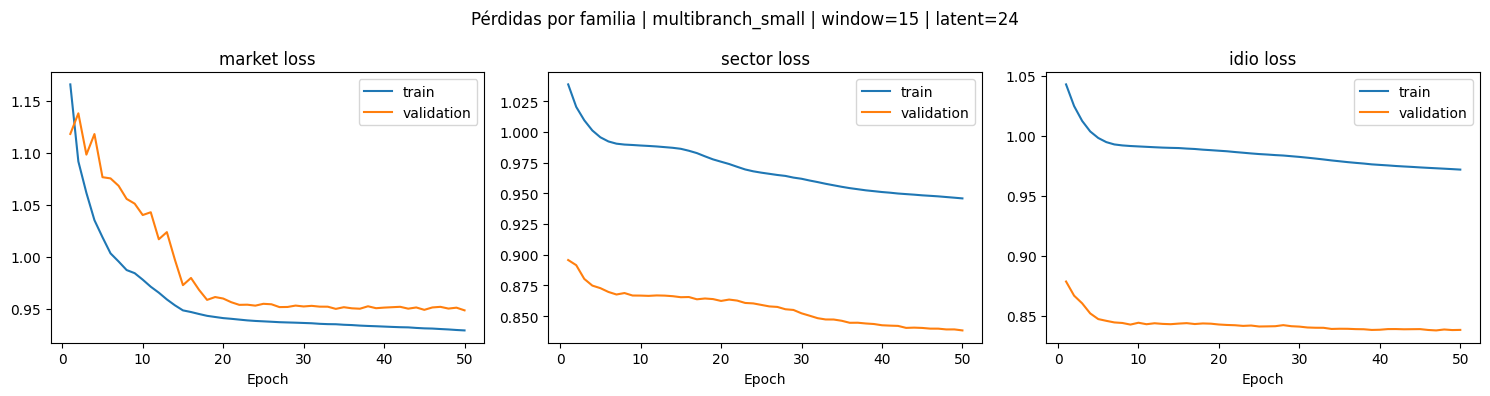

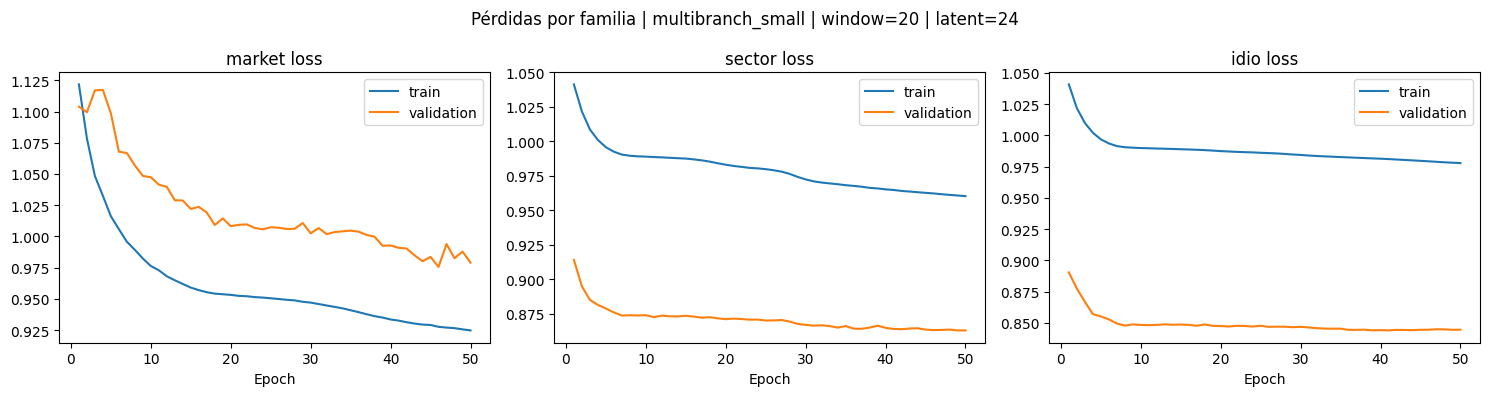

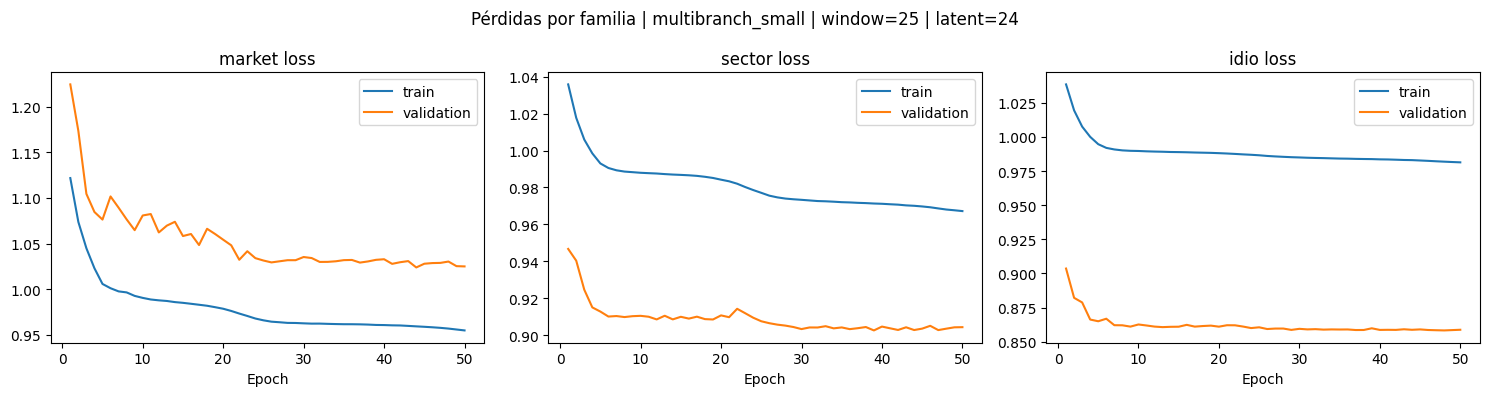

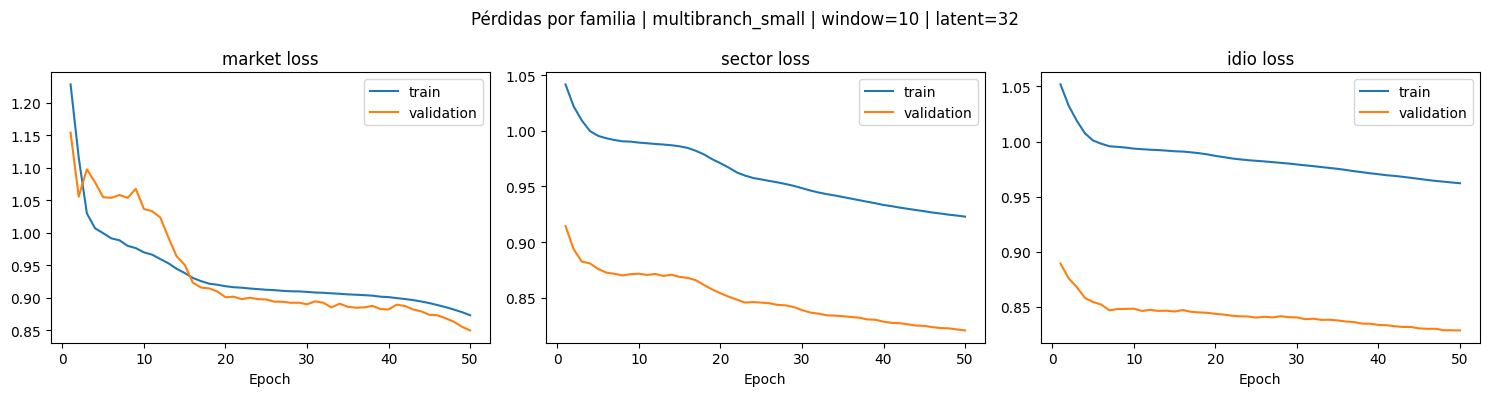

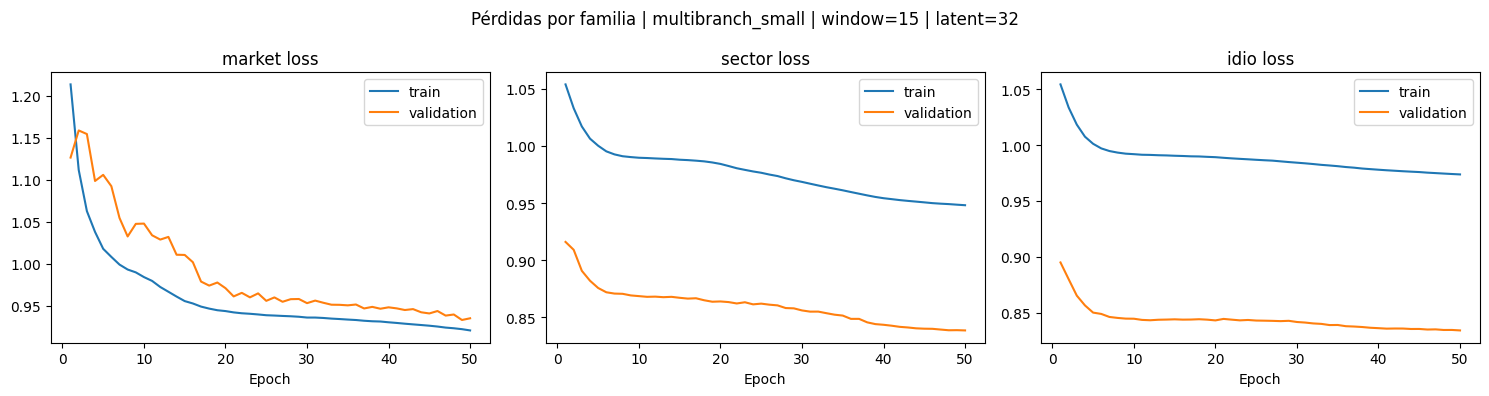

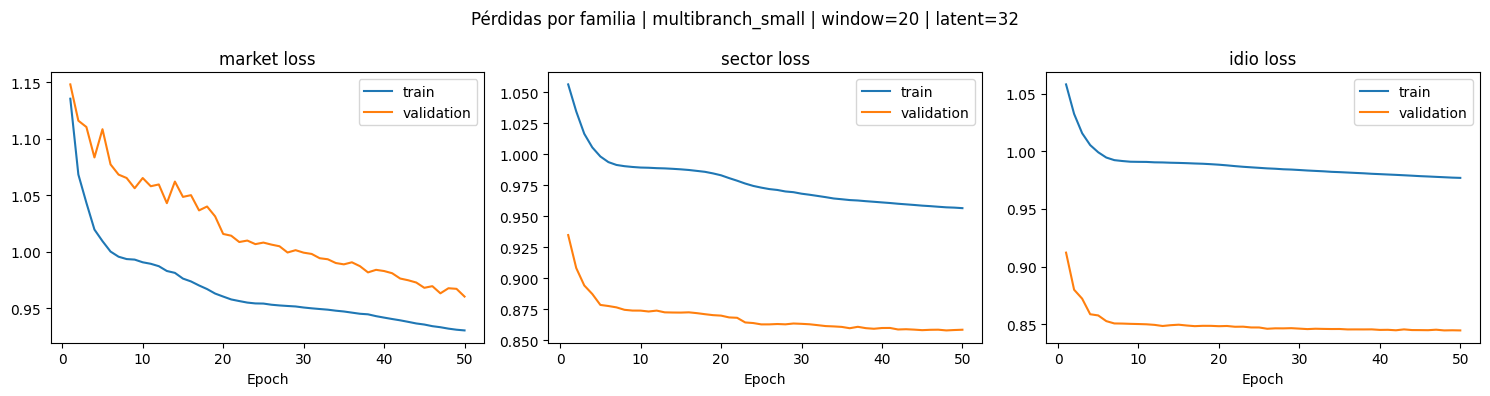

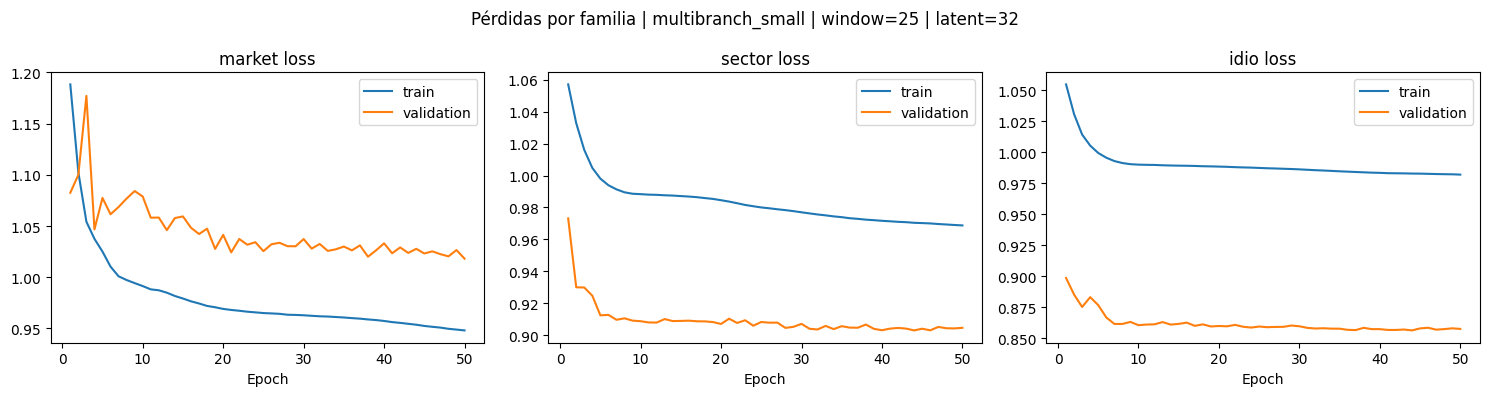

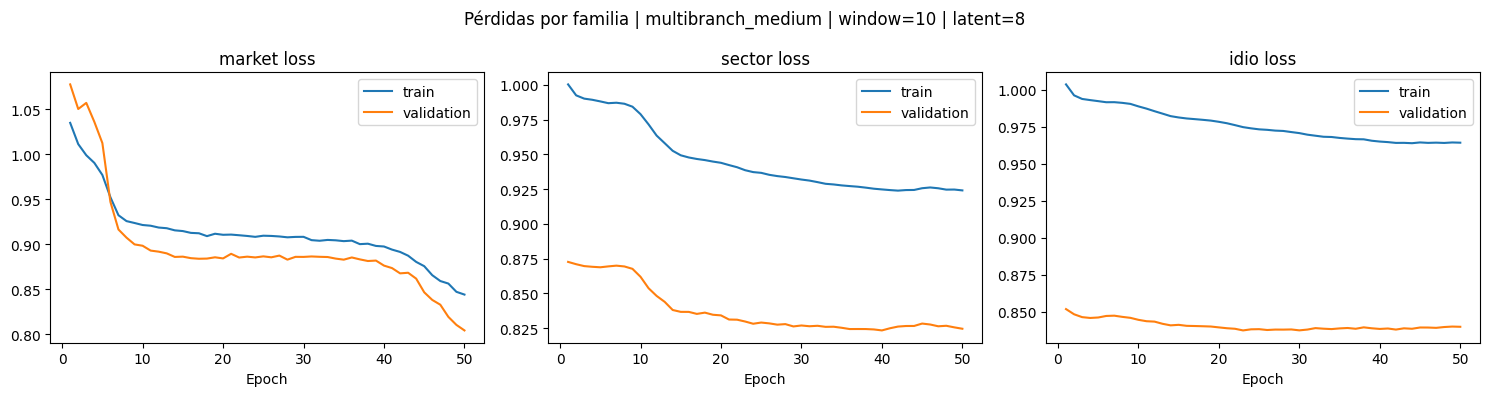

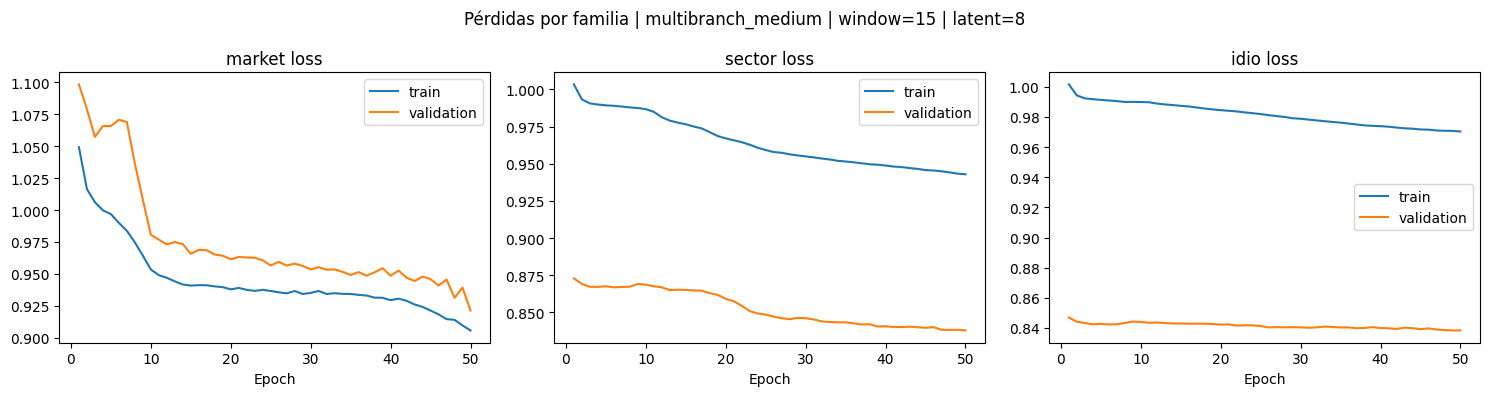

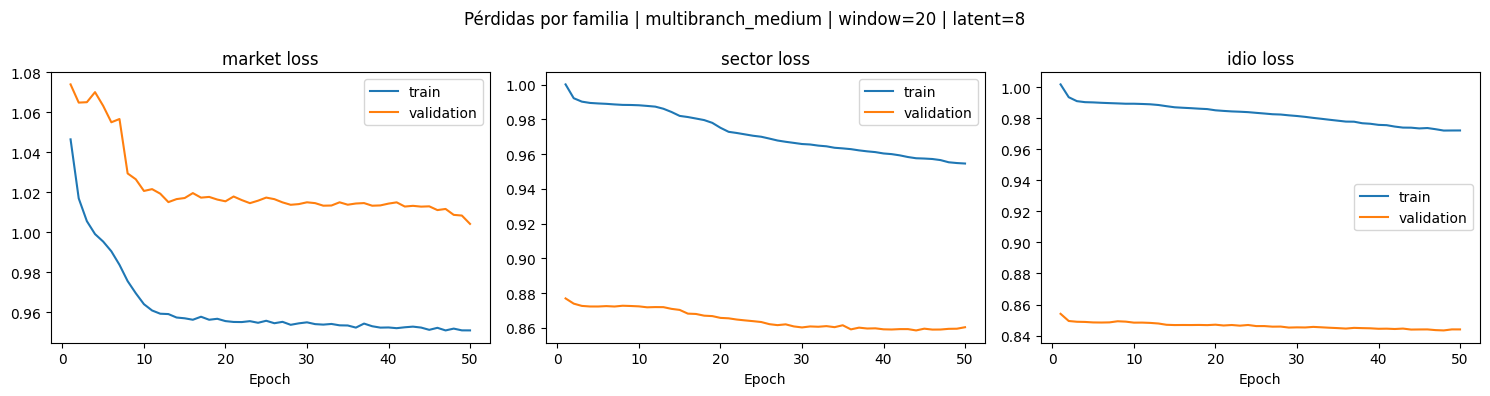

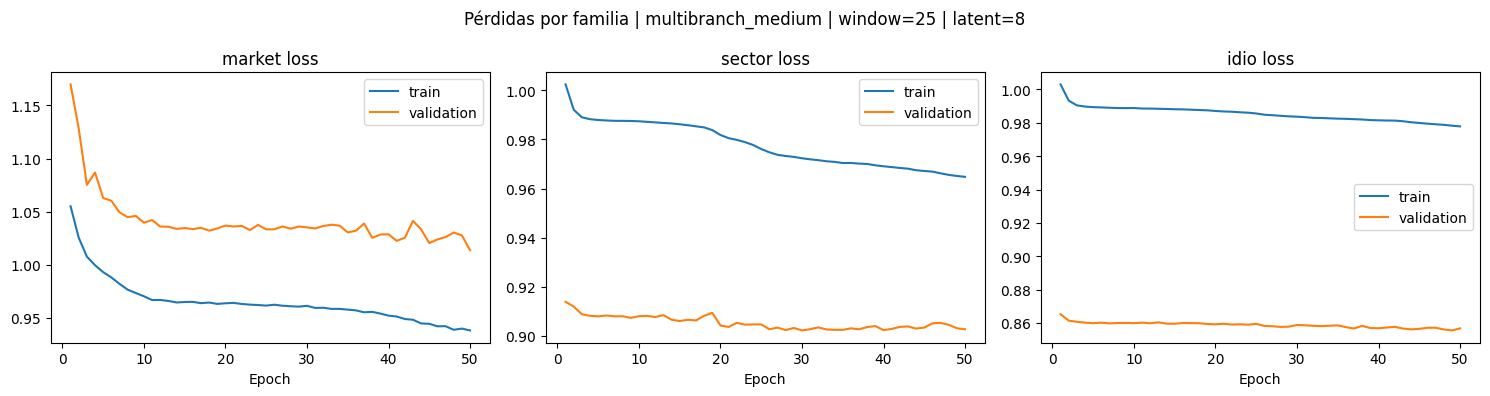

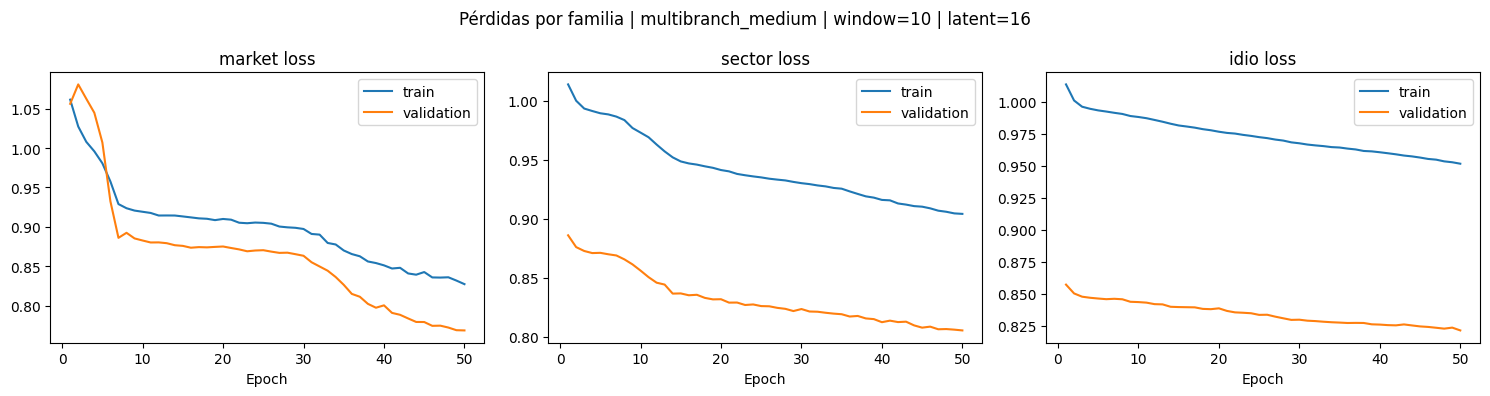

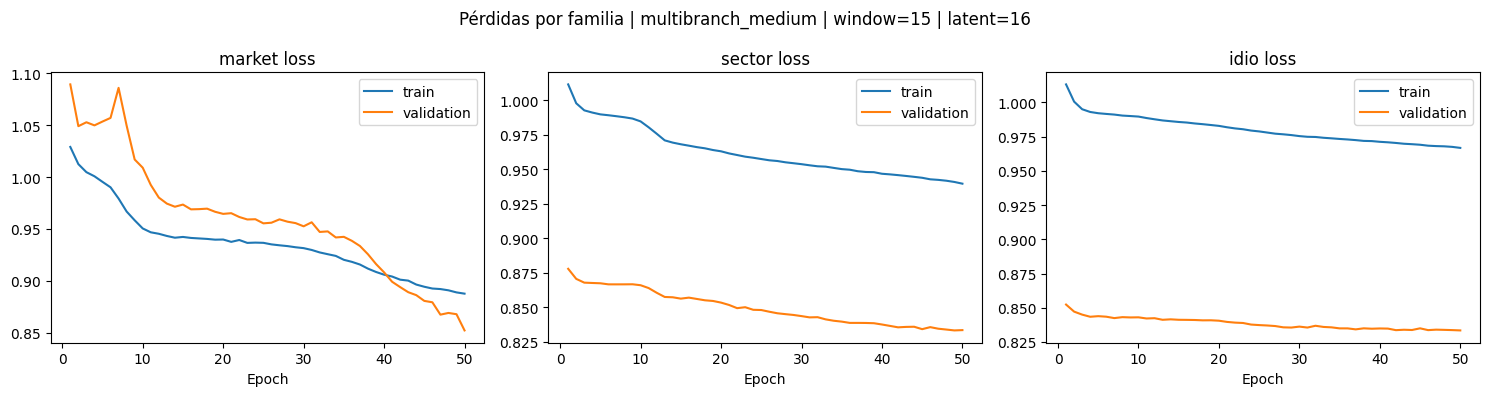

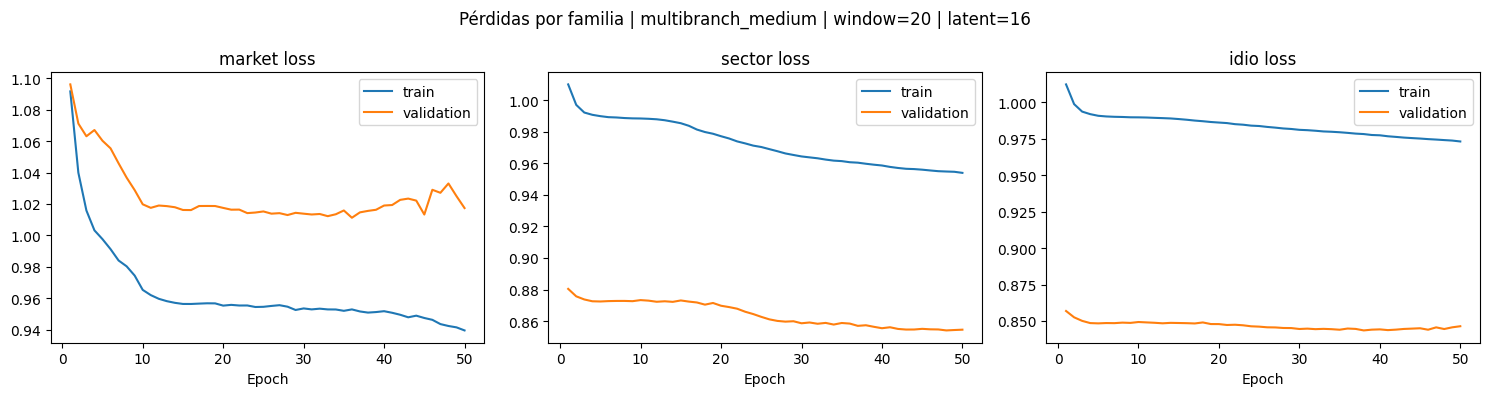

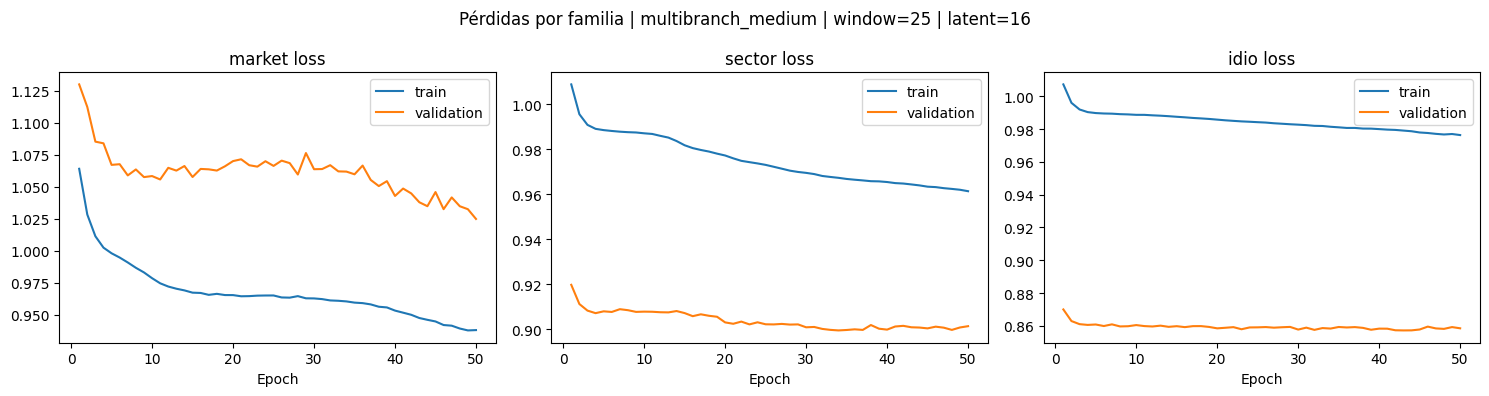

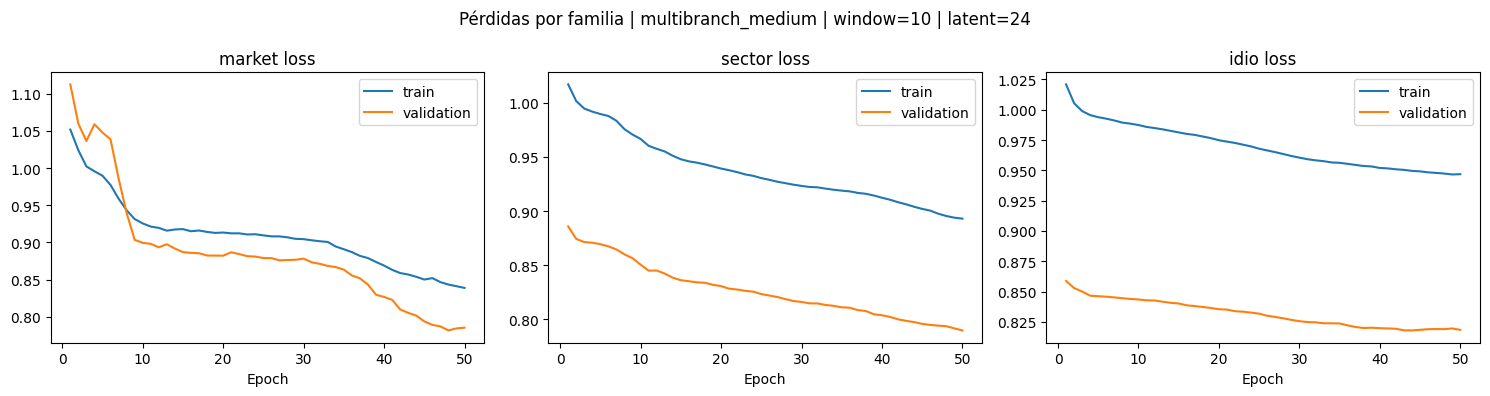

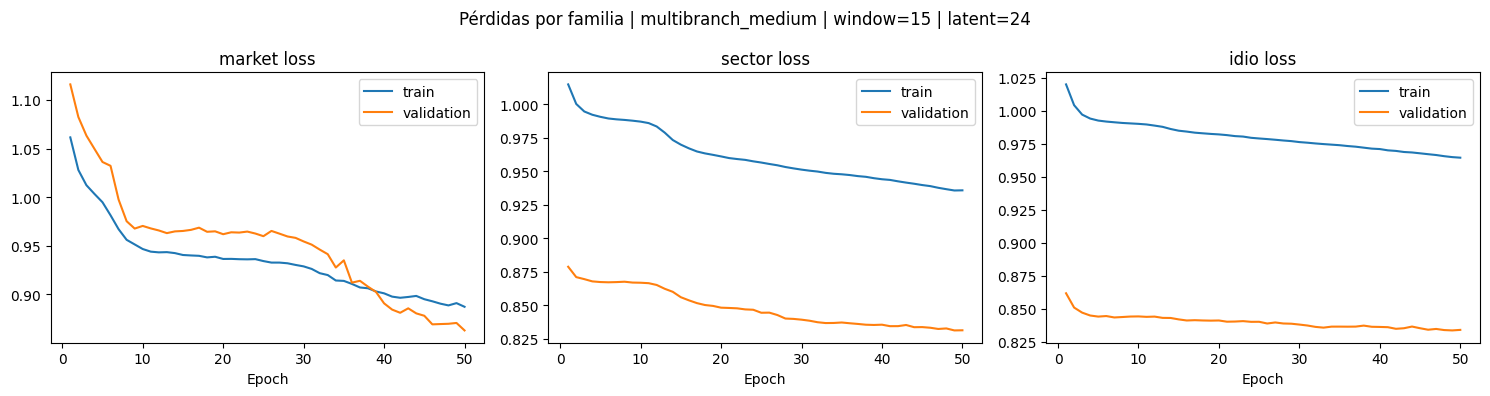

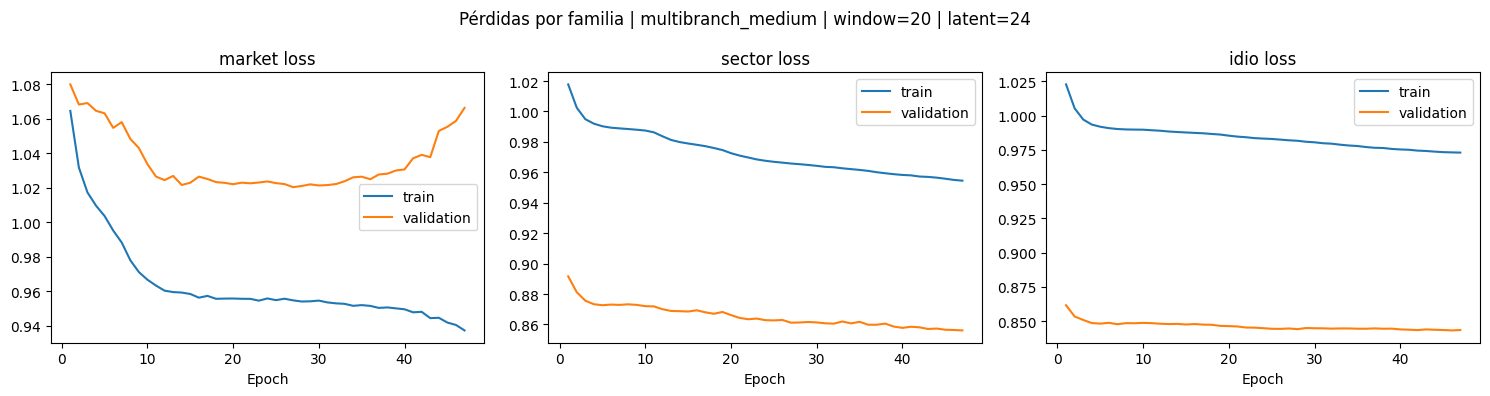

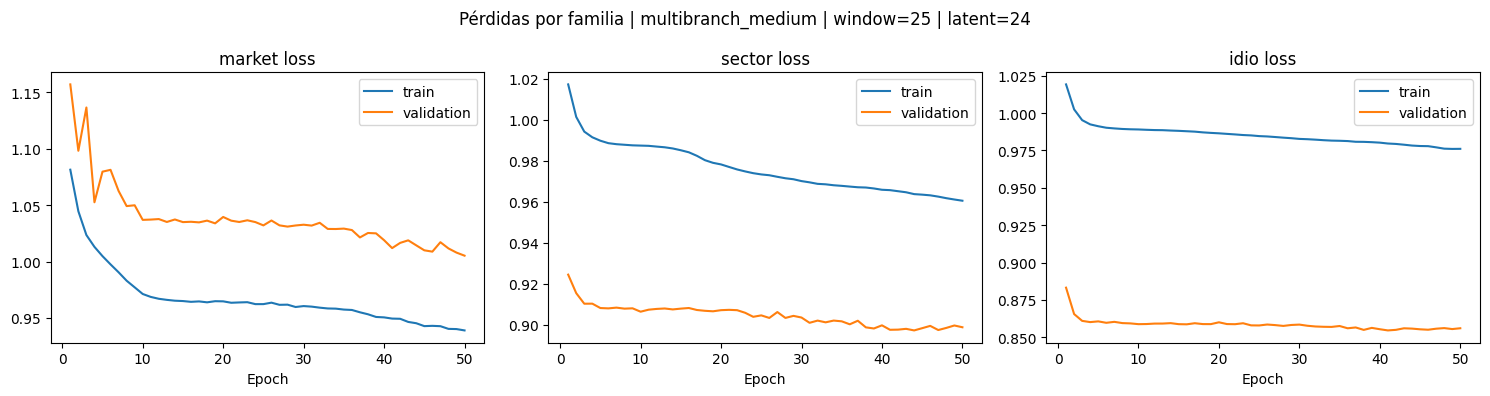

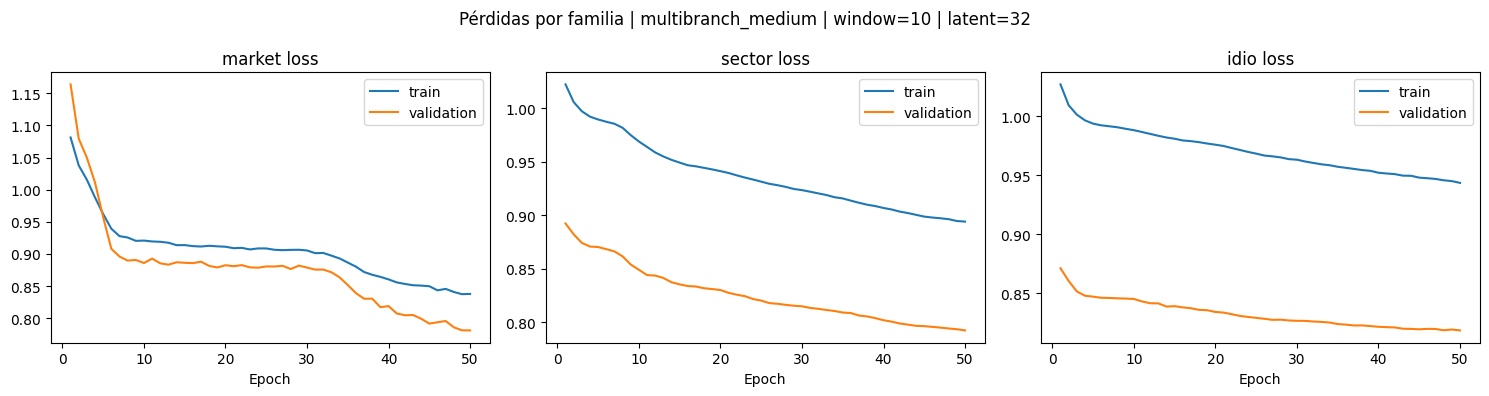

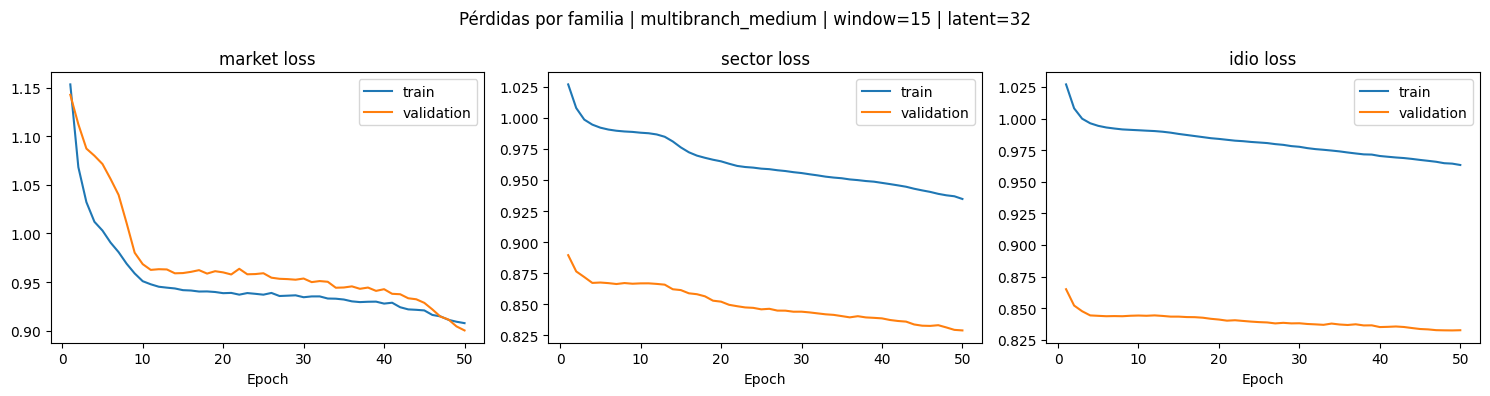

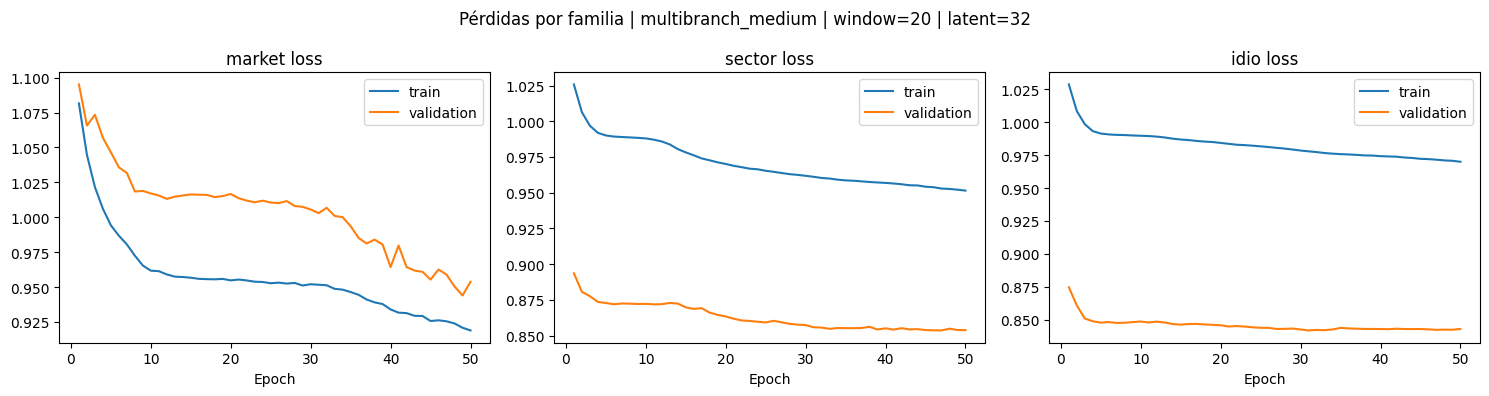

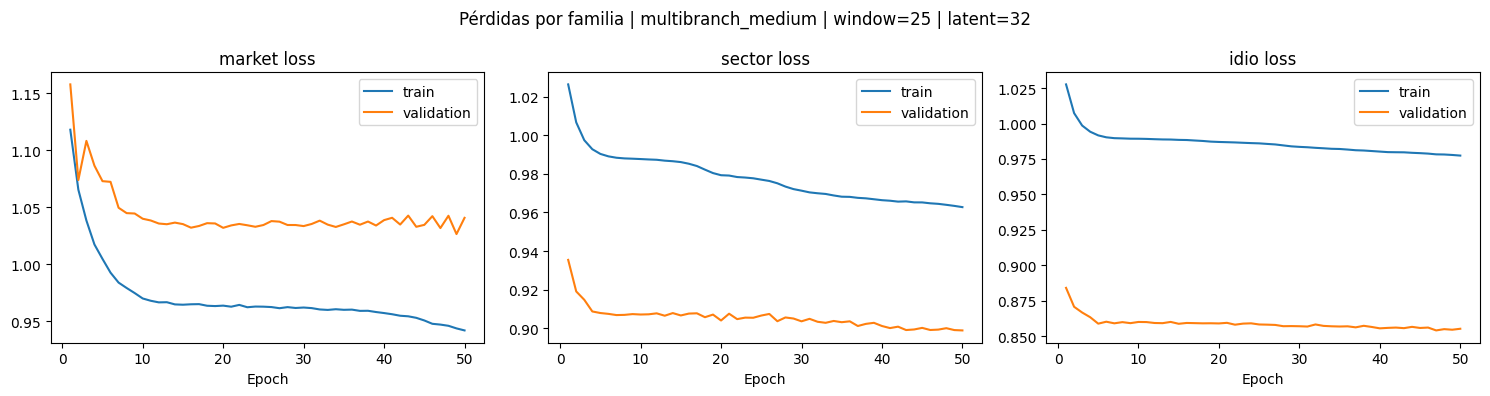

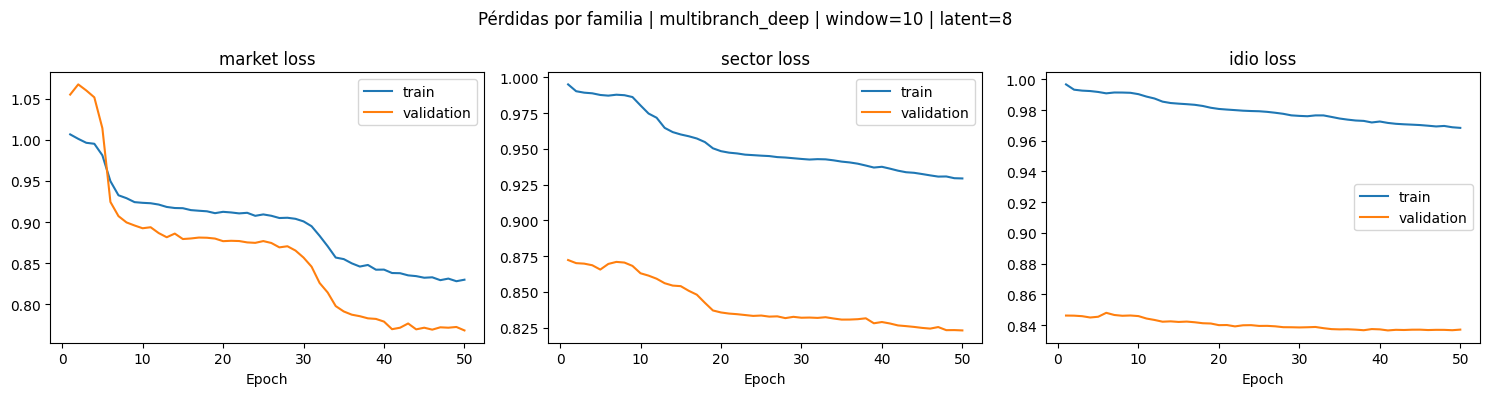

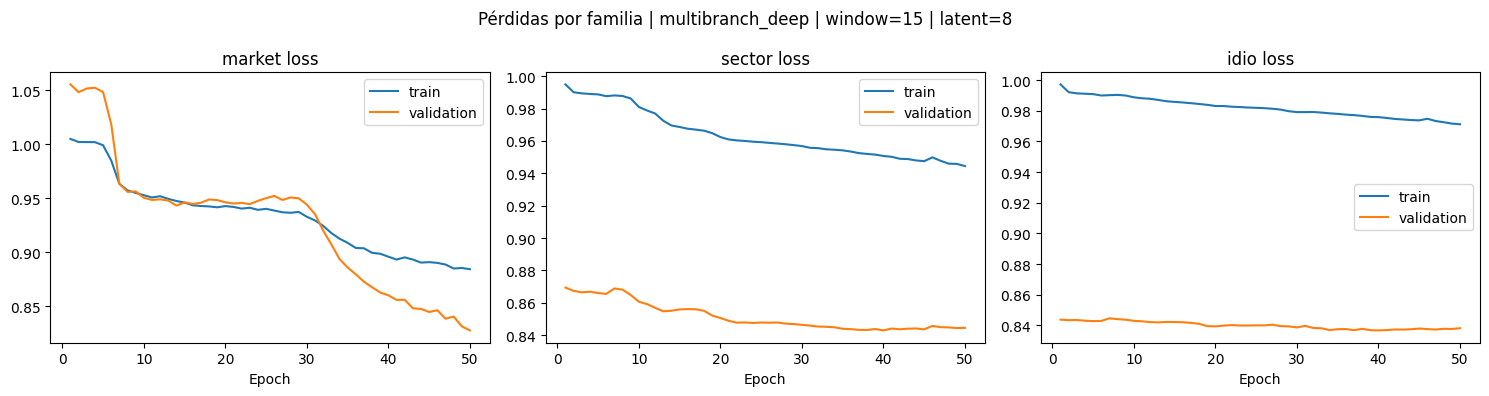

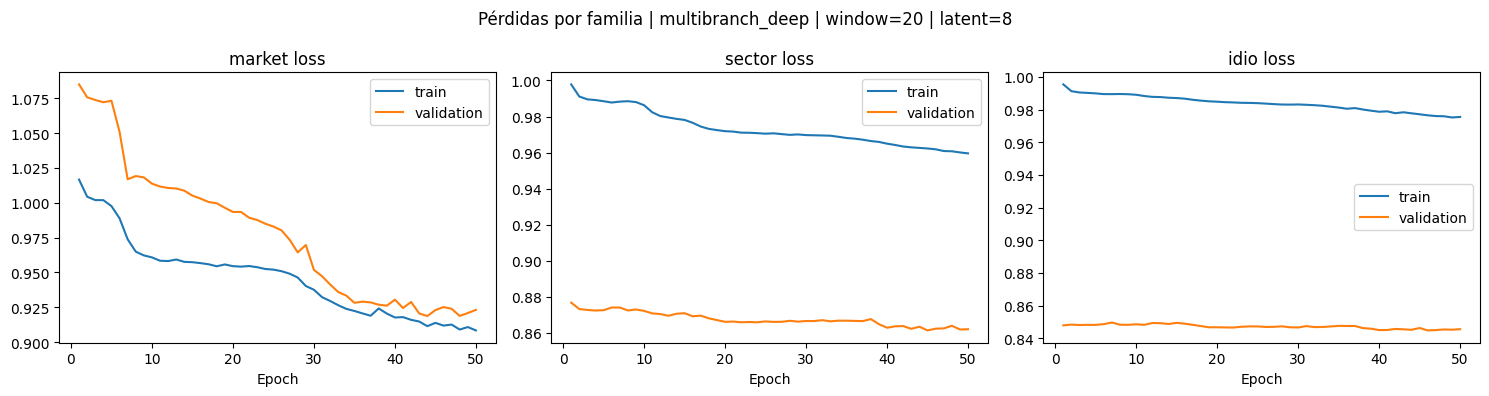

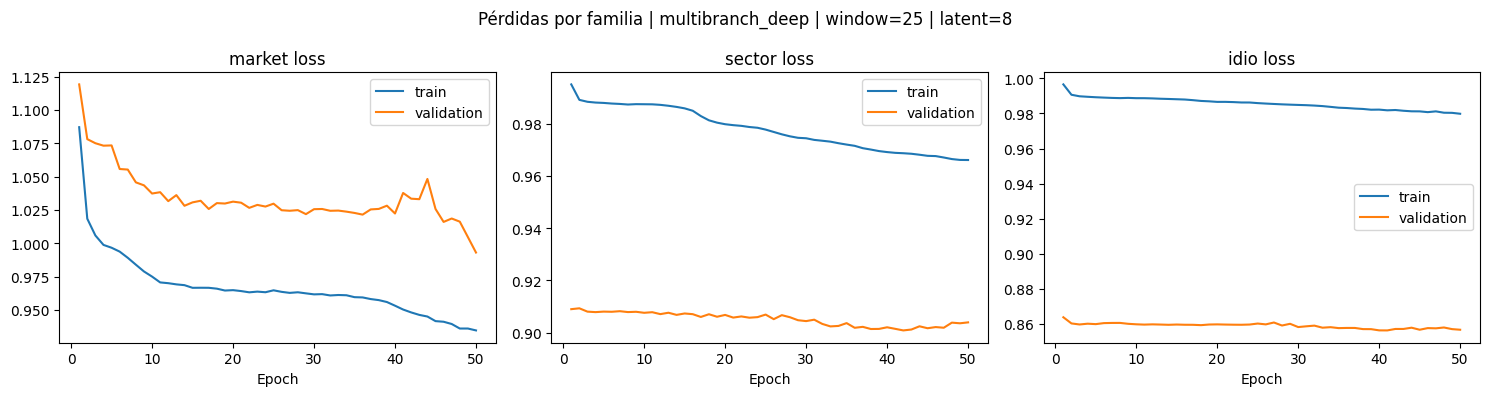

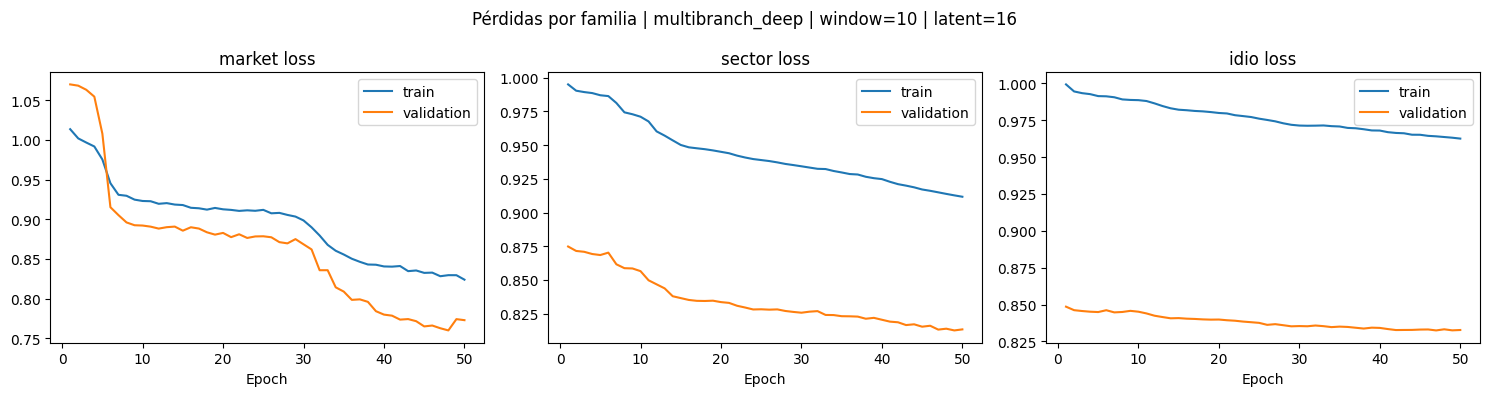

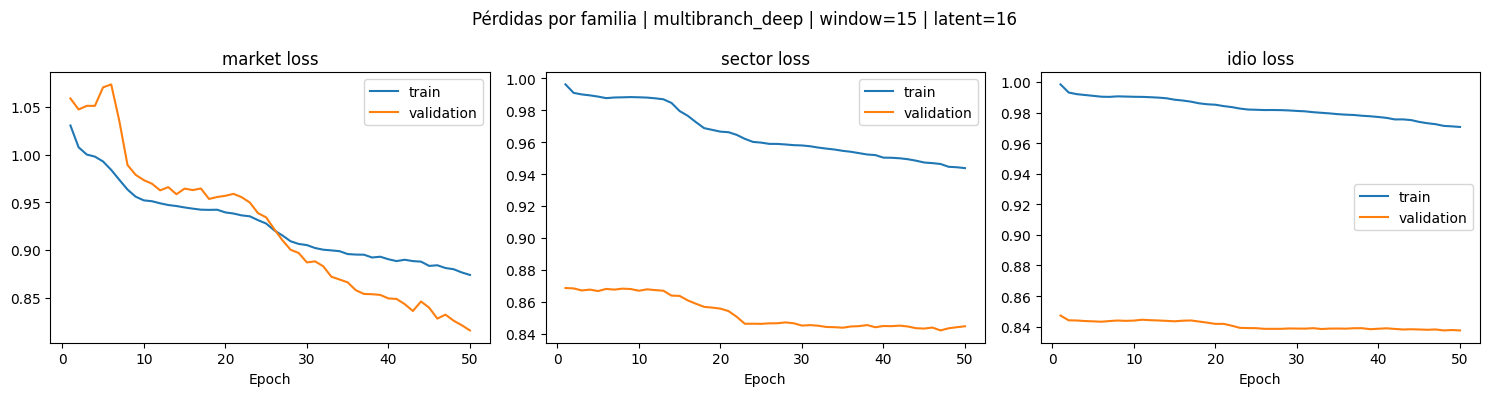

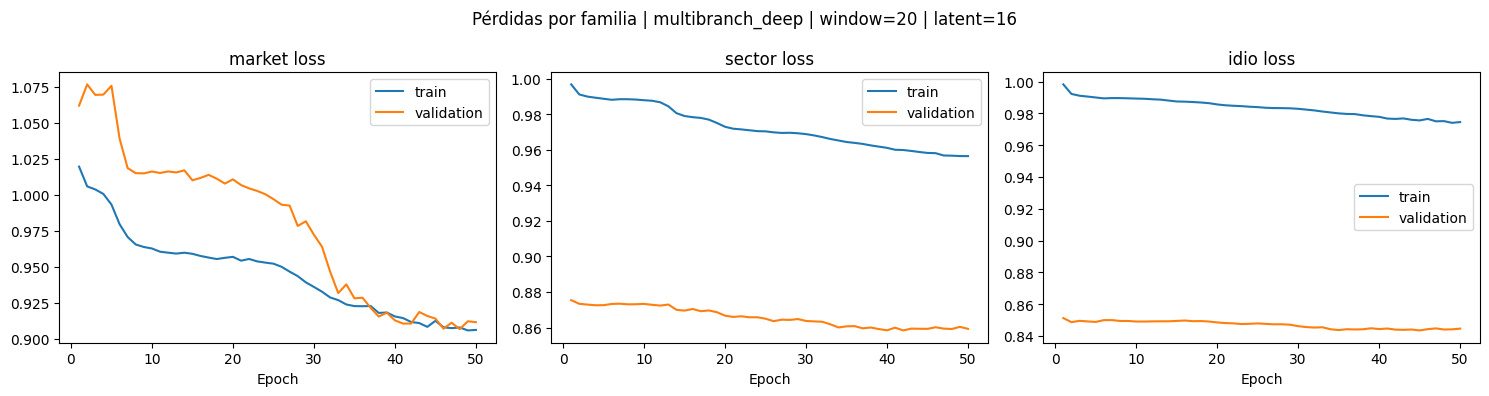

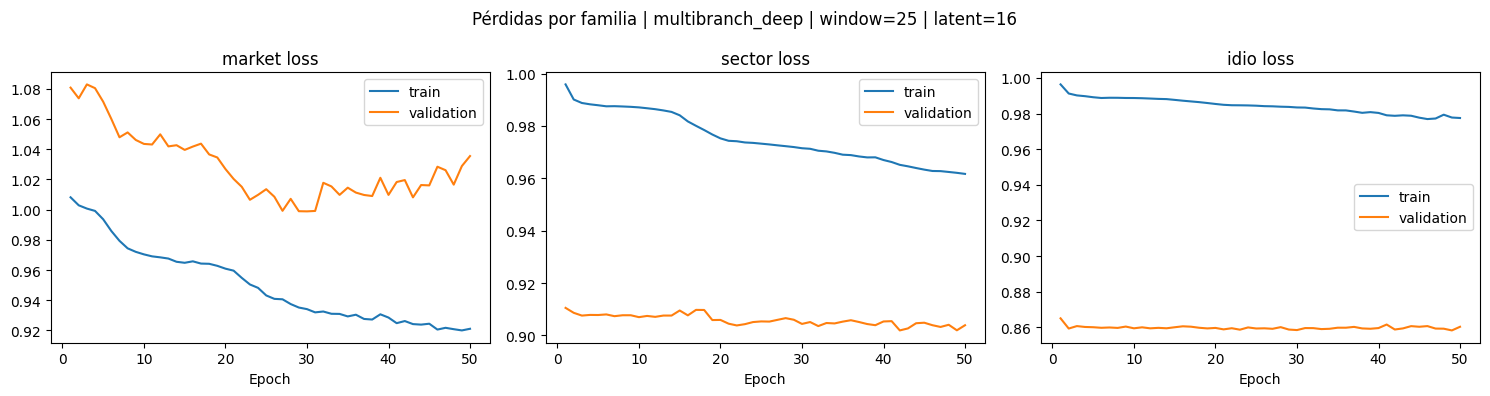

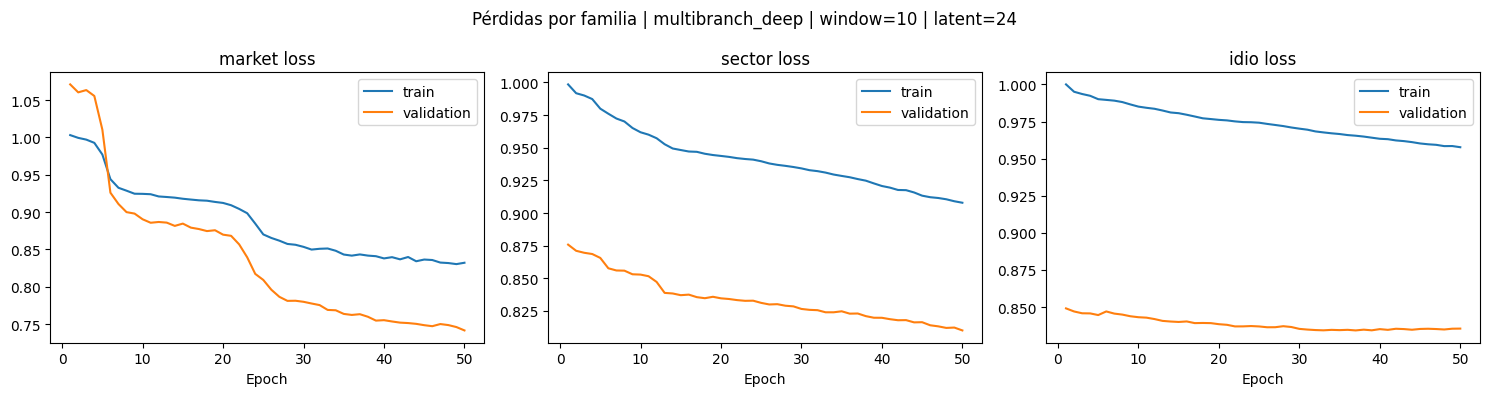

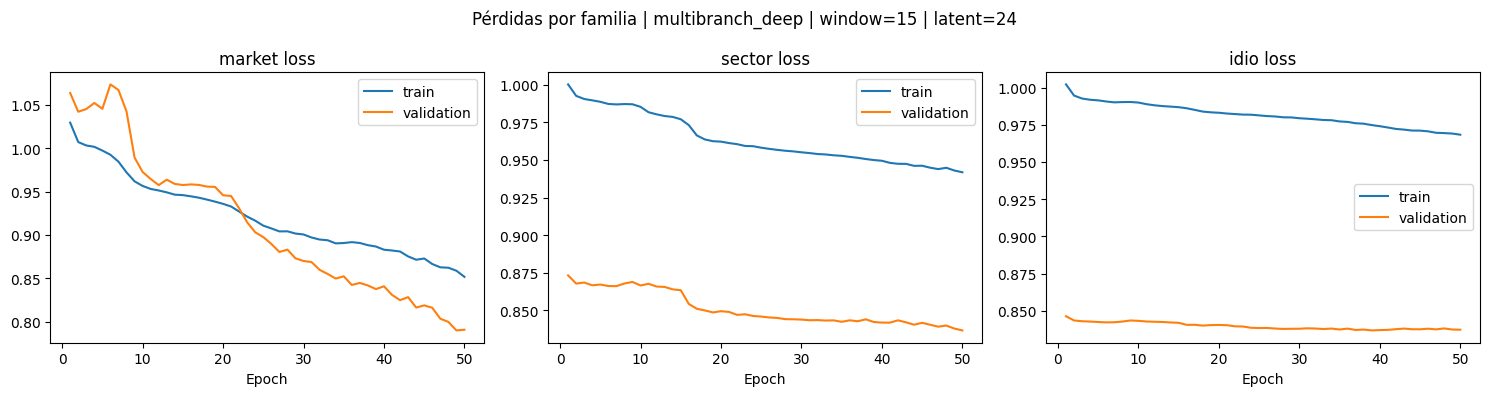

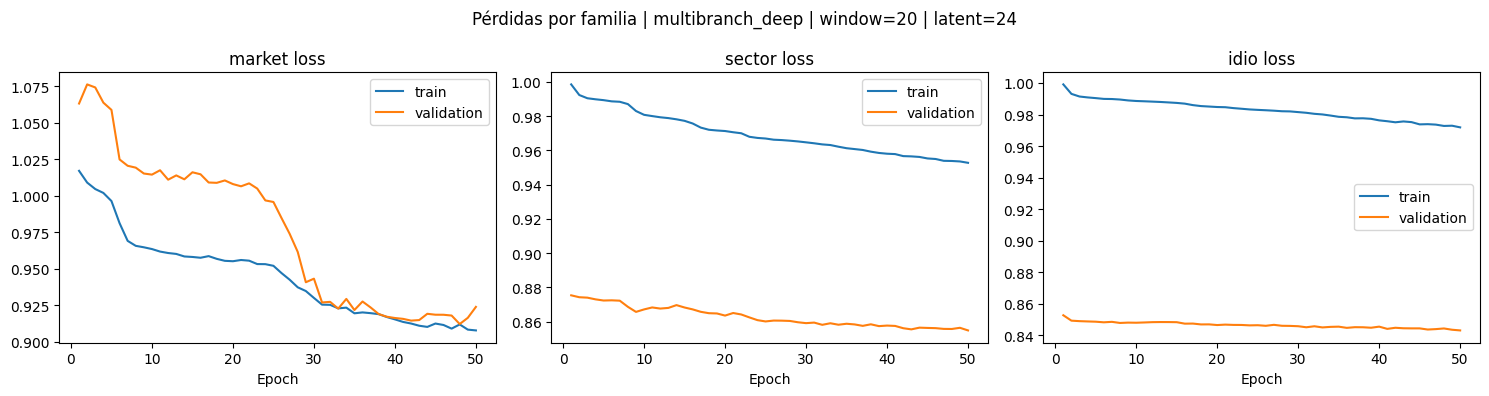

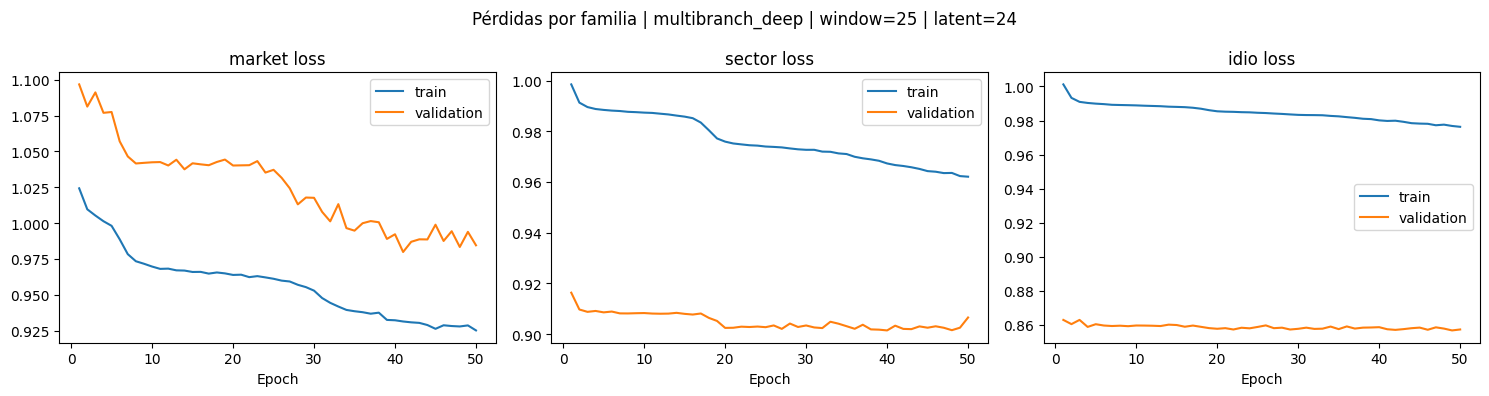

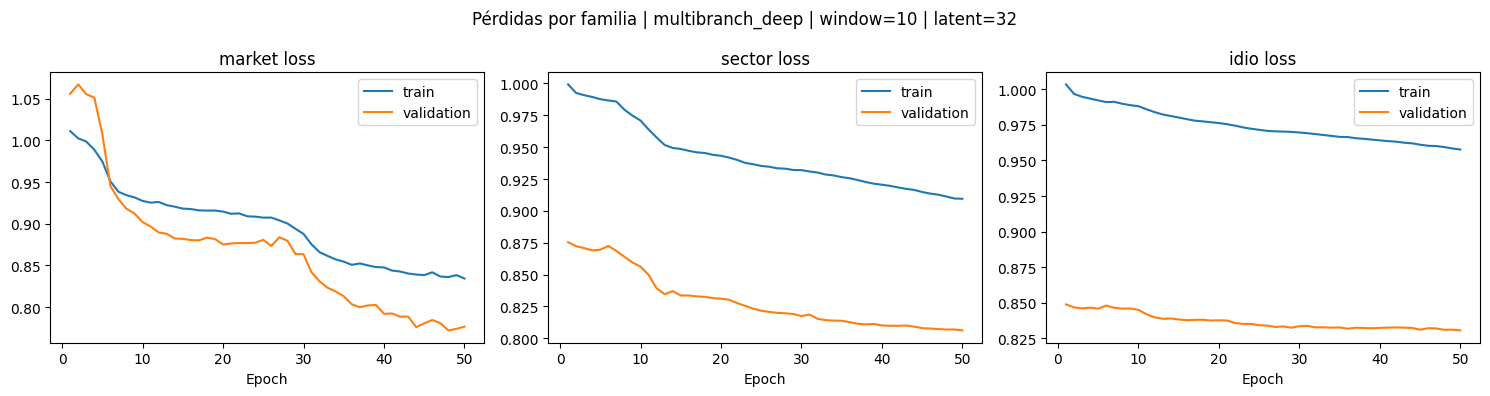

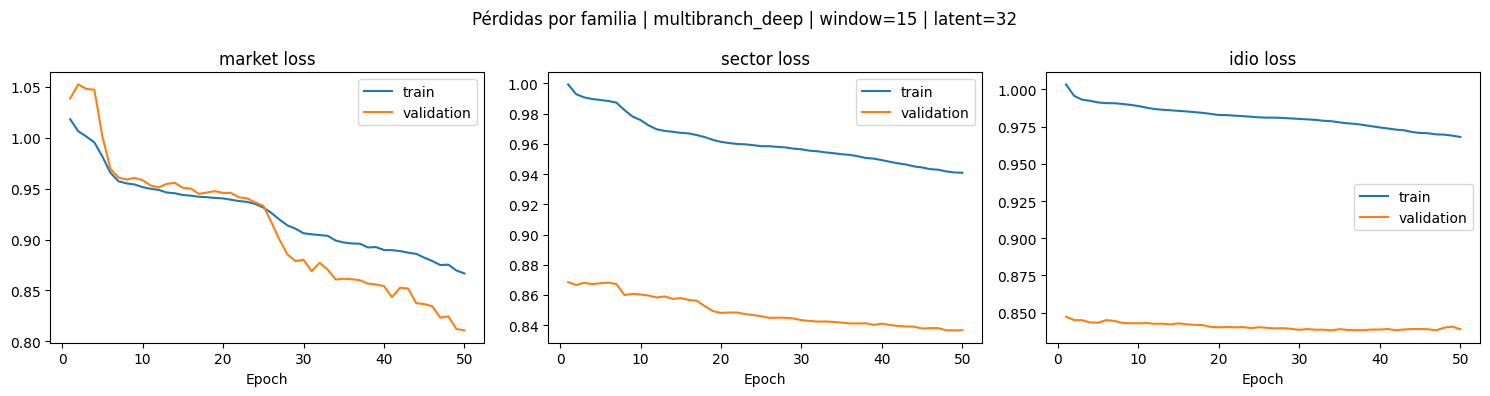

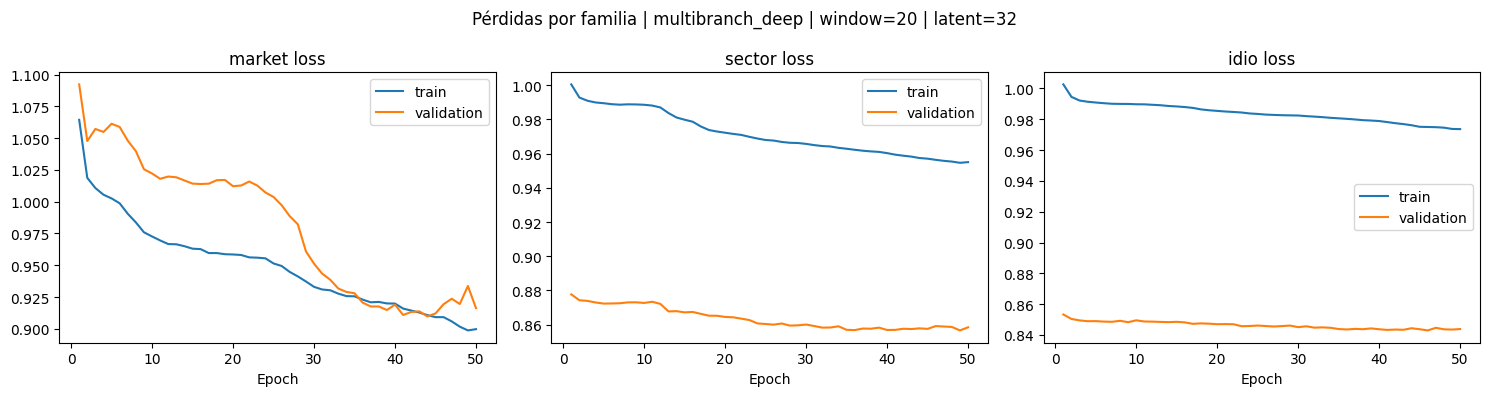

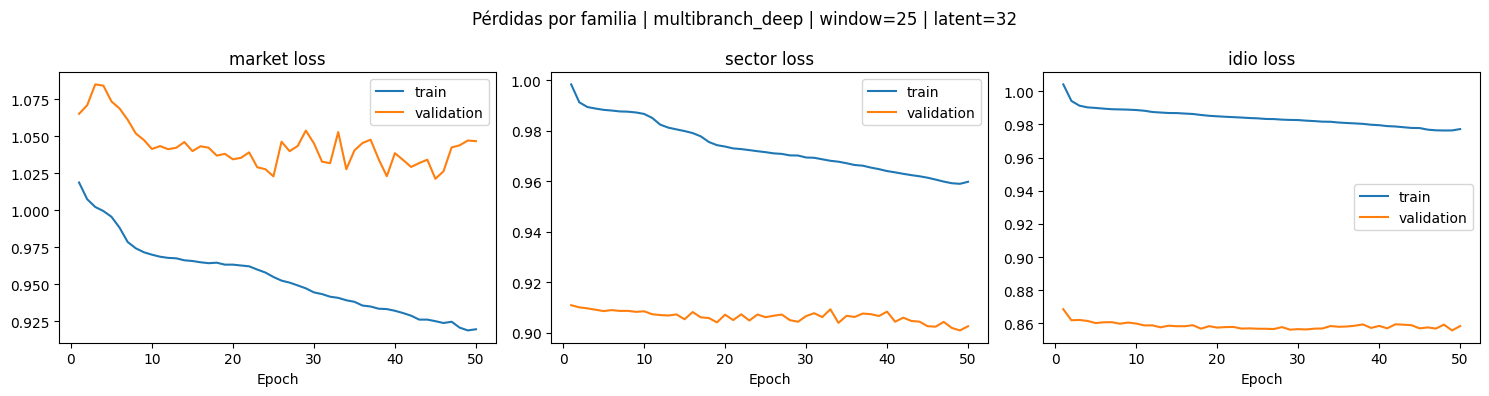

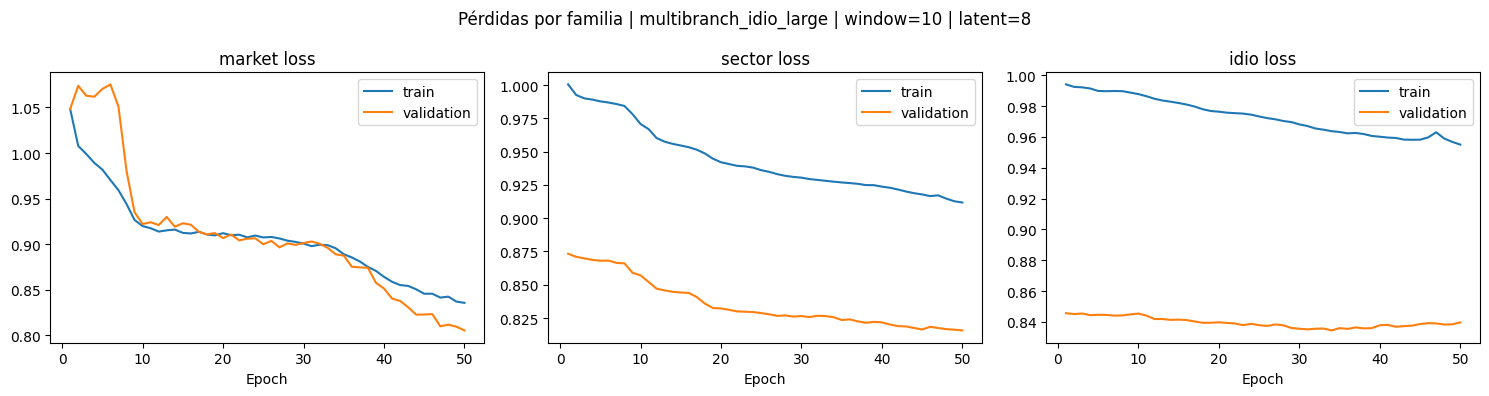

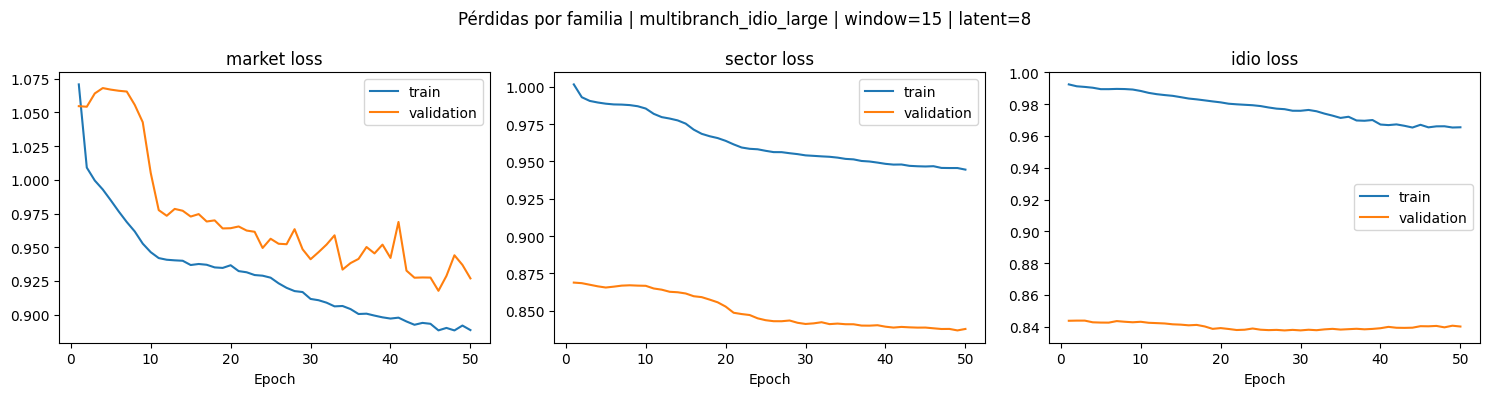

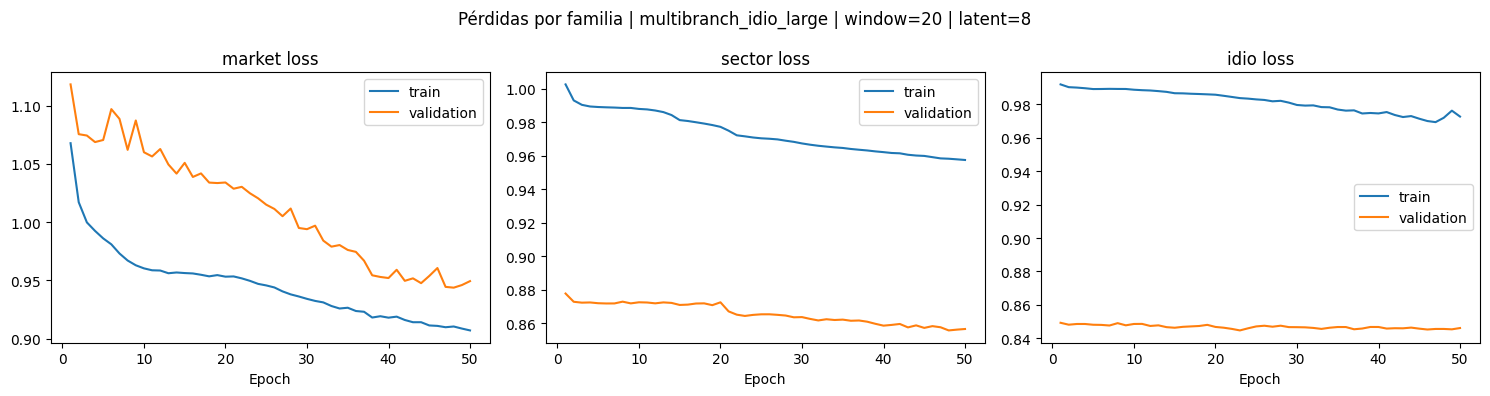

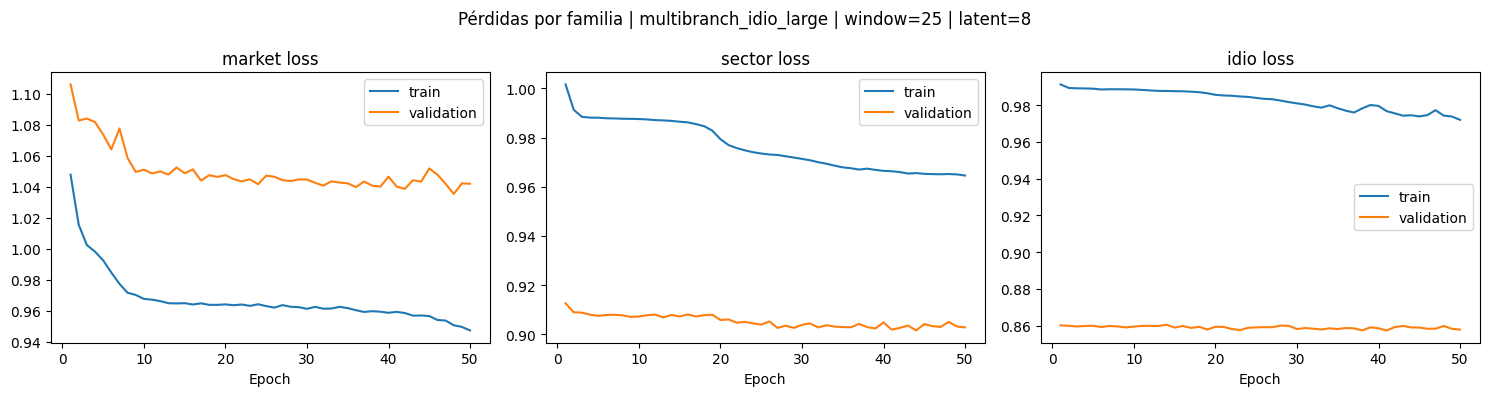

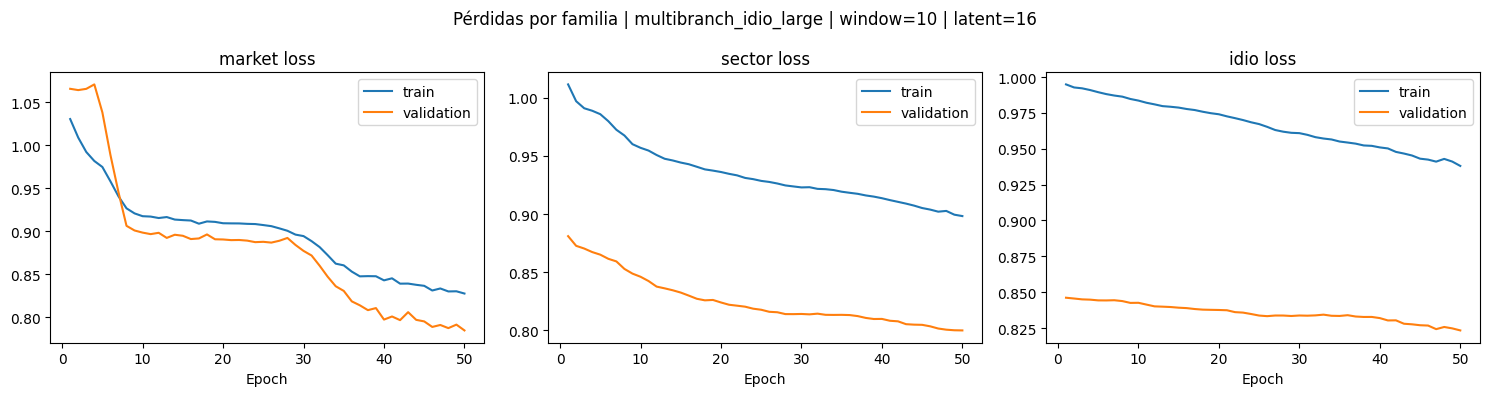

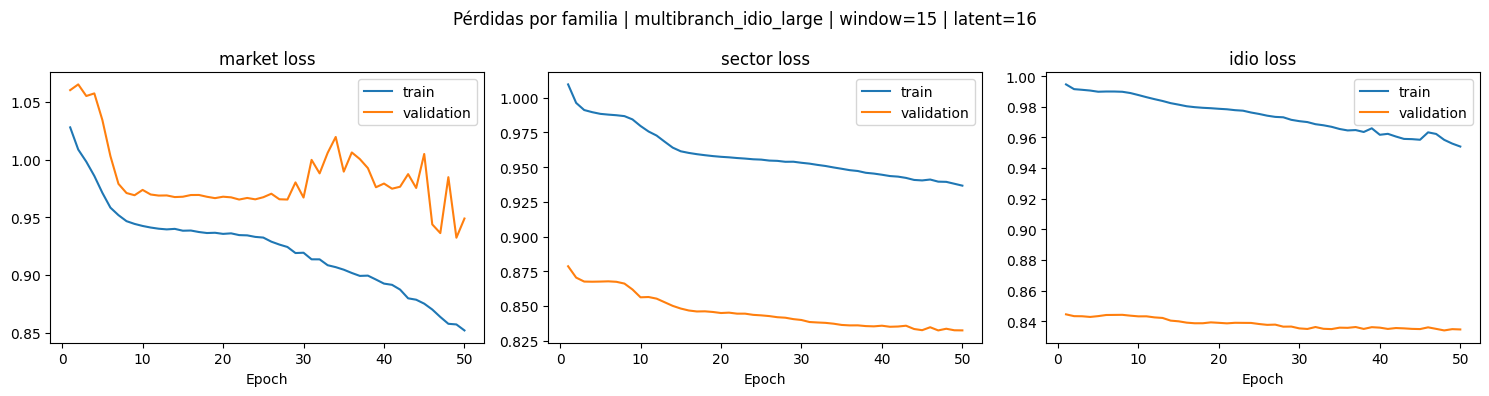

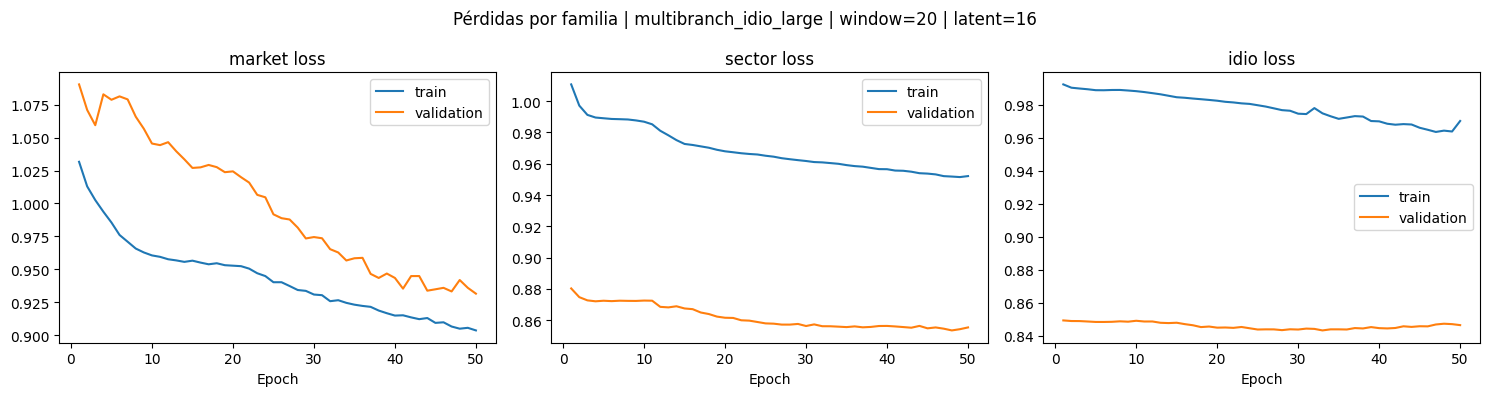

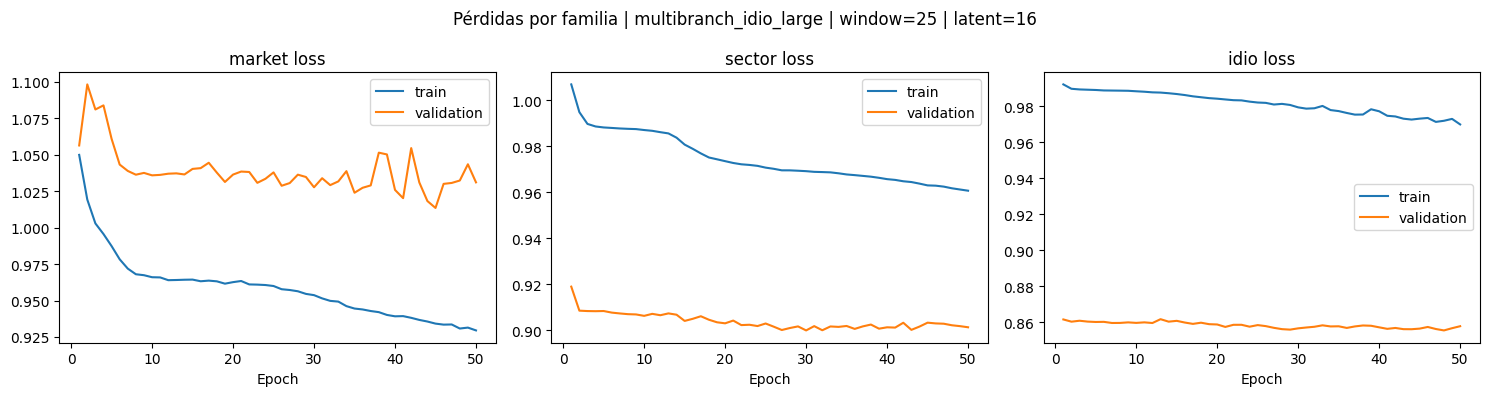

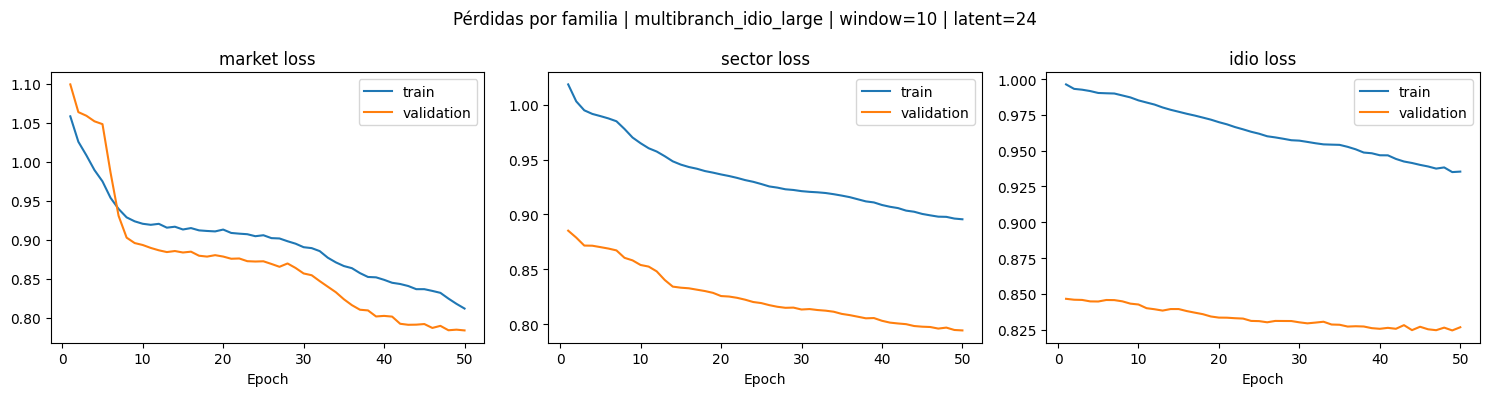

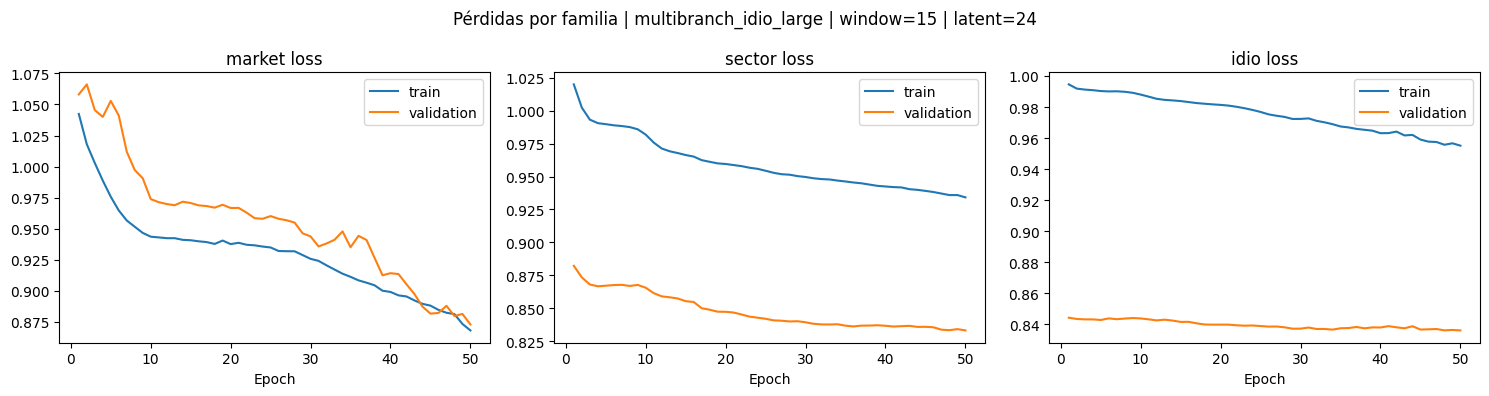

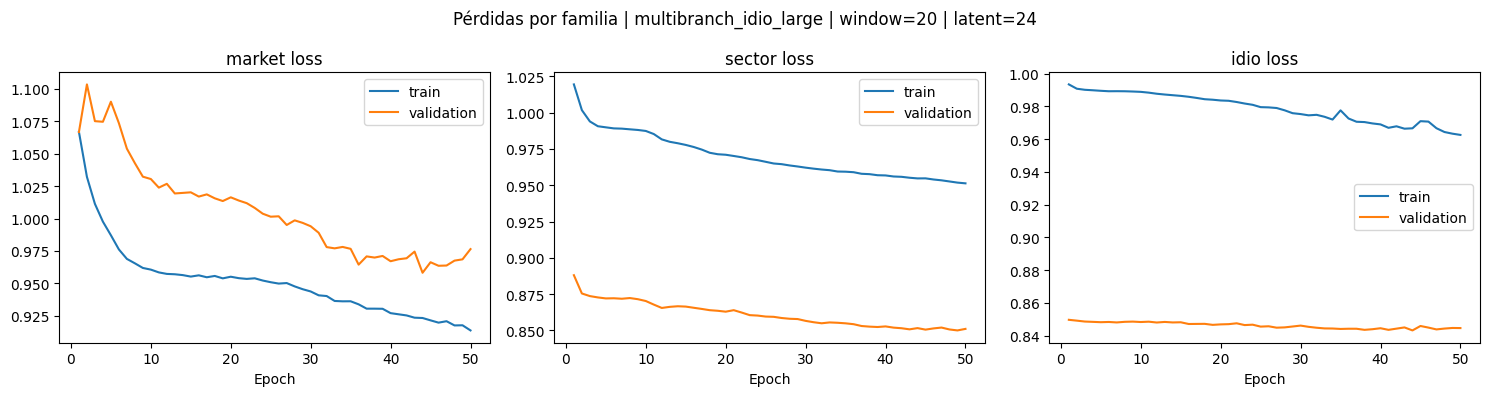

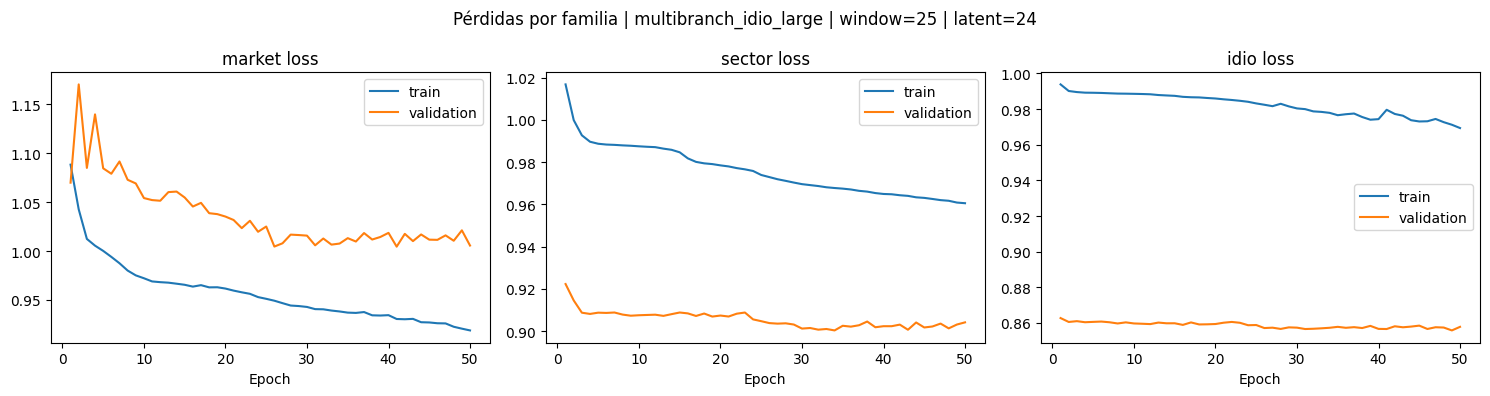

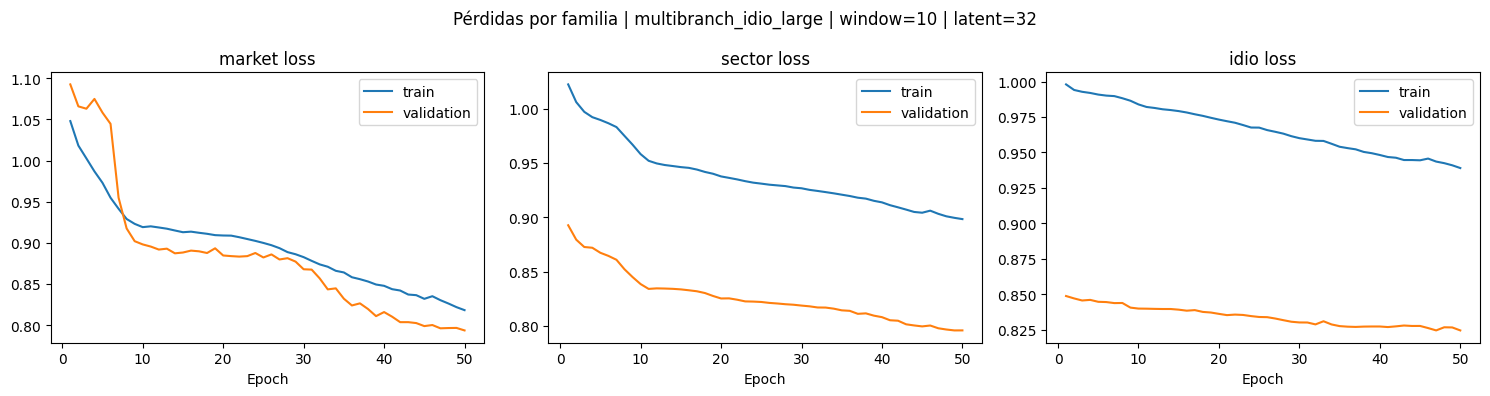

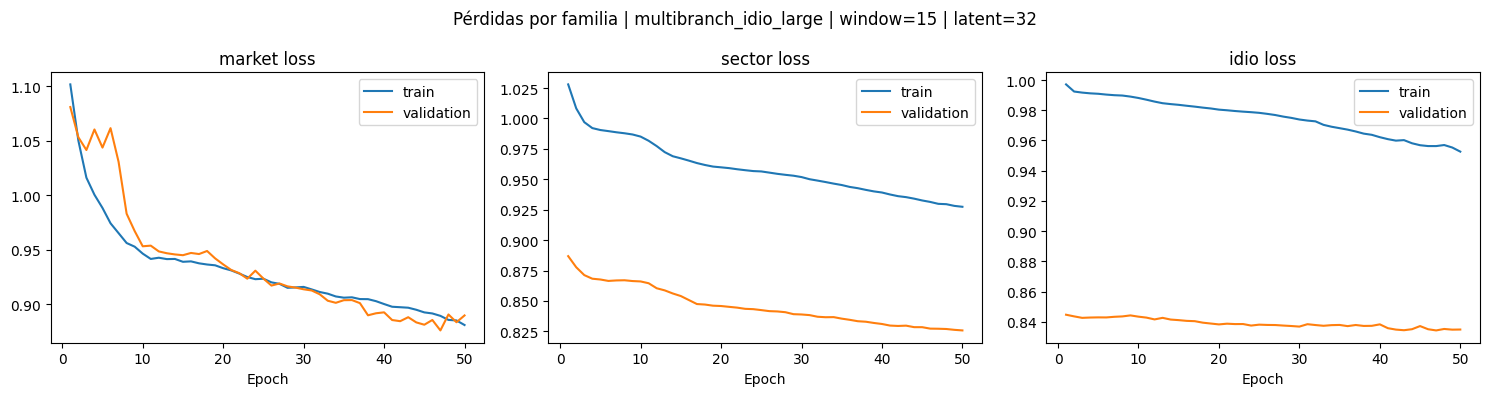

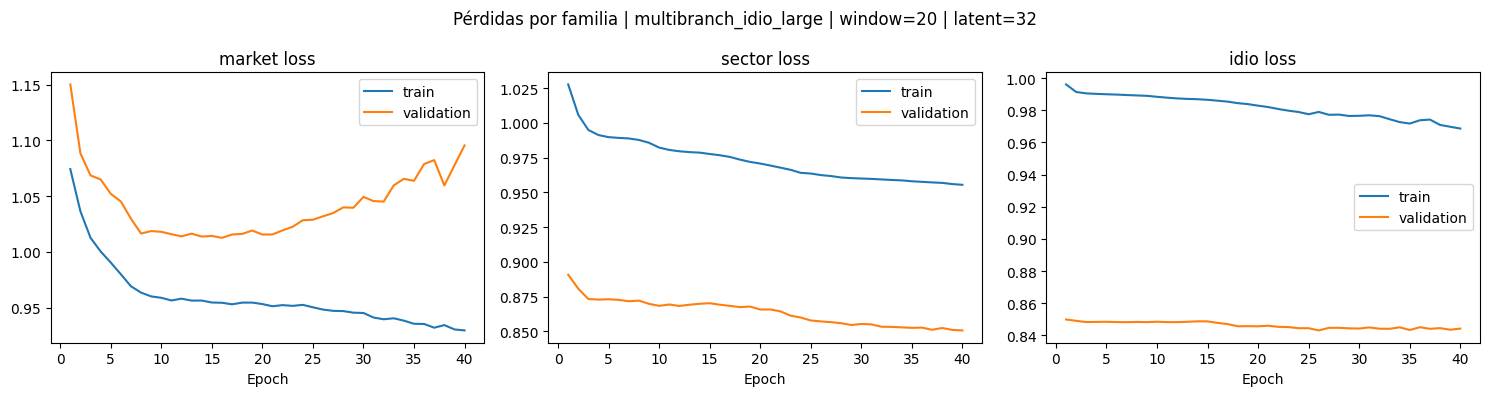

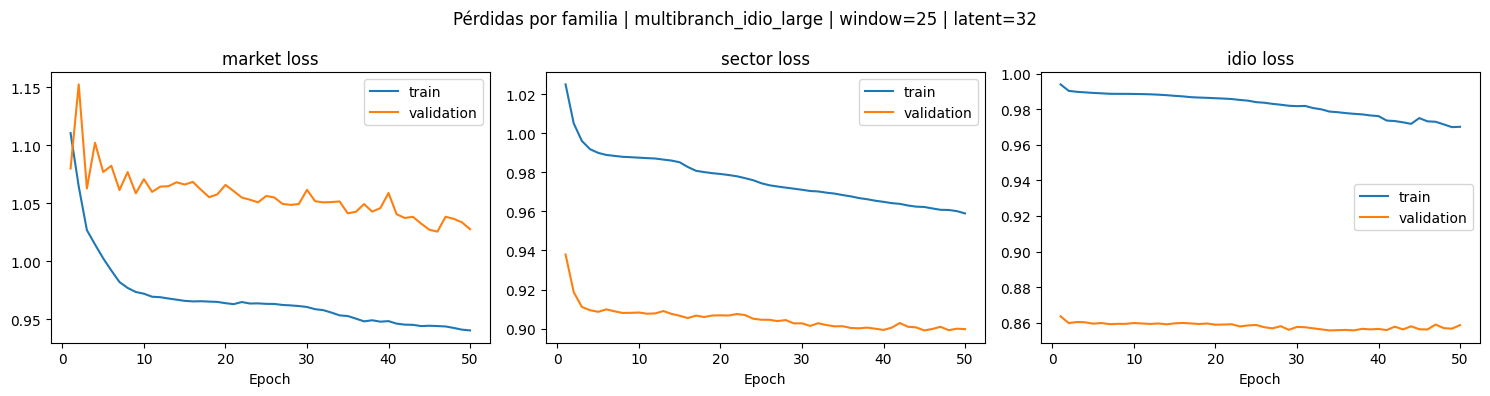

In [45]:
for candidate_id, history_df in candidate_histories.items():
    candidate = CANDIDATES[candidate_id]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
    for axis, branch in zip(axes, ('market', 'sector', 'idio')):
        axis.plot(history_df['epoch'], history_df[f'train_{branch}_loss'], label='train')
        axis.plot(history_df['epoch'], history_df[f'val_{branch}_loss'], label='validation')
        axis.set_title(f'{branch} loss')
        axis.set_xlabel('Epoch')
        axis.legend()
    fig.suptitle(f"Pérdidas por familia | {candidate['architecture']} | window={candidate['window_size']} | latent={candidate['latent_dim']}")
    fig.tight_layout()
    fig.savefig(Path('../reports/figures/vae/training_curves') / f'candidate_{candidate_id:03d}_branches.png', dpi=140)
    plt.show()
    plt.close(fig)

,candidate_id,architecture,window_size,latent_dim,best_validation_score
0,44,single_gru_large,10,32,0.751837
1,40,single_gru_large,10,24,0.757860
2,28,single_gru_medium,10,32,0.774691
3,8,single_gru_small,10,24,0.776738
4,36,single_gru_large,10,16,0.778205


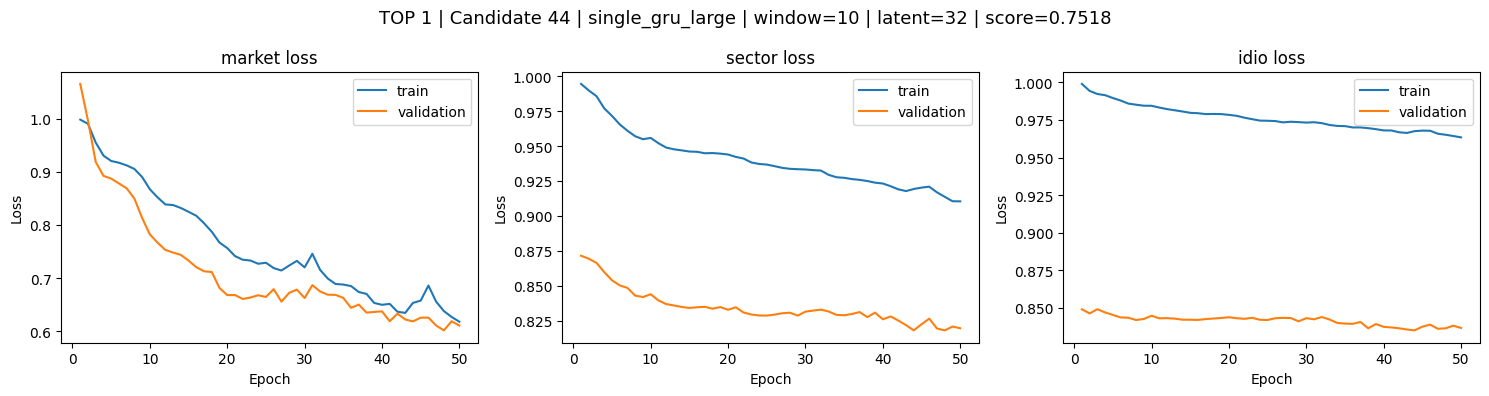

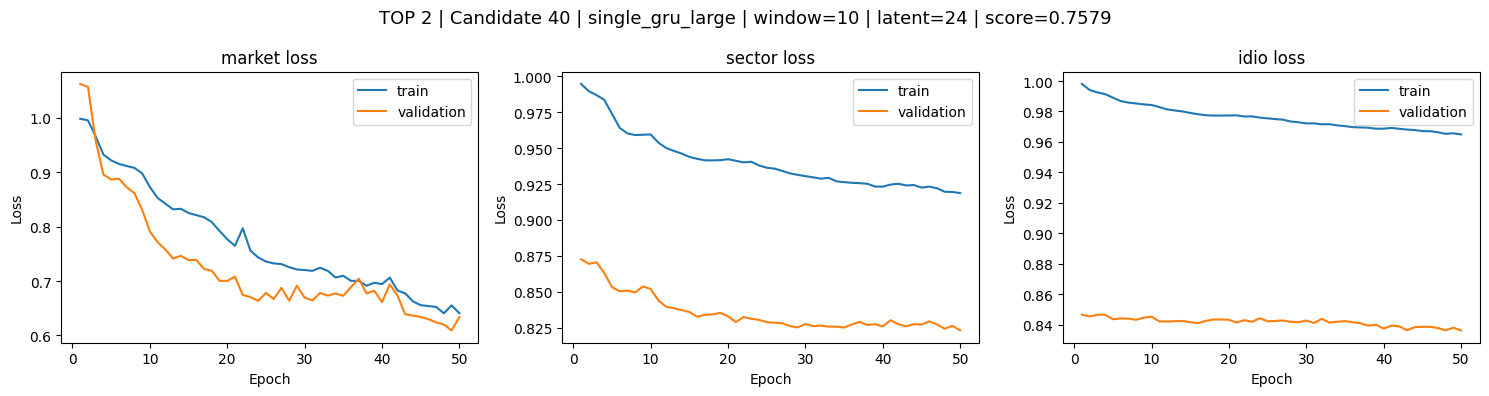

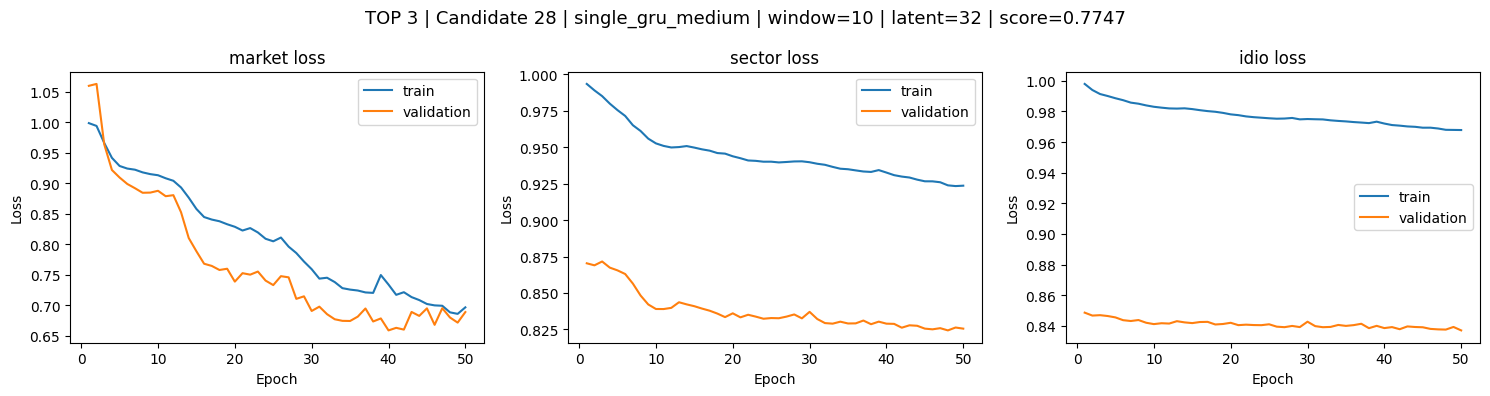

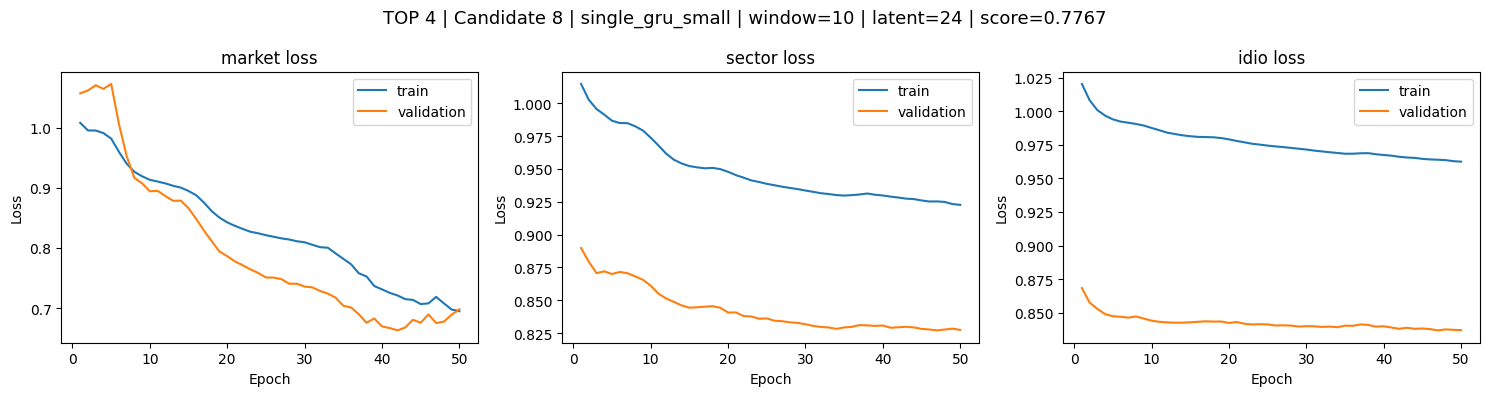

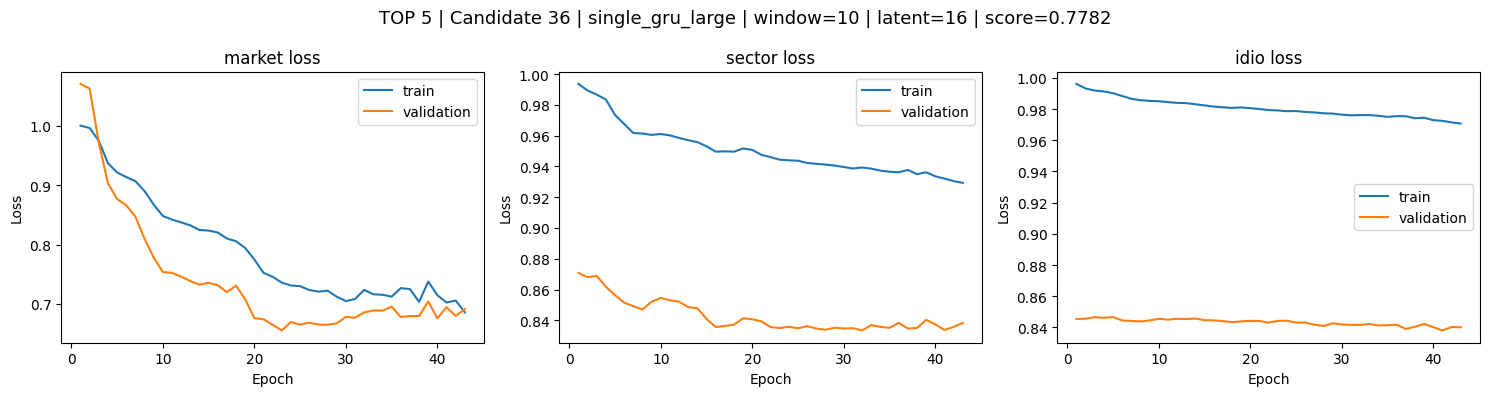

In [48]:
# Top 5 según la métrica común de validación
top5 = results_df.nsmallest(5, "best_validation_score")
top_5_ids = top5["candidate_id"].tolist()

# Mostrar información disponible
display(
    top5[
        [
            "candidate_id",
            "architecture",
            "window_size",
            "latent_dim",
            "best_validation_score",
        ]
    ]
)

# Graficar curvas del Top 5
for rank, candidate_id in enumerate(top_5_ids, start=1):

    history_df = candidate_histories[candidate_id]
    candidate = CANDIDATES[candidate_id]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

    for axis, branch in zip(axes, ("market", "sector", "idio")):

        axis.plot(
            history_df["epoch"],
            history_df[f"train_{branch}_loss"],
            label="train"
        )

        axis.plot(
            history_df["epoch"],
            history_df[f"val_{branch}_loss"],
            label="validation"
        )

        axis.set_title(f"{branch} loss")
        axis.set_xlabel("Epoch")
        axis.set_ylabel("Loss")
        axis.legend()

    score = top5.loc[
        top5["candidate_id"] == candidate_id,
        "best_validation_score"
    ].iloc[0]

    fig.suptitle(
        f"TOP {rank} | Candidate {candidate_id} | "
        f"{candidate['architecture']} | "
        f"window={candidate['window_size']} | "
        f"latent={candidate['latent_dim']} | "
        f"score={score:.4f}",
        fontsize=13
    )

    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [49]:
# Crear familia si no existe
if "model_family" not in results_df.columns:
    results_df["model_family"] = results_df["architecture"].apply(
        lambda x: "multi" if "multi" in str(x).lower() else "single"
    )

# 1. SINGLE vs MULTI
display(
    results_df.groupby("model_family")["best_validation_score"]
    .agg(["mean", "median", "min", "std", "count"])
    .sort_values("mean")
)

# 2. ARQUITECTURAS
display(
    results_df.groupby("architecture")["best_validation_score"]
    .agg(["mean", "median", "min", "std", "count"])
    .sort_values("mean")
)

# 3. WINDOW SIZE
display(
    results_df.groupby("window_size")["best_validation_score"]
    .agg(["mean", "median", "min", "std", "count"])
    .sort_values("mean")
)

# 4. LATENT DIMENSION
display(
    results_df.groupby("latent_dim")["best_validation_score"]
    .agg(["mean", "median", "min", "std", "count"])
    .sort_values("mean")
)

# 5. SINGLE vs MULTI según WINDOW SIZE
display(
    results_df.pivot_table(
        index="window_size",
        columns="model_family",
        values="best_validation_score",
        aggfunc="mean"
    )
)

# 6. TOP 10
display(
    results_df
    .nsmallest(10, "best_validation_score")
    [[
        "candidate_id",
        "model_family",
        "architecture",
        "window_size",
        "latent_dim",
        "best_validation_score"
    ]]
)

,mean,median,min,std,count
model_family,,,,,
single,0.837054,0.843105,0.751837,0.049724,48
multi,0.869641,0.870576,0.795705,0.044582,64


,mean,median,min,std,count
architecture,,,,,
single_gru_large,0.828418,0.824676,0.751837,0.052423,16
single_gru_medium,0.834665,0.829541,0.774691,0.046403,16
single_gru_small,0.848079,0.849030,0.776738,0.051288,16
multibranch_deep,0.856013,0.853363,0.795705,0.045941,16
multibranch_idio_large,0.869556,0.872117,0.801402,0.046112,16
multibranch_medium,0.869624,0.872955,0.797235,0.048773,16
multibranch_small,0.883373,0.881405,0.833067,0.036506,16


,mean,median,min,std,count
window_size,,,,,
10,0.797514,0.797616,0.751837,0.022585,28
15,0.833110,0.834696,0.791676,0.026884,28
20,0.876268,0.876658,0.848424,0.019508,28
25,0.915809,0.920293,0.892573,0.013461,28


,mean,median,min,std,count
latent_dim,,,,,
32,0.852879,0.854069,0.751837,0.051465,28
24,0.853095,0.850692,0.757860,0.051573,28
16,0.856453,0.860547,0.778205,0.049354,28
8,0.860275,0.863406,0.778339,0.047312,28


model_family,multi,single
window_size,,
10,0.812541,0.777479
15,0.851613,0.808441
20,0.888813,0.859541
25,0.925599,0.902755


,candidate_id,model_family,architecture,window_size,latent_dim,best_validation_score
0,44,single,single_gru_large,10,32,0.751837
1,40,single,single_gru_large,10,24,0.757860
2,28,single,single_gru_medium,10,32,0.774691
3,8,single,single_gru_small,10,24,0.776738
4,36,single,single_gru_large,10,16,0.778205
5,0,single,single_gru_small,10,8,0.778339
6,20,single,single_gru_medium,10,16,0.781063
7,4,single,single_gru_small,10,16,0.781403
8,32,single,single_gru_large,10,8,0.784800
9,24,single,single_gru_medium,10,24,0.785626


### Siguiente búsqueda localizada

La búsqueda anterior encontró el mejor resultado en el límite inferior de `window_size` y el superior de `latent_dim`. Por ello se añade una fase final, separada de los resultados anteriores, exclusivamente con arquitecturas Single-Branch GRU:

- `WINDOW_SIZES = [5, 7, 10, 12, 15]`
- `LATENT_DIMS = [16, 24, 32, 48, 64]`
- arquitecturas `[128]`, `[128, 128]`, `[256, 128]` y `[256, 256]`
- cuatro ponderaciones de reconstrucción: `(1/3, 1/3, 1/3)`, `(0.20, 0.40, 0.40)`, `(0.20, 0.50, 0.30)` y `(0.15, 0.50, 0.35)`
- `learning_rate = 0.0005`, 200 épocas máximas y paciencia 30

Cada candidato optimiza su pérdida ponderada, pero la selección de arquitectura, ventana y pesos se realiza con `val_common_total_loss`, la pérdida total sin ponderar sobre las 61 variables. Así se comparan los pesos con una métrica común. Se guardan ambas pérdidas, junto con las losses de mercado, sector e idiosincrática.

Las arquitecturas Multi-Branch no participan en esta búsqueda localizada porque ya fueron comparadas en la fase anterior.

## 7. Selección del ganador y checkpoint de validation

La selección usa solo los bloques de validation. `best_validation_score` es la loss de reconstrucción equilibrada `1/3, 1/3, 1/3`, idéntica para ambas familias y comparable entre ventanas. La tabla conserva además `validation_market_loss`, `validation_sector_loss`, `validation_idio_loss`, la loss común de 61 variables, KL, pérdida total, época, parámetros y tiempo.

In [ ]:
best_row = results_df.iloc[0].to_dict()
best_candidate_id = int(best_row['candidate_id'])
best_candidate = CANDIDATES[best_candidate_id]
best_checkpoint = Path('../models/vae/best_vae_validation.pt')
shutil.copyfile(best_row['checkpoint'], best_checkpoint)
joblib.dump(candidate_scalers[best_candidate_id], '../models/vae/best_vae_validation_scaler.joblib')
best_config = {
    **best_candidate,
    **ARCHITECTURES[best_candidate['architecture']],
    'input_dim': components.shape[1], 'learning_rate': LEARNING_RATE,
    'beta_kl': BETA_KL, 'branch_loss_weights': BRANCH_LOSS_WEIGHTS,
    'seed': SEED, 'best_epoch': int(best_row['best_epoch']),
    'validation_score': float(best_row['best_validation_score']),
    'feature_names': feature_names, 'validation_blocks': validation_blocks,
}
save_json('../models/vae/best_vae_validation_config.json', best_config)
print('best_model_family:', best_config['family'])
print('best_architecture:', best_candidate['architecture'])
print('best_window_size:', best_candidate['window_size'])
print('best_latent_dim:', best_candidate['latent_dim'])
print('best_learning_rate:', best_config['learning_rate'])
print('best_epoch:', best_config['best_epoch'])
print('best_validation_score:', best_config['validation_score'])

In [ ]:
single_results = results_df[results_df['family'] == 'single_branch']
multi_results = results_df[results_df['family'] == 'multi_branch']
comparison_columns = [
    'family', 'architecture', 'window_size', 'latent_dim',
    'best_validation_score', 'validation_branch_weighted_loss',
    'validation_common_reconstruction_loss', 'validation_market_loss',
    'validation_sector_loss', 'validation_idio_loss', 'validation_kl_loss',
    'validation_total_loss',
]
family_comparison = pd.DataFrame({
    'best_single_branch': single_results.iloc[0][comparison_columns],
    'best_multi_branch': multi_results.iloc[0][comparison_columns],
})
family_comparison

## 8. Reentrenamiento final con TODO el histórico

El checkpoint de validation solo sirve para seleccionar arquitectura e hiperparámetros. El modelo definitivo se inicializa desde cero, se ajusta un scaler nuevo con todo el histórico y se entrena con todas las ventanas. Se usan `FINAL_EPOCHS = best_epoch`, la época óptima observada durante la selección.

In [ ]:
FINAL_EPOCHS = max(1, int(best_config['best_epoch']))
final_scaler = StandardScaler().fit(components.to_numpy())
normalized_full = pd.DataFrame(
    final_scaler.transform(components.to_numpy()), index=components.index, columns=feature_names
)
final_windows, final_starts = make_windows(normalized_full, best_candidate['window_size'])
set_reproducible_seed(SEED + 10000)
final_model = build_model(best_candidate)
final_history = train_vae_full_data(
    final_model, final_windows, epochs=FINAL_EPOCHS, batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE, beta_kl=BETA_KL, seed=SEED + 10000,
    device=DEVICE, checkpoint_path='../models/vae/best_vae_full_data.pt',
    branch_loss_weights=BRANCH_LOSS_WEIGHTS,
)
final_history_df = pd.DataFrame(final_history)
final_history_df.to_csv('../models/vae/best_vae_full_data_training_history.csv', index=False)
joblib.dump(final_scaler, '../models/vae/best_vae_full_data_scaler.joblib')
final_config = {
    **best_config, 'seed': SEED + 10000, 'final_epochs': FINAL_EPOCHS,
    'checkpoint_role': 'definitive model trained from scratch on all historical windows',
}
save_json('../models/vae/best_vae_full_data_config.json', final_config)

fig, ax = plt.subplots(figsize=(9, 4))
for metric in ('reconstruction_loss', 'common_reconstruction_loss', 'kl_loss', 'total_loss'):
    ax.plot(final_history_df['epoch'], final_history_df[f'train_{metric}'], label=metric)
for branch in ('market', 'sector', 'idio'):
    ax.plot(final_history_df['epoch'], final_history_df[f'train_{branch}_loss'], '--', label=f'{branch} loss')
ax.set_title('Reentrenamiento final con todo el histórico')
ax.set_xlabel('Epoch')
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig('../reports/figures/vae/final_training_curve.png', dpi=140)
plt.show()

## 9. Reconstrucción de una trayectoria y perturbación latente

Para una ventana real $X$, el VAE obtiene $\mu_X$ y $\sigma_X$. Con la misma dirección $\varepsilon$ para todos los valores de `alpha`, se estudia una transformación progresiva: $z_\alpha=\mu_X+\alpha\sigma_X\varepsilon$. `alpha=0` es la reconstrucción central; valores mayores exploran alternativas cada vez más alejadas.

In [ ]:
source_start = final_starts[len(final_starts) // 2]
source_window = normalized_full.iloc[source_start:source_start + best_candidate['window_size']].to_numpy(dtype=np.float32)
latent_variants = decode_latent_variants(
    final_model, source_window, ALPHAS, seed=SEED + 20000, device=DEVICE
)
source_original = components.iloc[source_start:source_start + best_candidate['window_size']]
decoded_original_scale = {
    alpha: pd.DataFrame(final_scaler.inverse_transform(values), index=source_original.index, columns=feature_names)
    for alpha, values in latent_variants.items()
}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for axis, feature, title in zip(axes, ['market_factor', feature_names[1], feature_names[31]], ['Factor de mercado', 'Factor sectorial representativo', 'Residuo idiosincratico representativo']):
    axis.plot(source_original.index, source_original[feature], color='black', linewidth=2, label='real')
    for alpha in ALPHAS:
        axis.plot(decoded_original_scale[alpha].index, decoded_original_scale[alpha][feature], label=f'alpha={alpha}')
    axis.set_title(title)
    axis.legend(ncol=4)
fig.suptitle('Una trayectoria real y alternativas latentes en la misma dirección')
plt.tight_layout()
plt.show()

## 10. Separación de las 61 variables y reconstrucción de retornos

Cada salida del decoder se separa respetando el orden exacto: primera columna mercado, siguientes 30 sectoriales y últimas 30 idiosincráticas. Las betas no se generan ni reestiman: se cargan del Notebook 2 y `reconstruct_returns` vuelve a producir los retornos de los mismos 30 activos.

In [ ]:
def split_components(decoded_frame):
    return (
        decoded_frame['market_factor'],
        decoded_frame.iloc[:, 1:31],
        decoded_frame.iloc[:, 31:61],
    )

def decode_full_scenario(alpha, variant_id=0):
    stride = best_candidate['window_size'] if GENERATION_STRIDE is None else GENERATION_STRIDE
    starts = window_start_indices(len(components), best_candidate['window_size'], stride)
    if len(starts) == 0 or starts[-1] != len(components) - best_candidate['window_size']:
        starts = np.append(starts, len(components) - best_candidate['window_size'])
    values = np.zeros((len(components), components.shape[1]), dtype=float)
    counts = np.zeros(len(components), dtype=float)
    for window_number, start in enumerate(starts):
        normalized_window = normalized_full.iloc[start:start + best_candidate['window_size']].to_numpy(dtype=np.float32)
        decoded = decode_latent_variants(
            final_model, normalized_window, [alpha],
            seed=SEED + 30000 + variant_id * 1000 + window_number, device=DEVICE
        )[float(alpha)]
        decoded = final_scaler.inverse_transform(decoded)
        values[start:start + best_candidate['window_size']] += decoded
        counts[start:start + best_candidate['window_size']] += 1
    decoded_frame = pd.DataFrame(values / counts[:, None], index=components.index, columns=feature_names)
    market, sector, idio = split_components(decoded_frame)
    returns = reconstruct_returns(market, sector, idio, betas)
    return decoded_frame, returns

decoded_alpha_0, returns_alpha_0 = decode_full_scenario(0.0)
print('Retornos reconstruidos:', returns_alpha_0.shape)

## 11. Fidelidad y diversidad frente a alpha

Se evalúan por separado. La fidelidad compara medias, volatilidades, cuantiles, skewness, kurtosis y correlaciones. La diversidad mide la distancia respecto a la trayectoria origen y la distancia entre variantes de una misma ventana. No se elige `alpha` solo por minimizar el error: un alpha demasiado pequeño puede producir copias casi idénticas.

In [ ]:
def upper_triangle_mean(matrix):
    values = matrix.to_numpy()[np.triu_indices_from(matrix, k=1)]
    return float(np.mean(np.abs(values)))

alpha_results = []
scenario_cache = {}
for alpha in ALPHAS:
    decoded_frame, returns_synthetic = decode_full_scenario(alpha, variant_id=0)
    scenario_cache[alpha] = returns_synthetic
    comparison = pd.DataFrame({
        'mean_real': returns_real.mean(), 'mean_synth': returns_synthetic.mean(),
        'std_real': returns_real.std(), 'std_synth': returns_synthetic.std(),
        'skew_real': returns_real.skew(), 'skew_synth': returns_synthetic.skew(),
        'kurtosis_real': returns_real.kurtosis(), 'kurtosis_synth': returns_synthetic.kurtosis(),
    })
    corr_real = returns_real.corr()
    corr_synth = returns_synthetic.corr()
    corr_difference = (corr_real - corr_synth).abs()
    origin_distance = float(np.mean((decoded_frame.to_numpy() - components.to_numpy()) ** 2) ** 0.5)
    variant_distances = []
    for variant_id in range(1, N_VARIANTS):
        _, variant_returns = decode_full_scenario(alpha, variant_id=variant_id)
        variant_distances.append(float(np.mean((variant_returns.to_numpy() - returns_synthetic.to_numpy()) ** 2) ** 0.5))
    alpha_results.append({
        'alpha': alpha, 'mean_absolute_corr_diff': upper_triangle_mean(corr_difference),
        'max_absolute_corr_diff': float(corr_difference.to_numpy()[np.triu_indices_from(corr_difference, k=1)].max()),
        'mean_std_ratio': float((comparison['std_synth'] / comparison['std_real']).mean()),
        'mean_origin_distance_components': origin_distance,
        'mean_between_variant_distance_returns': float(np.mean(variant_distances)) if variant_distances else np.nan,
    })

alpha_results_df = pd.DataFrame(alpha_results)
alpha_results_df.to_csv('../models/vae/alpha_results.csv', index=False)
alpha_results_df

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(alpha_results_df['alpha'], alpha_results_df['mean_absolute_corr_diff'], marker='o', label='Error de correlación')
axes[0].set_title('Fidelidad: error medio de correlaciones')
axes[0].set_xlabel('alpha')
axes[0].legend()
axes[1].plot(alpha_results_df['alpha'], alpha_results_df['mean_origin_distance_components'], marker='o', label='Distancia al origen')
axes[1].plot(alpha_results_df['alpha'], alpha_results_df['mean_between_variant_distance_returns'], marker='s', label='Distancia entre variantes')
axes[1].set_title('Diversidad frente a alpha')
axes[1].set_xlabel('alpha')
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. Guardado de escenarios sintéticos

Se usan ventanas contiguas con `GENERATION_STRIDE` configurable para evitar miles de episodios casi repetidos por solapamiento. Se guarda un archivo por `alpha` y variante, una tabla de metadatos y una copia canónica `returns_synthetic_vae.parquet` correspondiente a `alpha=1.0`, variante 0.

`best_vae_validation.pt` selecciona la arquitectura; `best_vae_full_data.pt` es el modelo definitivo, reentrenado desde cero con todo el histórico.

In [ ]:
generation_metadata = []
for alpha in ALPHAS:
    for variant_id in range(N_VARIANTS):
        _, generated_returns = decode_full_scenario(alpha, variant_id=variant_id)
        filename = f'../data/processed/returns_synthetic_vae_alpha_{alpha:.2f}_variant_{variant_id:02d}.parquet'
        generated_returns.to_parquet(filename)
        generation_metadata.append({
            'source_window_start': components.index[0],
            'source_window_end': components.index[-1],
            'window_size': best_candidate['window_size'],
            'alpha': alpha, 'variant_id': variant_id,
            'seed': SEED + 30000 + variant_id * 1000,
            'architecture': best_candidate['architecture'],
            'latent_dim': best_candidate['latent_dim'],
            'model_checkpoint': 'models/vae/best_vae_full_data.pt',
            'path': filename,
        })

canonical_path = '../data/processed/returns_synthetic_vae.parquet'
scenario_cache[1.0].to_parquet(canonical_path)
metadata_df = pd.DataFrame(generation_metadata)
metadata_df.to_csv('../data/processed/vae_generation_metadata.csv', index=False)
print(f'Guardado modelo definitivo: ../models/vae/best_vae_full_data.pt')
print(f'Guardado dataset canonico: {canonical_path}')
print(f'Escenarios generados: {len(metadata_df)}')

## 13. Conclusiones

- El VAE aprende conjuntamente las 61 variables en ventanas temporales, no días independientes.
- Los bloques aleatorios purgados permiten comparar candidatos sin leakage.
- La validación selecciona arquitectura, ventana y dimensión latente; después el ganador se reentrena desde cero con todo el histórico.
- `alpha` separa intensidad de modificación y `epsilon` la dirección concreta; por eso se reportan fidelidad y diversidad por separado.
- Los retornos finales mantienen los 30 activos y reutilizan las betas reales del Notebook 2.